Loading and plotting sample file...
File: CUTS_MAINWING_FILTERED_y3.321_SWEEP=0.00.hug
Number of elements: 2
Points per element (header): 400
Line 2: [0.924289444, 0.0129181274]
Line 3: [0.919426976, 0.0131643178]
Line 4: [0.914562078, 0.0133565219]
Line 5: [0.909695226, 0.0134901809]
Line 6: [0.904827035, 0.0135593511]
Line 7: [0.899958367, 0.0135563153]
Line 8: [0.895090459, 0.0134710243]
Line 9: [0.890225189, 0.0132902182]
Total coordinate lines: 601
X range: -0.0063 to 1.0340
Y range: -0.0908 to 0.0524
Potential element boundary at index 400: x jump from 0.9243 to 1.0321
Element boundaries: [0, 400, 600]
Element 1: points 0 to 399 (400 points)
Element 2: points 400 to 599 (200 points)


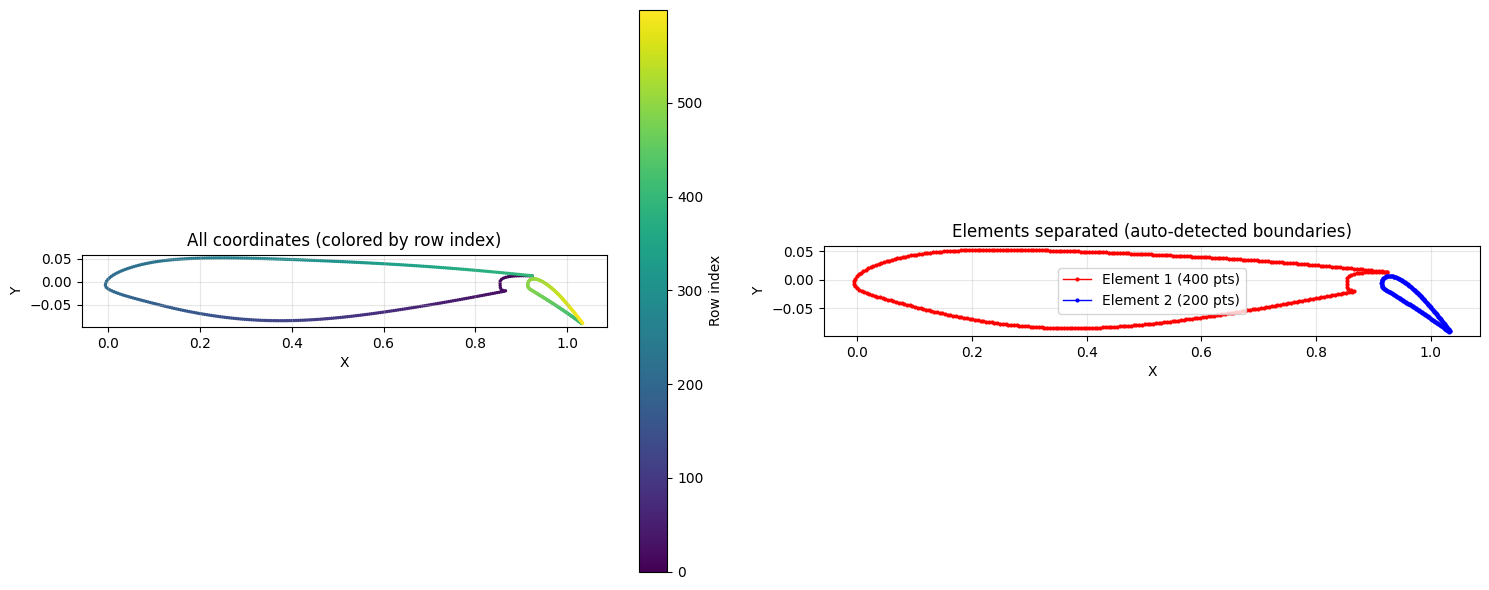



Loading multiple files for comparison...

File 1/3
File: CUTS_MAINWING_FILTERED_y12.894_SWEEP=0.00.hug
Number of elements: 3
Points per element (header): 200
Line 2: [0.0260945415, 0.00410698357]
Line 3: [0.024920531, 0.00330431422]
Line 4: [0.023753485, 0.00249155036]
Line 5: [0.022592984, 0.00166946764]
Line 6: [0.0214389557, 0.000838323151]
Line 7: [0.0202915425, -1.92978085e-06]
Line 8: [0.0191509578, -0.000851426645]
Line 9: [0.0180173907, -0.00171026597]
Total coordinate lines: 802
X range: -0.0602 to 1.0497
Y range: -0.1297 to 0.0549
Potential element boundary at index 200: x jump from 0.0257 to 0.8667
Potential element boundary at index 600: x jump from 0.8668 to 1.0491
Element boundaries: [0, 200, 600, 800]
Element 1: points 0 to 199 (200 points)
Element 2: points 200 to 599 (400 points)
Element 3: points 600 to 799 (200 points)


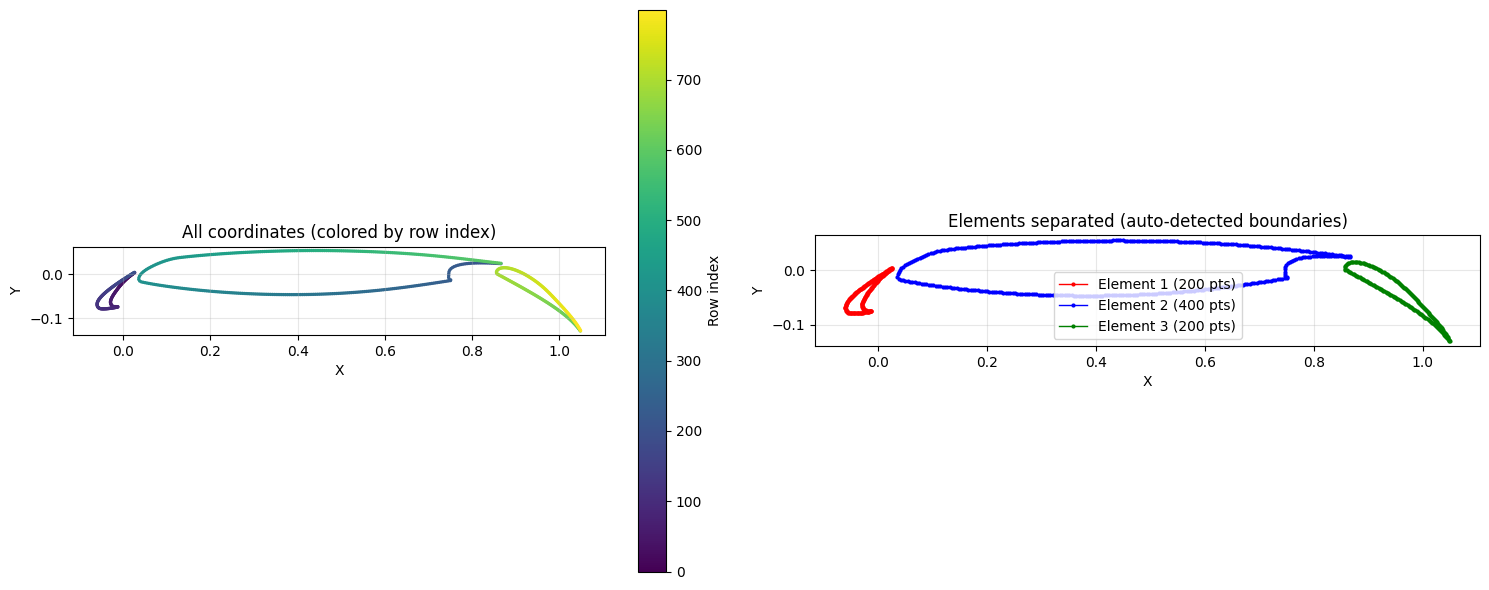

Total points loaded: 800

File 2/3
File: CUTS_MAINWING_FILTERED_y13.957_SWEEP=0.00.hug
Number of elements: 3
Points per element (header): 200
Total coordinate lines: 802
X range: -0.0629 to 1.0513
Y range: -0.1294 to 0.0556
Element boundaries: [0, 200, 600, 800]
Element 1: points 0 to 199 (200 points)
Element 2: points 200 to 599 (400 points)
Element 3: points 600 to 799 (200 points)


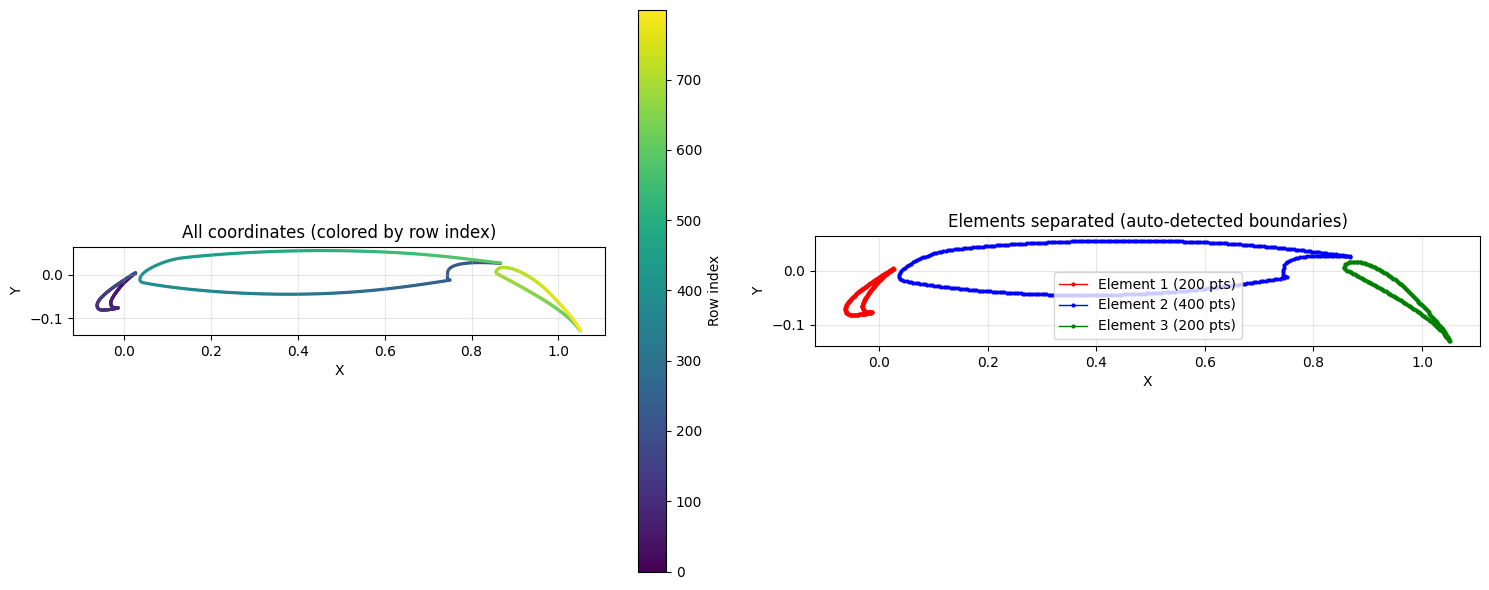

Total points loaded: 800

File 3/3
File: CUTS_MAINWING_FILTERED_y24.860_SWEEP=0.00.hug
Number of elements: 2
Points per element (header): 200
Total coordinate lines: 601
X range: -0.1200 to 0.9883
Y range: -0.1133 to 0.0565
Element boundaries: [0, 200, 600]
Element 1: points 0 to 199 (200 points)
Element 2: points 200 to 599 (400 points)


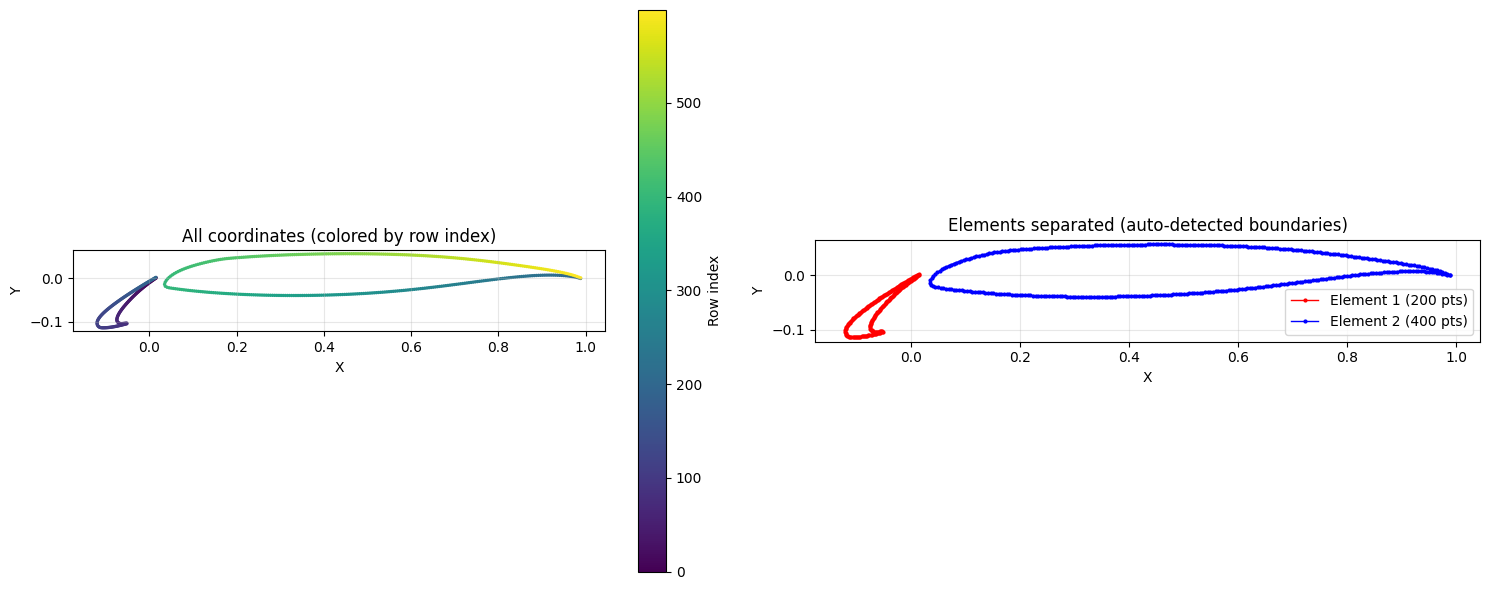

Total points loaded: 600


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

def load_and_plot_hug_file(filepath, debug=True):
    """
    Load a .hug file and plot the raw coordinates to understand the structure
    """
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        # Parse header
        num_elements = int(lines[0].strip())
        num_points_header = int(lines[1].strip())  # This might not be the actual points per element
        
        print(f"File: {os.path.basename(filepath)}")
        print(f"Number of elements: {num_elements}")
        print(f"Points per element (header): {num_points_header}")
        
        # Read all coordinate data
        all_coords = []
        for i, line in enumerate(lines[2:], start=2):
            line = line.strip()
            if line and not line.startswith('#'):
                coords = [float(x) for x in line.split()]
                all_coords.append(coords)
                if debug and i < 10:  # Print first few lines for debugging
                    print(f"Line {i}: {coords}")
        
        total_points = len(all_coords)
        print(f"Total coordinate lines: {total_points}")
        
        # Try to detect element boundaries by analyzing x-coordinate patterns
        # Elements often have distinct x-coordinate ranges
        x_coords = [coords[0] for coords in all_coords if len(coords) >= 2]
        y_coords = [coords[1] for coords in all_coords if len(coords) >= 2]
        
        print(f"X range: {min(x_coords):.4f} to {max(x_coords):.4f}")
        print(f"Y range: {min(y_coords):.4f} to {max(y_coords):.4f}")
        
        # Detect element boundaries by looking for major changes in x-coordinate
        element_boundaries = [0]  # Start of first element
        
        if num_elements > 1:
            # Look for points where x-coordinate jumps significantly (new element starts)
            for i in range(1, len(x_coords)):
                x_diff = abs(x_coords[i] - x_coords[i-1])
                if x_diff > 0.1:  # Threshold for detecting element boundary
                    element_boundaries.append(i)
                    if debug:
                        print(f"Potential element boundary at index {i}: x jump from {x_coords[i-1]:.4f} to {x_coords[i]:.4f}")
        
        element_boundaries.append(len(x_coords))  # End of last element
        
        # If we don't have enough boundaries, fall back to equal division
        if len(element_boundaries) - 1 != num_elements:
            print(f"Auto-detection found {len(element_boundaries)-1} boundaries, but expected {num_elements}")
            print("Falling back to equal division...")
            
            if num_elements == 3 and total_points > 600:
                # Special case for 3 elements with pattern like 200+400+200
                points_per_elem = total_points // num_elements
                remainder = total_points % num_elements
                
                # Try pattern: first_elem, main_elem (larger), last_elem
                if remainder == 0:
                    # Equal division
                    element_boundaries = [0, points_per_elem, 2*points_per_elem, total_points]
                else:
                    # Give extra points to middle element
                    elem1_size = points_per_elem
                    elem2_size = points_per_elem + remainder
                    elem3_size = points_per_elem
                    element_boundaries = [0, elem1_size, elem1_size + elem2_size, total_points]
            else:
                # Simple equal division
                points_per_elem = total_points // num_elements
                element_boundaries = [i * points_per_elem for i in range(num_elements + 1)]
                element_boundaries[-1] = total_points  # Ensure we include all points
        
        print(f"Element boundaries: {element_boundaries}")
        for i in range(len(element_boundaries)-1):
            start_idx = element_boundaries[i]
            end_idx = element_boundaries[i+1]
            print(f"Element {i+1}: points {start_idx} to {end_idx-1} ({end_idx - start_idx} points)")
        
        # Create plots
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot 1: All points colored by row index
        ax1 = axes[0]
        if len(x_coords) > 0:
            scatter = ax1.scatter(x_coords, y_coords, 
                                c=range(len(x_coords)), cmap='viridis', s=2)
            plt.colorbar(scatter, ax=ax1, label='Row index')
        ax1.set_title('All coordinates (colored by row index)')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Elements separated based on detected boundaries
        ax2 = axes[1]
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        
        for i in range(len(element_boundaries)-1):
            start_idx = element_boundaries[i]
            end_idx = element_boundaries[i+1]
            
            if end_idx <= len(x_coords):
                x_elem = x_coords[start_idx:end_idx]
                y_elem = y_coords[start_idx:end_idx]
                
                color = colors[i % len(colors)]
                ax2.plot(x_elem, y_elem, 'o-', color=color, 
                        linewidth=1, markersize=2, label=f'Element {i+1} ({len(x_elem)} pts)')
        
        ax2.set_title('Elements separated (auto-detected boundaries)')
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_aspect('equal')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
        
        return (x_coords, y_coords), num_elements, element_boundaries
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None, 0, []
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None, 0, 0

def plot_multiple_files(directory, pattern="*.hug", max_files=5):
    """
    Plot multiple geometry files to understand the patterns
    """
    import glob
    
    files = glob.glob(os.path.join(directory, "**", pattern), recursive=True)
    files = files[:max_files]  # Limit number of files
    
    for i, filepath in enumerate(files):
        print(f"\n{'='*60}")
        print(f"File {i+1}/{len(files)}")
        coords, num_elem, num_pts = load_and_plot_hug_file(filepath, debug=(i==0))
        
        if coords is not None:
            print(f"Total points loaded: {len(coords[0])}")  # coords is now (x_coords, y_coords) tuple

# Example usage:
if __name__ == "__main__":
    # Test with a single file
    sample_file = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG/Geom2.5D/CUTS_MAINWING_FILTERED_y3.321_SWEEP=0.00.hug"
    
    # Plot single file
    print("Loading and plotting sample file...")
    coords, num_elem, num_pts = load_and_plot_hug_file(sample_file)
    
    # Or plot multiple files to see patterns
    data_dir = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG"
    print("\n\nLoading multiple files for comparison...")
    plot_multiple_files(data_dir, max_files=3)

In [2]:
import pyoche as pch

#ds = pch.MlDataset.from_folder('/scratch/dmsm/gi.catalani/NASA_CRM_HL/pyoche_dataset/airfoil_dataset.pch')
sample = pch.Sample.from_file('/scratch/dmsm/gi.catalani/NASA_CRM_HL/pyoche_dataset/airfoil_dataset.pch/sample_LDG_y3.321_alpha0.00_mach0.20.h5')

In [3]:
print(f"Sample loaded: {sample}")
sample = pch.Sample.from_file('/scratch/dmsm/gi.catalani/NASA_CRM_HL/pyoche_dataset/airfoil_dataset.pch/sample_LDG_y22.998_alpha0.00_mach0.20.h5')
sample_file = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG/Geom2.5D/CUTS_MAINWING_FILTERED_y3.321_SWEEP=0.00.hug"  
# Plot single file
print("Loading and plotting sample file...")
coords, num_elem, num_pts = load_and_plot_hug_file(sample_file)


Sample loaded: Sample:
	point_cloud_field/PressureCoefficient: (85506, 1)
	point_cloud_field/coordinates: (85506, 2)
	point_cloud_field/element_id: (85506, 1)
	point_cloud_field/normals: (85506, 3)
	point_cloud_field/sdf: (85506, 1)
	scalars/alpha: ()
	scalars/mach_number: ()
	scalars/y_pos: ()

Loading and plotting sample file...


NameError: name 'load_and_plot_hug_file' is not defined

Loading coordinates from .hug file...
File: CUTS_MAINWING_FILTERED_y3.321_SWEEP=0.00.hug
Number of elements: 2
Points per element (header): 400
Total coordinate lines: 601
X range: -0.0063 to 1.0340
Y range: -0.0908 to 0.0524
Element boundaries: [0, 400, 600]
Element 1: points 0 to 399 (400 points)
Element 2: points 400 to 599 (200 points)


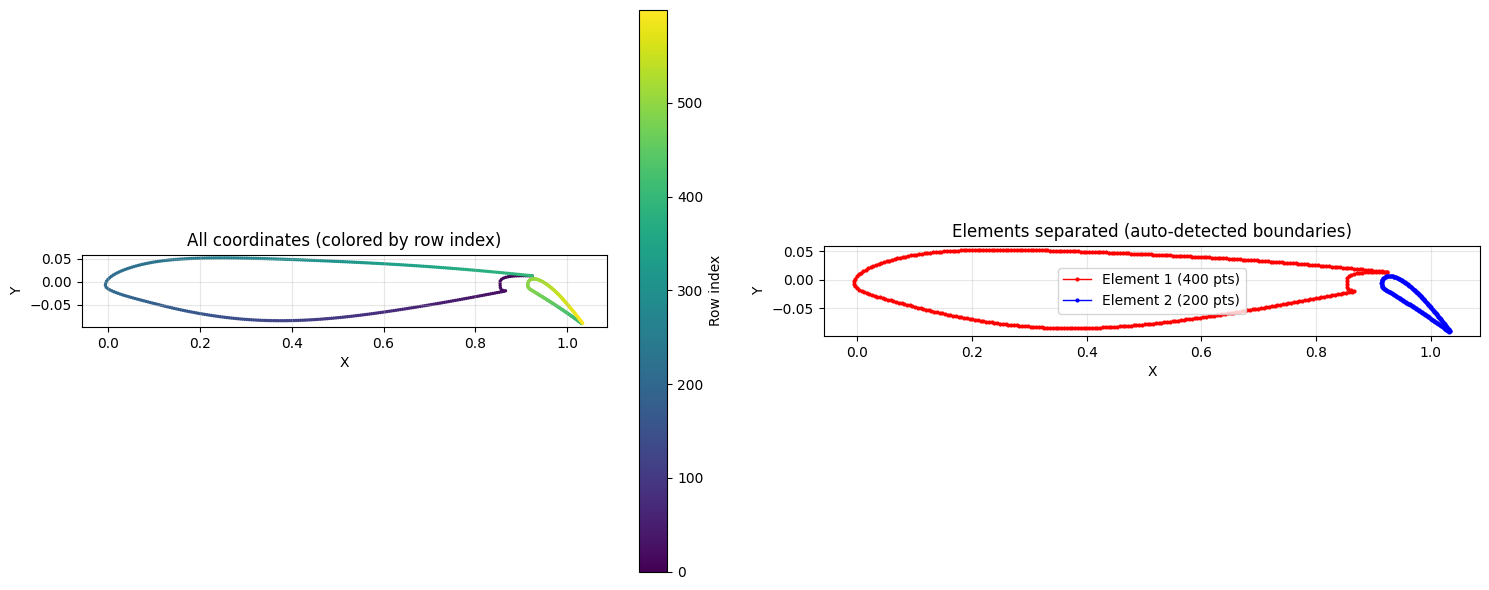

Loading surface coordinates from .h5 file...

--- Coordinate Statistics ---
.hug file (surface): 600 points
.h5 file (surface only): 1730 points
Total .h5 points: 85506
Non-zero element_id points: 1730

--- Coordinate Ranges ---
.hug X range: -0.006287 to 1.033987
.h5  X range: -0.006300 to 1.033987
.hug Y range: -0.090826 to 0.052387
.h5  Y range: -0.090826 to 0.052388


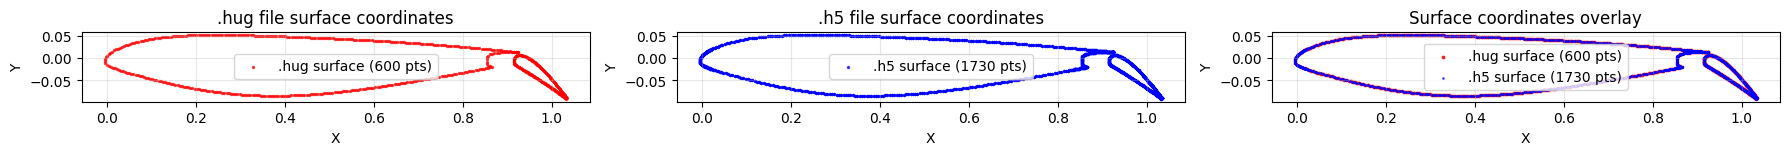


--- Numerical Comparison ---
✗ Different number of surface points: .hug=600, .h5=1730

First 10 points comparison:
  Point 0: .hug=(0.924289, 0.012918), .h5=(0.924289, 0.012918)
  Point 1: .hug=(0.919427, 0.013164), .h5=(0.924289, 0.012918)
  Point 2: .hug=(0.914562, 0.013357), .h5=(0.924238, 0.012921)
  Point 3: .hug=(0.909695, 0.013490), .h5=(0.924238, 0.012921)
  Point 4: .hug=(0.904827, 0.013559), .h5=(0.924171, 0.012925)
  Point 5: .hug=(0.899958, 0.013556), .h5=(0.924171, 0.012925)
  Point 6: .hug=(0.895090, 0.013471), .h5=(0.924049, 0.012932)
  Point 7: .hug=(0.890225, 0.013290), .h5=(0.924049, 0.012932)
  Point 8: .hug=(0.885365, 0.012996), .h5=(0.923836, 0.012943)
  Point 9: .hug=(0.880516, 0.012564), .h5=(0.923836, 0.012943)

Point count difference: 1130 points

--- Summary ---
Both files contain surface coordinate data
Different number of surface points - may be different representations


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Load coordinates from .hug file (all points are surface points)
print("Loading coordinates from .hug file...")
coords_hug, num_elem, boundaries = load_and_plot_hug_file(sample_file, debug=False)
x_hug, y_hug = coords_hug

# Load surface coordinates from .h5 file (filter for element_id != 0)
print("Loading surface coordinates from .h5 file...")
element_id_flat = sample['point_cloud_field/element_id'].flatten()
surface_mask = element_id_flat != 0
coords_h5_surface = sample['point_cloud_field/coordinates'][surface_mask]
x_h5 = coords_h5_surface[:, 0]
y_h5 = coords_h5_surface[:, 1]

# Print basic statistics
print(f"\n--- Coordinate Statistics ---")
print(f".hug file (surface): {len(x_hug)} points")
print(f".h5 file (surface only): {len(x_h5)} points")
print(f"Total .h5 points: {len(sample['point_cloud_field/coordinates'])}")
print(f"Non-zero element_id points: {np.sum(surface_mask)}")

print(f"\n--- Coordinate Ranges ---")
print(f".hug X range: {min(x_hug):.6f} to {max(x_hug):.6f}")
print(f".h5  X range: {min(x_h5):.6f} to {max(x_h5):.6f}")
print(f".hug Y range: {min(y_hug):.6f} to {max(y_hug):.6f}")
print(f".h5  Y range: {min(y_h5):.6f} to {max(y_h5):.6f}")

# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: .hug file surface coordinates
ax1 = axes[0]
ax1.scatter(x_hug, y_hug, c='red', s=2, alpha=0.7, label=f'.hug surface ({len(x_hug)} pts)')
ax1.set_title('.hug file surface coordinates')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: .h5 file surface coordinates
ax2 = axes[1]
ax2.scatter(x_h5, y_h5, c='blue', s=2, alpha=0.7, label=f'.h5 surface ({len(x_h5)} pts)')
ax2.set_title('.h5 file surface coordinates')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Overlay both for comparison
ax3 = axes[2]
ax3.scatter(x_hug, y_hug, c='red', s=3, alpha=0.8, label=f'.hug surface ({len(x_hug)} pts)')
ax3.scatter(x_h5, y_h5, c='blue', s=1, alpha=0.6, label=f'.h5 surface ({len(x_h5)} pts)')
ax3.set_title('Surface coordinates overlay')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Numerical comparison
print(f"\n--- Numerical Comparison ---")
if len(x_hug) == len(x_h5):
    print("✓ Same number of surface points")
    
    # Convert to numpy arrays for comparison
    x_hug_arr = np.array(x_hug)
    y_hug_arr = np.array(y_hug)
    
    # Calculate differences
    x_diff = np.abs(x_hug_arr - x_h5)
    y_diff = np.abs(y_hug_arr - y_h5)
    
    max_x_diff = np.max(x_diff)
    max_y_diff = np.max(y_diff)
    mean_x_diff = np.mean(x_diff)
    mean_y_diff = np.mean(y_diff)
    
    print(f"Maximum X difference: {max_x_diff:.8f}")
    print(f"Maximum Y difference: {max_y_diff:.8f}")
    print(f"Mean X difference: {mean_x_diff:.8f}")
    print(f"Mean Y difference: {mean_y_diff:.8f}")
    
    # Check if coordinates match within tolerance
    tolerance = 1e-6
    if max_x_diff < tolerance and max_y_diff < tolerance:
        print("✓ Surface coordinates match within tolerance!")
    else:
        print("✗ Surface coordinates differ significantly")
        
        # Show points with largest differences
        total_diff = x_diff + y_diff
        worst_indices = np.argsort(total_diff)[-5:]  # Top 5 worst matches
        
        print("\nPoints with largest differences:")
        for idx in reversed(worst_indices):
            print(f"  Point {idx}: .hug=({x_hug[idx]:.6f}, {y_hug[idx]:.6f}), .h5=({x_h5[idx]:.6f}, {y_h5[idx]:.6f}), diff=({x_diff[idx]:.6f}, {y_diff[idx]:.6f})")
            
else:
    print(f"✗ Different number of surface points: .hug={len(x_hug)}, .h5={len(x_h5)}")
    
    # Show sample of first few points for comparison
    min_len = min(len(x_hug), len(x_h5))
    print(f"\nFirst {min(10, min_len)} points comparison:")
    for i in range(min(10, min_len)):
        print(f"  Point {i}: .hug=({x_hug[i]:.6f}, {y_hug[i]:.6f}), .h5=({x_h5[i]:.6f}, {y_h5[i]:.6f})")
    
    if len(x_hug) != len(x_h5):
        print(f"\nPoint count difference: {abs(len(x_hug) - len(x_h5))} points")

print(f"\n--- Summary ---")
if len(x_hug) > 0 and len(x_h5) > 0:
    print("Both files contain surface coordinate data")
    if len(x_hug) == len(x_h5):
        print("Same number of surface points - likely same geometry")
    else:
        print("Different number of surface points - may be different representations")
else:
    if len(x_h5) == 0:
        print("⚠️  No surface points found in .h5 file (all element_id = 0)")
    if len(x_hug) == 0:
        print("⚠️  No surface points found in .hug file")

Total points: 108557
Surface points: 2304
SDF range: -0.0003 to 3.5136
Surface element IDs: [1 2]


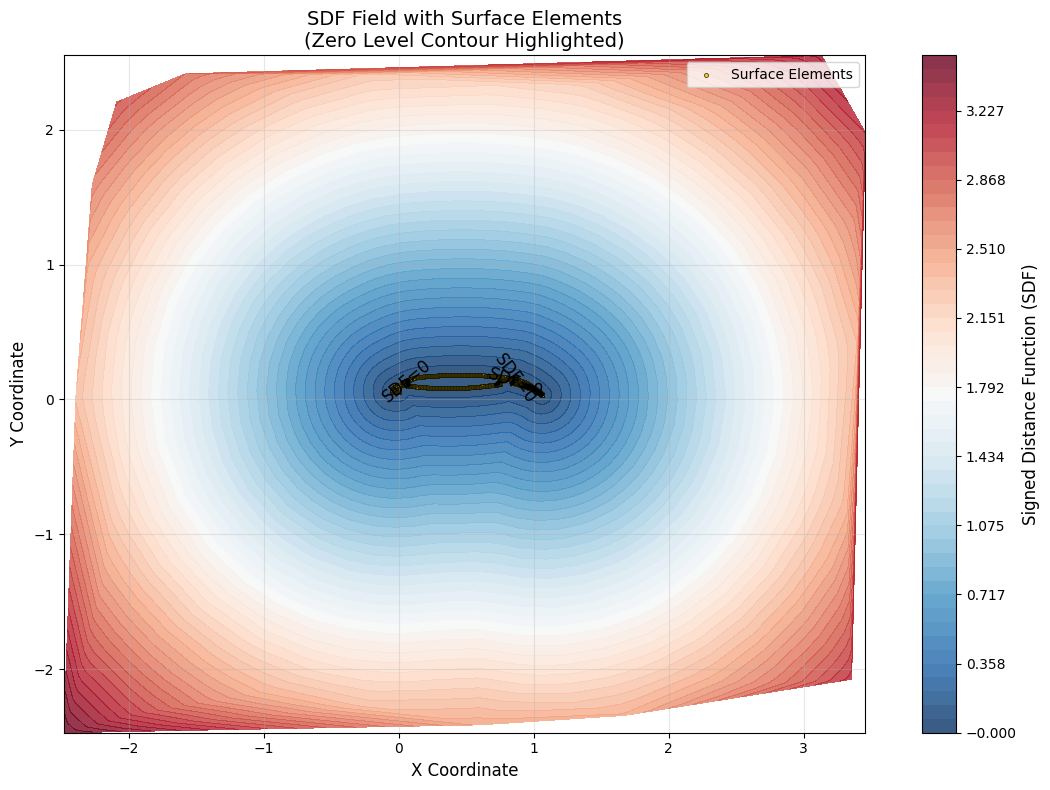

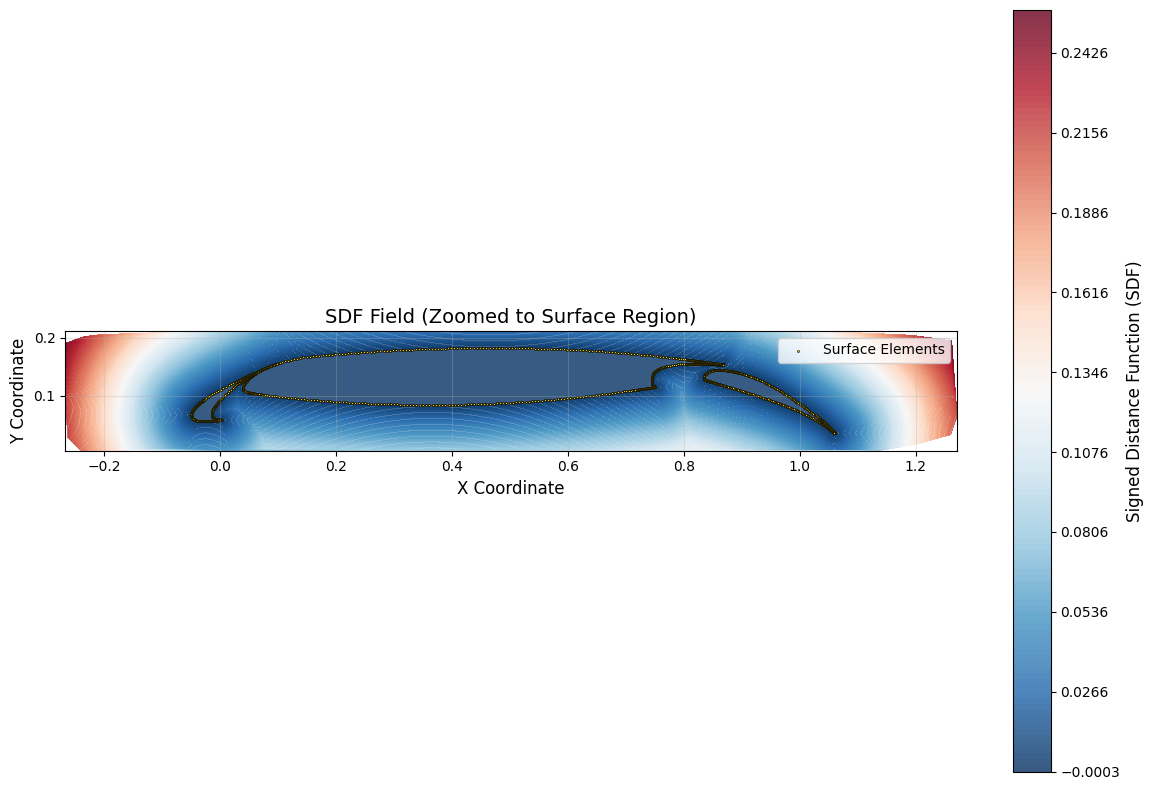

In [3]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import pyoche as pch

# Load the sample
sample = pch.Sample.from_file('/scratch/dmsm/gi.catalani/NASA_CRM_HL/pyoche_dataset/airfoil_dataset.pch/sample_TO_y17.680_alpha0.00_mach0.20.h5')

# Extract data
coordinates = sample['point_cloud_field/coordinates']
sdf_values = sample['point_cloud_field/sdf'].flatten()
element_id = sample['point_cloud_field/element_id'].flatten()

# Get coordinates
x = coordinates[:, 0]
y = coordinates[:, 1]

# Find surface elements (element_id != 0)
surface_mask = element_id != 0
x_surface = x[surface_mask]
y_surface = y[surface_mask]

# Create triangulation
triang = tri.Triangulation(x, y)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create tricontourf plot
levels = np.linspace(sdf_values.min(), sdf_values.max(), 50)
contourf = ax.tricontourf(triang, sdf_values, levels=levels, cmap='RdBu_r', alpha=0.8)

# Highlight the zero level contour
zero_contour = ax.tricontour(triang, sdf_values, levels=[0], colors='black', linewidths=3)
ax.clabel(zero_contour, inline=True, fontsize=12, fmt='SDF=0')

# Add surface elements as scatter plot
surface_scatter = ax.scatter(x_surface, y_surface, c='gold', s=8, alpha=0.9, 
                           edgecolors='black', linewidth=0.5, label='Surface Elements')

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label('Signed Distance Function (SDF)', fontsize=12)

# Formatting
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_title('SDF Field with Surface Elements\n(Zero Level Contour Highlighted)', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()

# Print some statistics
print(f"Total points: {len(x)}")
print(f"Surface points: {len(x_surface)}")
print(f"SDF range: {sdf_values.min():.4f} to {sdf_values.max():.4f}")
print(f"Surface element IDs: {np.unique(element_id[surface_mask])}")

plt.tight_layout()
plt.show()

# Optional: Create a second plot focusing on the surface region
fig2, ax2 = plt.subplots(figsize=(12, 8))

# Zoom in around surface elements
if len(x_surface) > 0:
    x_margin = (x_surface.max() - x_surface.min()) * 0.2
    y_margin = (y_surface.max() - y_surface.min()) * 0.2
    
    x_min = x_surface.min() - x_margin
    x_max = x_surface.max() + x_margin
    y_min = y_surface.min() - y_margin
    y_max = y_surface.max() + y_margin
    
    # Filter points in the zoom region
    zoom_mask = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
    
    if np.sum(zoom_mask) > 0:
        x_zoom = x[zoom_mask]
        y_zoom = y[zoom_mask]
        sdf_zoom = sdf_values[zoom_mask]
        
        # Create new triangulation for zoomed region
        triang_zoom = tri.Triangulation(x_zoom, y_zoom)
        
        # Create tricontourf plot for zoomed region
        levels_zoom = np.linspace(sdf_zoom.min(), sdf_zoom.max(), 125)
        contourf_zoom = ax2.tricontourf(triang_zoom, sdf_zoom, levels=levels_zoom, 
                                       cmap='RdBu_r', alpha=0.8)
        
        # Highlight zero level contour
        #zero_contour_zoom = ax2.tricontour(triang_zoom, sdf_zoom, levels=[0], 
                                          #colors='black', linewidths=3)
        #ax2.clabel(zero_contour_zoom, inline=True, fontsize=12, fmt='SDF=0')
        
        # Add surface elements
        surface_scatter_zoom = ax2.scatter(x_surface, y_surface, c='gold', s=2, 
                                         alpha=0.9, edgecolors='black', linewidth=0.5,
                                         label='Surface Elements')
        
        # Add colorbar
        cbar2 = plt.colorbar(contourf_zoom, ax=ax2)
        cbar2.set_label('Signed Distance Function (SDF)', fontsize=12)
        
        # Formatting
        ax2.set_xlabel('X Coordinate', fontsize=12)
        ax2.set_ylabel('Y Coordinate', fontsize=12)
        ax2.set_title('SDF Field (Zoomed to Surface Region)', fontsize=14)
        ax2.set_aspect('equal')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
    else:
        print("No points found in zoom region")
else:
    print("No surface elements found for zoom plot")

In [24]:
import torch
import re
LATENT_PATH = '/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/experiments/training/2025-07-18_16-23-42/modulations/'
train_latents = torch.load(LATENT_PATH + 'train_modulations.pt')
val_latents = torch.load(LATENT_PATH + 'val_modulations.pt')
train_latents['latents'].shape
train_latents['geometry_keys']
latents_full = train_latents['latents'].flatten(start_dim=1, end_dim=2).detach().cpu().numpy()
print(latents_full.shape)

# Extract configurations for each sample
configurations = [
    re.match(r'^(LDG|CLEAN|TO)', key[0]).group(1) 
    for key in train_latents['geometry_keys']
]

print(configurations)
# Example mapping of configurations to numerical values
config_mapping = {'LDG': 0, 'CLEAN': 1, 'TO': 2}
numerical_configurations = [config_mapping[conf] for conf in configurations]

(186, 144)
['LDG', 'CLEAN', 'LDG', 'LDG', 'LDG', 'LDG', 'TO', 'CLEAN', 'LDG', 'LDG', 'TO', 'CLEAN', 'CLEAN', 'TO', 'LDG', 'LDG', 'CLEAN', 'CLEAN', 'CLEAN', 'LDG', 'LDG', 'LDG', 'CLEAN', 'CLEAN', 'LDG', 'LDG', 'LDG', 'TO', 'LDG', 'TO', 'LDG', 'CLEAN', 'LDG', 'CLEAN', 'LDG', 'TO', 'CLEAN', 'CLEAN', 'CLEAN', 'LDG', 'LDG', 'CLEAN', 'TO', 'CLEAN', 'CLEAN', 'TO', 'TO', 'LDG', 'LDG', 'TO', 'CLEAN', 'TO', 'LDG', 'LDG', 'CLEAN', 'CLEAN', 'CLEAN', 'CLEAN', 'CLEAN', 'LDG', 'LDG', 'CLEAN', 'LDG', 'CLEAN', 'TO', 'LDG', 'TO', 'LDG', 'CLEAN', 'LDG', 'CLEAN', 'LDG', 'TO', 'CLEAN', 'LDG', 'LDG', 'CLEAN', 'TO', 'CLEAN', 'LDG', 'LDG', 'LDG', 'CLEAN', 'LDG', 'LDG', 'CLEAN', 'CLEAN', 'TO', 'LDG', 'CLEAN', 'CLEAN', 'LDG', 'CLEAN', 'LDG', 'LDG', 'LDG', 'LDG', 'TO', 'LDG', 'CLEAN', 'CLEAN', 'LDG', 'LDG', 'LDG', 'CLEAN', 'CLEAN', 'CLEAN', 'CLEAN', 'LDG', 'CLEAN', 'CLEAN', 'LDG', 'LDG', 'CLEAN', 'CLEAN', 'TO', 'LDG', 'CLEAN', 'LDG', 'CLEAN', 'LDG', 'LDG', 'LDG', 'TO', 'LDG', 'LDG', 'LDG', 'CLEAN', 'CLEAN', 'LDG

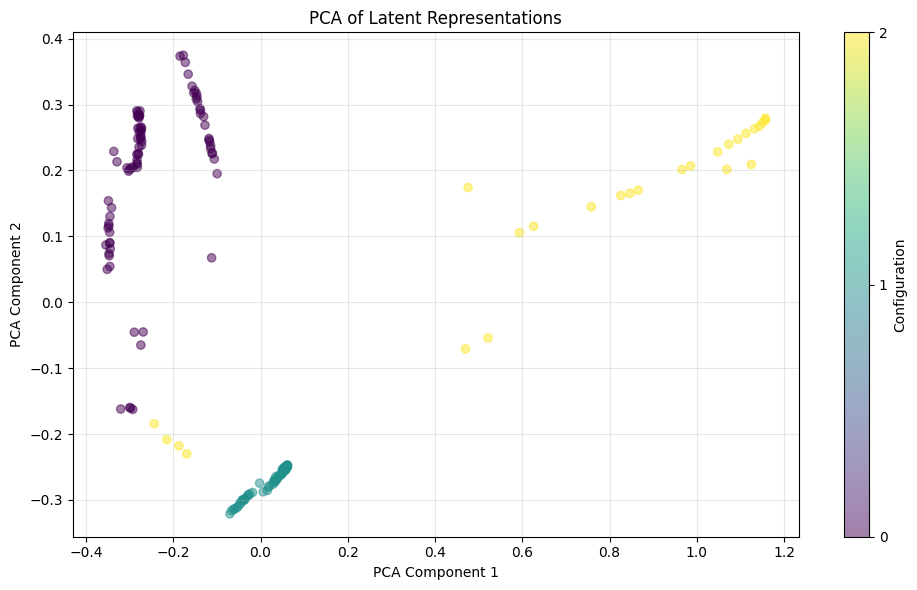

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
pca_latents = pca.fit_transform(latents_full)
# Plot PCA results
plt.figure(figsize=(10, 6))
plt.scatter(pca_latents[:, 0], pca_latents[:, 1],c=numerical_configurations, alpha=0.5)
plt.colorbar(ticks=[0, 1, 2], label='Configuration')
plt.title('PCA of Latent Representations')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total points: 74508
Surface points: 1588
range: -1.7279 to 1.0089
Surface element IDs: [1]


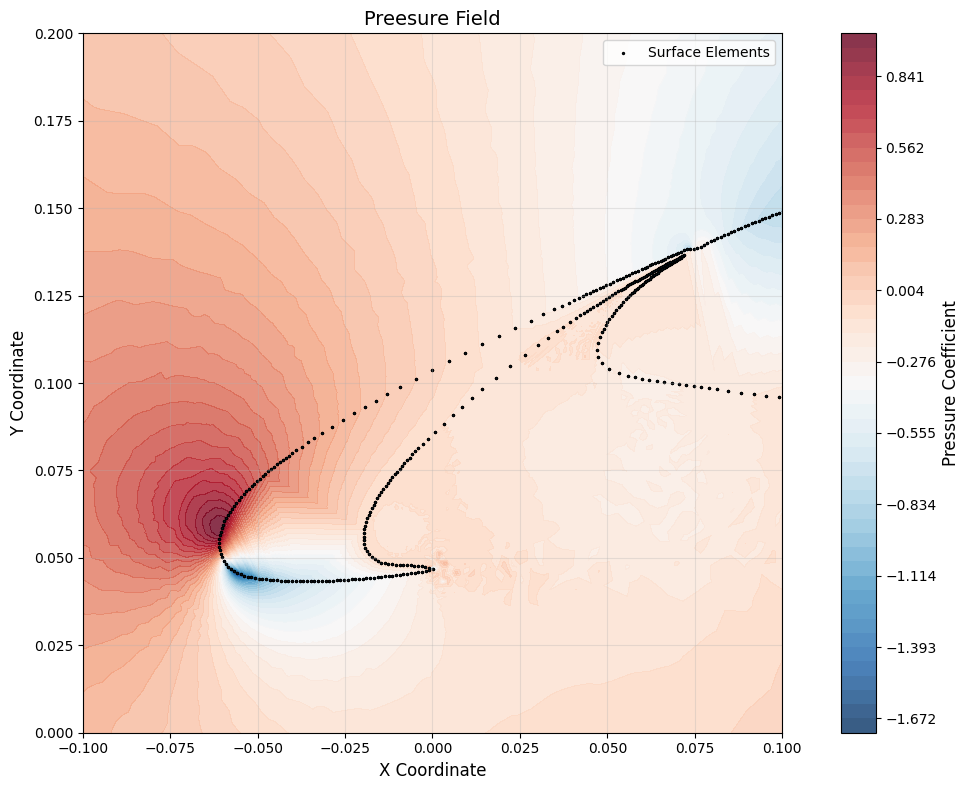

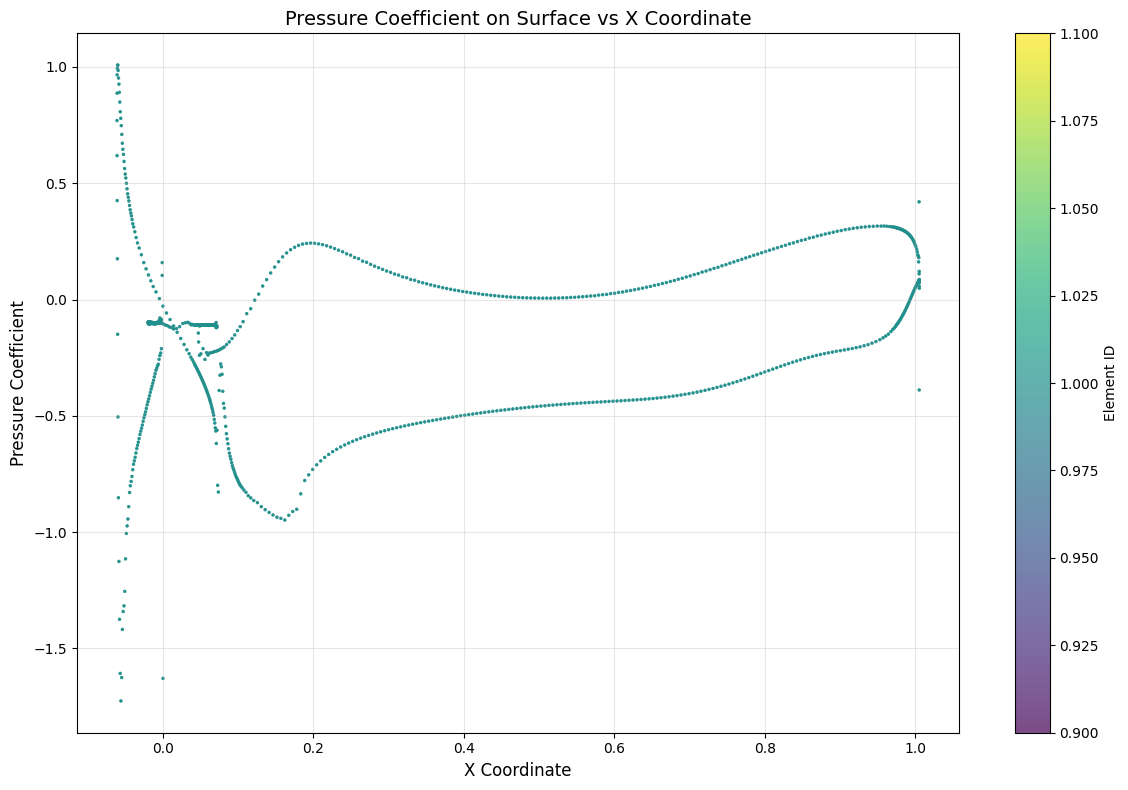

In [47]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import pyoche as pch

# Load the sample
sample = pch.Sample.from_file('/scratch/dmsm/gi.catalani/NASA_CRM_HL/pyoche_dataset/airfoil_dataset.pch/sample_TO_y22.466_alpha2.00_mach0.20.h5')

# Extract data
coordinates = sample['point_cloud_field/coordinates']
pressure_values = sample['point_cloud_field/PressureCoefficient'].flatten()
element_id = sample['point_cloud_field/element_id'].flatten()

# Get coordinates
x = coordinates[:, 0]
y = coordinates[:, 1]

# Find surface elements (element_id != 0)
surface_mask = element_id != 0
x_surface = x[surface_mask]
y_surface = y[surface_mask]

# Create triangulation
triang = tri.Triangulation(x, y)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create tricontourf plot
levels = np.linspace(pressure_values.min(), pressure_values.max(), 50)
contourf = ax.tricontourf(triang, pressure_values, levels=levels, cmap='RdBu_r', alpha=0.8)

# Add surface elements as scatter plot
surface_scatter = ax.scatter(x_surface, y_surface, s=2,
                           edgecolors='black',  label='Surface Elements')

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label('Pressure Coefficient', fontsize=12)

# Formatting
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(0, 0.2)
ax.set_title('Preesure Field', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()

# Print some statistics
print(f"Total points: {len(x)}")
print(f"Surface points: {len(x_surface)}")
print(f"range: {pressure_values.min():.4f} to {pressure_values.max():.4f}")
print(f"Surface element IDs: {np.unique(element_id[surface_mask])}")

plt.tight_layout()
plt.show()


# Plot the pressure coefficient on the surface vs the x coordinate with different colors for each element
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(x_surface, pressure_values[surface_mask], c=element_id[surface_mask], cmap='viridis', s=2, alpha=0.7)
plt.colorbar(label='Element ID')
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Pressure Coefficient', fontsize=12)  
ax.set_title('Pressure Coefficient on Surface vs X Coordinate', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()





SIMPLE AIRFOIL CONFIGURATION VISUALIZER
Configurations:
- LDG: Landing configuration
- TO: Takeoff configuration
- CLEAN: Clean configuration

Loading geometries...
Loading LDG geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG
Loaded 93 LDG geometries
Loading TO geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO
Loaded 89 TO geometries
Loading CLEAN geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_CLEAN
Loaded 89 CLEAN geometries
y=3.321: Found ['LDG', 'TO', 'CLEAN']
y=3.587: Found ['LDG', 'TO', 'CLEAN']
y=3.853: Found ['LDG', 'TO', 'CLEAN']
y=4.119: Found ['LDG', 'TO', 'CLEAN']
y=4.385: Found ['LDG', 'TO', 'CLEAN']
y=4.650: Found ['LDG', 'TO', 'CLEAN']
y=4.916: Found ['LDG', 'TO', 'CLEAN']
y=5.182: Found ['LDG', 'TO', 'CLEAN']
y=5.448: Found ['LDG', 'TO', 'CLEAN']
y=5.714: Found ['LDG', 'TO', 'CLEAN']
y=5.980: Fo

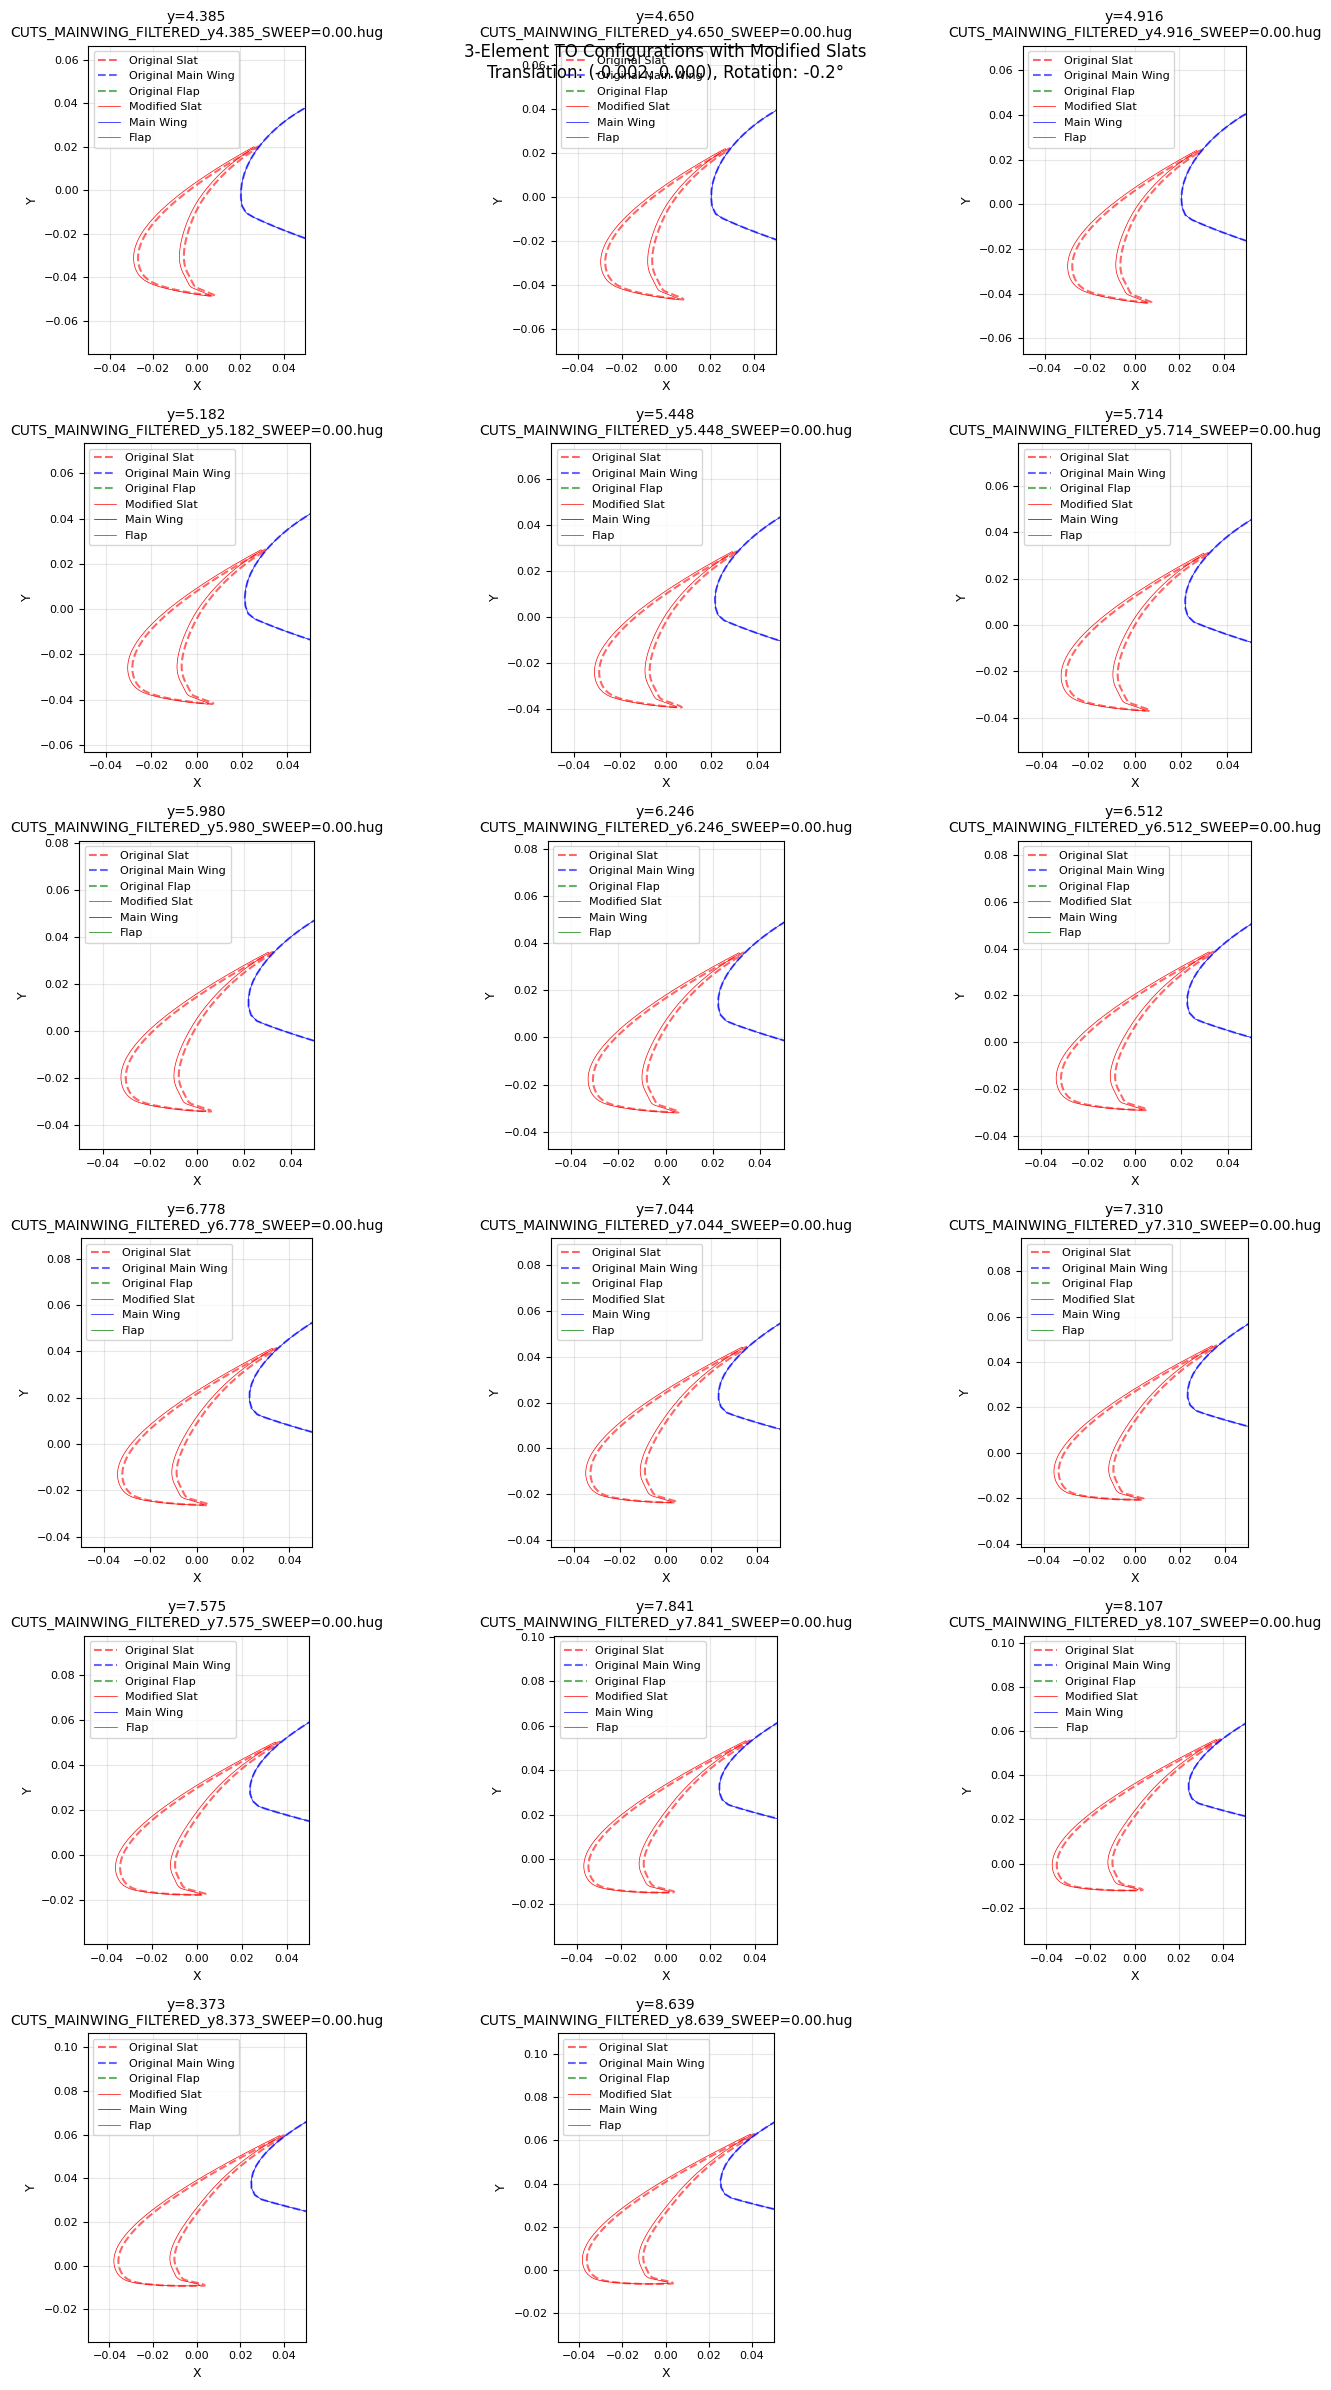


3-ELEMENT TO SLAT MODIFICATION SUMMARY
Configurations processed: 17
Transformation applied to slats:
  Translation: (-0.002, 0.000)
  Rotation: -0.2°
X-axis range: -0.05 to 0.05

Files saved: 17/17
Output directory: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED

Legend:
  Dashed lines: Original configuration
  Solid lines: Modified configuration (slat moved)

y=4.385: CUTS_MAINWING_FILTERED_y4.385_SWEEP=0.00.hug
y=4.650: CUTS_MAINWING_FILTERED_y4.650_SWEEP=0.00.hug
y=4.916: CUTS_MAINWING_FILTERED_y4.916_SWEEP=0.00.hug
y=5.182: CUTS_MAINWING_FILTERED_y5.182_SWEEP=0.00.hug
y=5.448: CUTS_MAINWING_FILTERED_y5.448_SWEEP=0.00.hug
y=5.714: CUTS_MAINWING_FILTERED_y5.714_SWEEP=0.00.hug
y=5.980: CUTS_MAINWING_FILTERED_y5.980_SWEEP=0.00.hug
y=6.246: CUTS_MAINWING_FILTERED_y6.246_SWEEP=0.00.hug
y=6.512: CUTS_MAINWING_FILTERED_y6.512_SWEEP=0.00.hug
y=6.778: CUTS_MAINWING_FILTERED_y6.778_SWEEP=0.00.hug
y=7.044: CUTS_MAINWING_FILTERED_y7.044_SW

In [39]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import re
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass


@dataclass
class GeometryData:
    """Container for airfoil geometry data"""
    filename: str
    filepath: str
    y_location: float
    sweep_angle: Optional[float]
    elements: List[np.ndarray]
    config_type: str
    
    @property
    def num_elements(self) -> int:
        return len(self.elements)


class SimpleAirfoilVisualizer:
    """Simple class to visualize LDG, TO, and CLEAN airfoil configurations"""
    
    def __init__(self, data_directories: Dict[str, str]):
        self.data_directories = data_directories
        self.geometries = {}  # {config_type: [GeometryData, ...]}
        
    def extract_y_location(self, filename: str) -> Optional[float]:
        """Extract y location from filename"""
        match = re.search(r'y([\d.]+)', os.path.basename(filename))
        return float(match.group(1)) if match else None
    
    def extract_sweep_angle(self, filename: str) -> Optional[float]:
        """Extract sweep angle from filename"""
        match = re.search(r'SWEEP=([-]?[\d.]+)', os.path.basename(filename))
        if match:
            sweep_str = match.group(1).rstrip('.')
            try:
                return float(sweep_str)
            except ValueError:
                return None
        return None
    
    def _reorder_polygon(self, pts: np.ndarray) -> np.ndarray:
        """Reorder points to form a proper airfoil polygon"""
        if len(pts) < 3:
            return pts
            
        # Find trailing edge (max x)
        trailing_edge_idx = np.argmax(pts[:, 0])
        
        # Split into upper and lower surfaces
        upper = pts[:trailing_edge_idx+1]
        lower = pts[trailing_edge_idx+1:][::-1]
        
        # Combine
        poly = np.vstack((upper, lower))
        
        # Remove duplicate endpoint if present
        if len(poly) > 1 and np.linalg.norm(poly[0] - poly[-1]) < 1e-6:
            poly = poly[:-1]
            
        return poly
    
    def load_hug_file(self, filepath: str) -> Tuple[List[np.ndarray], int]:
        """Load and parse .hug file"""
        try:
            with open(filepath, 'r') as f:
                lines = f.readlines()
            
            num_elements = int(lines[0].strip())
            elements = []
            line_idx = 1
            
            for elem_idx in range(num_elements):
                if line_idx >= len(lines):
                    break
                    
                num_points = int(lines[line_idx].strip())
                line_idx += 1
                
                element_coords = []
                for i in range(num_points):
                    if line_idx >= len(lines):
                        break
                        
                    line = lines[line_idx].strip()
                    if line and not line.startswith('#'):
                        coords = [float(x) for x in line.split()]
                        if len(coords) >= 2:
                            element_coords.append([coords[0], coords[1]])
                    line_idx += 1
                
                if element_coords:
                    element_coords = np.array(element_coords)
                    elements.append(self._reorder_polygon(element_coords))
            
            return elements, num_elements
            
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return [], 0
    
    def load_all_geometries(self):
        """Load all geometries from directories"""
        for config_type, data_directory in self.data_directories.items():
            print(f"Loading {config_type} geometries from {data_directory}")
            
            pattern = os.path.join(data_directory, "**/*.hug")
            geometry_files = glob.glob(pattern, recursive=True)
            
            geometries = []
            for filepath in geometry_files:
                y_location = self.extract_y_location(filepath)
                sweep_angle = self.extract_sweep_angle(filepath)
                elements, num_elements = self.load_hug_file(filepath)
                
                if elements and y_location is not None:
                    geometry_data = GeometryData(
                        filename=os.path.basename(filepath),
                        filepath=filepath,
                        y_location=y_location,
                        sweep_angle=sweep_angle,
                        elements=elements,
                        config_type=config_type
                    )
                    geometries.append(geometry_data)
            
            self.geometries[config_type] = geometries
            print(f"Loaded {len(geometries)} {config_type} geometries")
    
    def find_matching_sets(self) -> List[Tuple[float, Dict[str, GeometryData]]]:
        """Find matching geometries across all configurations for each y_location"""
        y_locations = set()
        
        # Collect all y_locations
        for config_type, geometries in self.geometries.items():
            for geom in geometries:
                y_locations.add(geom.y_location)
        
        matching_sets = []
        
        for y_loc in sorted(y_locations):
            geom_set = {}
            
            # Find geometry for each config type at this y_location
            for config_type, geometries in self.geometries.items():
                for geom in geometries:
                    if abs(geom.y_location - y_loc) < 1e-6:
                        geom_set[config_type] = geom
                        break
            
            # Only add if we have at least one geometry
            if geom_set:
                matching_sets.append((y_loc, geom_set))
                configs_found = list(geom_set.keys())
                print(f"y={y_loc:.3f}: Found {configs_found}")
        
        return matching_sets
    
    def visualize_configurations(self, y_locations: List[float] = None, max_locations: int = 8):
        """
        Visualize LDG, TO, and CLEAN configurations in the same subplot for multiple y_locations
        """
        matching_sets = self.find_matching_sets()
        
        if not matching_sets:
            print("No matching geometries found")
            return
        
        # Filter by requested y_locations or use first few
        if y_locations is not None:
            filtered_sets = []
            for target_y in y_locations:
                for y_loc, geom_set in matching_sets:
                    if abs(y_loc - target_y) < 1e-6:
                        filtered_sets.append((y_loc, geom_set))
                        break
            matching_sets = filtered_sets
        else:
            # Use first max_locations
            matching_sets = matching_sets[:max_locations]
        
        if not matching_sets:
            print("No geometries found for specified y_locations")
            return
        
        # Create subplot grid: rows = ceil(n_locations/2), cols = 2
        n_locations = len(matching_sets)
        n_cols = 2
        n_rows = (n_locations + 1) // 2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 4*n_rows))
        
        # Handle single subplot cases
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten() if n_locations > 1 else [axes]
        
        # Configuration styling
        config_styles = {
            'LDG': {'linestyle': '-', 'linewidth': 2.5, 'alpha': 1.0},
            'TO': {'linestyle': '--', 'linewidth': 2.0, 'alpha': 0.8}, 
            'CLEAN': {'linestyle': '-.', 'linewidth': 2.0, 'alpha': 0.9}
        }
        
        # Element colors (same for all configs for easy comparison)
        element_colors = ['red', 'blue', 'green', 'orange', 'purple']
        
        # Process each y_location
        for plot_idx, (y_location, geom_set) in enumerate(matching_sets):
            if plot_idx >= len(axes_flat):
                break
                
            ax = axes_flat[plot_idx]
            print(f"\nPlotting y_location={y_location:.3f}")
            
            # Plot each configuration in the same subplot
            for config_type in ['LDG', 'TO', 'CLEAN']:
                if config_type in geom_set:
                    geom = geom_set[config_type]
                    style = config_styles[config_type]
                    
                    print(f"  {config_type}: {geom.filename} ({geom.num_elements} elements)")
                    
                    # Plot each element
                    for elem_idx, element in enumerate(geom.elements):
                        color = element_colors[elem_idx % len(element_colors)]
                        
                        # Create label with config and element info
                        if config_type == 'LDG':
                            if elem_idx == 0:
                                elem_name = 'Slat'
                            elif elem_idx == 1:
                                elem_name = 'Main'
                            elif elem_idx == 2:
                                elem_name = 'Flap'
                            else:
                                elem_name = f'E{elem_idx+1}'
                        elif config_type == 'TO':
                            if geom.num_elements == 1:
                                elem_name = 'Sealed'
                            else:
                                if elem_idx == 0:
                                    elem_name = 'Slat'
                                elif elem_idx == 1:
                                    elem_name = 'Main'
                                elif elem_idx == 2:
                                    elem_name = 'Flap'
                                else:
                                    elem_name = f'E{elem_idx+1}'
                        else:  # CLEAN
                            elem_name = 'Clean'
                        
                        label = f'{config_type}-{elem_name}'
                        
                        ax.plot(element[:, 0], element[:, 1], 
                               color=color, 
                               linestyle=style['linestyle'],
                               linewidth=style['linewidth'],
                               alpha=style['alpha'],
                               label=label)
            
            # Subplot formatting
            ax.set_title(f'y = {y_location:.3f}', fontsize=12, fontweight='bold')
            ax.set_xlabel('X', fontsize=10)
            ax.set_ylabel('Y', fontsize=10)
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=9)
        
        # Hide unused subplots
        for i in range(n_locations, len(axes_flat)):
            axes_flat[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle('Airfoil Configurations Overlay\n(Solid = LDG, Dashed = TO, Dash-dot = CLEAN)', 
                     fontsize=14, y=0.98)
        plt.show()
        
        # Print summary
        print(f"\n{'='*60}")
        print("VISUALIZATION SUMMARY")
        print(f"{'='*60}")
        print("Line styles:")
        print("  LDG (Landing):  ——————  (solid)")
        print("  TO (Takeoff):   - - - -  (dashed)")
        print("  CLEAN:          -·-·-·-  (dash-dot)")
        print()
        for y_location, geom_set in matching_sets:
            print(f"y={y_location:.3f}:")
            for config_type in ['LDG', 'TO', 'CLEAN']:
                if config_type in geom_set:
                    geom = geom_set[config_type]
                    print(f"  {config_type}: {geom.num_elements} elements - {geom.filename}")
                else:
                    print(f"  {config_type}: Not available")
    
    def apply_transformation(self, points: np.ndarray, translation: np.ndarray, 
                           rotation: float, rotation_center: Optional[np.ndarray] = None) -> np.ndarray:
        """Apply translation and rotation to points"""
        if rotation_center is None:
            rotation_center = np.mean(points, axis=0)
        
        # Translate first
        translated = points + translation
        
        # Rotate around specified center
        centered = translated - rotation_center
        cos_theta = np.cos(rotation)
        sin_theta = np.sin(rotation)
        rotation_matrix = np.array([[cos_theta, -sin_theta],
                                   [sin_theta, cos_theta]])
        
        rotated = np.dot(centered, rotation_matrix.T)
        return rotated + rotation_center
    
    def save_hug_file(self, elements: List[np.ndarray], output_path: str):
        """Save elements to .hug file"""
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        
        with open(output_path, 'w') as f:
            # Write number of elements
            f.write(f"{len(elements)}\n")
            
            # Write each element
            for element in elements:
                f.write(f"{len(element)}\n")
                for point in element:
                    f.write(f"{point[0]:.8f} {point[1]:.8f}\n")
        
        print(f"    Saved: {output_path}")
    
    def move_slats_for_3_element_TO(self, translation: np.ndarray = np.array([-0.002, 0.000]), 
                                   rotation: float = np.radians(-0.2), 
                                   x_limits: Tuple[float, float] = (-0.05, 0.05),
                                   save_files: bool = True):
        """
        For TO configurations with 3 elements, move the slat (element 0) with specified transformation
        """
        if 'TO' not in self.geometries:
            print("No TO geometries loaded")
            return
        
        # Find 3-element TO configurations
        three_element_tos = []
        for geom in self.geometries['TO']:
            if geom.num_elements == 3:
                three_element_tos.append(geom)
        
        if not three_element_tos:
            print("No 3-element TO configurations found")
            return
        
        print(f"Found {len(three_element_tos)} TO configurations with 3 elements")
        print(f"Applying transformation: translation=({translation[0]:.3f}, {translation[1]:.3f}), rotation={np.degrees(rotation):.1f}°")
        
        if save_files:
            output_directory = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED"
            print(f"Saving to: {output_directory}")
        
        # Sort by y-location
        three_element_tos = sorted(three_element_tos, key=lambda g: g.y_location)
        
        # Calculate grid dimensions
        n_geometries = len(three_element_tos)
        n_cols = 3  # 3 plots per row
        n_rows = (n_geometries + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        
        # Handle single subplot cases
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten() if n_geometries > 1 else [axes]
        
        # Element colors
        element_colors = ['red', 'blue', 'green']
        element_names = ['Slat', 'Main Wing', 'Flap']
        
        saved_count = 0
        
        # Process each 3-element TO geometry
        for plot_idx, geom in enumerate(three_element_tos):
            if plot_idx >= len(axes_flat):
                break
                
            ax = axes_flat[plot_idx]
            
            print(f"  Processing y={geom.y_location:.3f}: {geom.filename}")
            
            # Apply transformation to slat (element 0)
            original_slat = geom.elements[0]
            transformed_slat = self.apply_transformation(original_slat, translation, rotation)
            
            # Create new elements list with transformed slat
            new_elements = [transformed_slat] + geom.elements[1:]
            
            # Save file if requested
            if save_files:
                output_path = os.path.join(output_directory, geom.filename)
                try:
                    self.save_hug_file(new_elements, output_path)
                    saved_count += 1
                except Exception as e:
                    print(f"    Error saving {output_path}: {e}")
            
            # Plot original elements in dashed lines (for reference)
            for elem_idx, element in enumerate(geom.elements):
                color = element_colors[elem_idx]
                label = f'Original {element_names[elem_idx]}'
                
                ax.plot(element[:, 0], element[:, 1], 
                       color=color, 
                       linestyle='--',
                       linewidth=1.5,
                       alpha=0.6,
                       label=label)
            
            # Plot modified configuration
            for elem_idx, element in enumerate(new_elements):
                color = element_colors[elem_idx]
                
                if elem_idx == 0:  # Slat - transformed
                    label = f'Modified {element_names[elem_idx]}'
                    linestyle = '-'
                    linewidth = 0.5
                    alpha = 1.0
                else:  # Other elements - unchanged
                    label = f'{element_names[elem_idx]}'
                    linestyle = '-'
                    linewidth = 0.5
                    alpha = 1.0
                
                ax.plot(element[:, 0], element[:, 1], 
                       color=color, 
                       linestyle=linestyle,
                       linewidth=linewidth,
                       alpha=alpha,
                       label=label)
            
            # Subplot formatting
            ax.set_title(f'y={geom.y_location:.3f}\n{geom.filename}', fontsize=10)
            ax.set_xlabel('X', fontsize=9)
            ax.set_ylabel('Y', fontsize=9)
            ax.legend(fontsize=8)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=8)
            
            # Set X-axis limits
            ax.set_xlim(x_limits)
        
        # Hide unused subplots
        for i in range(n_geometries, len(axes_flat)):
            axes_flat[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle(f'3-Element TO Configurations with Modified Slats\n' + 
                     f'Translation: ({translation[0]:.3f}, {translation[1]:.3f}), Rotation: {np.degrees(rotation):.1f}°', 
                     fontsize=12, y=0.98)
        plt.show()
        
        # Print summary
        print(f"\n{'='*60}")
        print("3-ELEMENT TO SLAT MODIFICATION SUMMARY")
        print(f"{'='*60}")
        print(f"Configurations processed: {n_geometries}")
        print(f"Transformation applied to slats:")
        print(f"  Translation: ({translation[0]:.3f}, {translation[1]:.3f})")
        print(f"  Rotation: {np.degrees(rotation):.1f}°")
        print(f"X-axis range: {x_limits[0]} to {x_limits[1]}")
        
        if save_files:
            print(f"\nFiles saved: {saved_count}/{n_geometries}")
            print(f"Output directory: {output_directory}")
        
        print()
        print("Legend:")
        print("  Dashed lines: Original configuration")
        print("  Solid lines: Modified configuration (slat moved)")
        print()
        for geom in three_element_tos:
            print(f"y={geom.y_location:.3f}: {geom.filename}")

    def visualize_all_TO_configurations(self, x_limits: Tuple[float, float] = (0.0, 0.1)):
        """
        Plot all TO configurations with limited X-axis range
        """
        if 'TO' not in self.geometries:
            print("No TO geometries loaded")
            return
        
        to_geometries = self.geometries['TO']
        n_geometries = len(to_geometries)
        
        if n_geometries == 0:
            print("No TO geometries found")
            return
        
        # Calculate grid dimensions
        n_cols = 4  # 4 plots per row
        n_rows = (n_geometries + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
        
        # Handle single subplot cases
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten() if n_geometries > 1 else [axes]
        
        # Element colors
        element_colors = ['red', 'blue', 'green', 'orange', 'purple']
        
        # Sort geometries by y_location
        sorted_geometries = sorted(to_geometries, key=lambda g: g.y_location)
        
        print(f"Plotting {n_geometries} TO configurations with X-axis from {x_limits[0]} to {x_limits[1]}")
        
        # Plot each TO geometry
        for plot_idx, geom in enumerate(sorted_geometries):
            if plot_idx >= len(axes_flat):
                break
                
            ax = axes_flat[plot_idx]
            
            print(f"  y={geom.y_location:.3f}: {geom.filename} ({geom.num_elements} elements)")
            
            # Plot each element
            for elem_idx, element in enumerate(geom.elements):
                color = element_colors[elem_idx % len(element_colors)]
                
                # Element labels for TO
                if geom.num_elements == 1:
                    label = 'Sealed'
                else:
                    if elem_idx == 0:
                        label = 'Slat'
                    elif elem_idx == 1:
                        label = 'Main Wing'
                    elif elem_idx == 2:
                        label = 'Flap'
                    else:
                        label = f'Element {elem_idx+1}'
                
                ax.plot(element[:, 0], element[:, 1], 
                       color=color, 
                       linewidth=2,
                       label=label)
            
            # Subplot formatting
            ax.set_title(f'TO - y={geom.y_location:.3f}\n{geom.filename}', fontsize=10)
            ax.set_xlabel('X', fontsize=9)
            ax.set_ylabel('Y', fontsize=9)
            ax.legend(fontsize=8)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=8)
            
            # Set X-axis limits
            ax.set_xlim(x_limits)
        
        # Hide unused subplots
        for i in range(n_geometries, len(axes_flat)):
            axes_flat[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle(f'All TO Configurations (X-axis: {x_limits[0]} to {x_limits[1]})', 
                     fontsize=14, y=0.98)
        plt.show()
        
        # Print summary
        print(f"\n{'='*60}")
        print("TO CONFIGURATIONS SUMMARY")
        print(f"{'='*60}")
        print(f"Total TO configurations: {n_geometries}")
        print(f"X-axis range: {x_limits[0]} to {x_limits[1]}")
        print()
        for geom in sorted_geometries:
            print(f"y={geom.y_location:.3f}: {geom.num_elements} elements - {geom.filename}")

    def list_available_y_locations(self):
        """List all available y_locations and their configurations"""
        matching_sets = self.find_matching_sets()
        
        print(f"\n{'='*60}")
        print("AVAILABLE Y-LOCATIONS")
        print(f"{'='*60}")
        
        for y_location, geom_set in matching_sets:
            configs = list(geom_set.keys())
            print(f"y={y_location:.3f}: {configs}")
        
        print(f"\nTotal: {len(matching_sets)} y-locations available")
        return [y_loc for y_loc, _ in matching_sets]


def main():
    """Main function"""
    
    # Configuration
    data_directories = {
        'LDG': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG",
        'TO': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO",
        'CLEAN': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_CLEAN"
    }
    
    print("="*60)
    print("SIMPLE AIRFOIL CONFIGURATION VISUALIZER")
    print("="*60)
    print("Configurations:")
    print("- LDG: Landing configuration")
    print("- TO: Takeoff configuration") 
    print("- CLEAN: Clean configuration")
    print("="*60)
    
    # Initialize visualizer
    visualizer = SimpleAirfoilVisualizer(data_directories)
    
    # Load geometries
    print("\nLoading geometries...")
    visualizer.load_all_geometries()
    
    # List available y_locations
    available_y_locations = visualizer.list_available_y_locations()
    
    if available_y_locations:
        print(f"\nExample usage:")
        print(f"# Move and save slats for 3-element TO configurations:")
        print(f"visualizer.move_slats_for_3_element_TO(save_files=True)")
        print(f"")
        print(f"# Visualization only (no saving):")
        print(f"visualizer.move_slats_for_3_element_TO(save_files=False)")
        print(f"")
        print(f"# Custom parameters:")
        print(f"visualizer.move_slats_for_3_element_TO(")
        print(f"    translation=np.array([-0.002, 0.000]),")
        print(f"    rotation=np.radians(-0.2),")
        print(f"    save_files=True")
        print(f")")
        
        # Process and save 3-element TO configurations automatically
        print(f"\nProcessing and saving 3-element TO configurations...")
        visualizer.move_slats_for_3_element_TO(
            translation=np.array([-0.002, 0.000]),
            rotation=np.radians(-0.2),
            save_files=True
        )
    
    return visualizer


if __name__ == "__main__":
    visualizer = main()

CLEAN SLAT SEPARATION SYSTEM
Strategy:
- Find slat region in sealed TO elements
- X-range: 0.04 to 0.06
- Y-range: 0.10 to 0.12
- Separate slat and apply transformation

Loading geometries...
Loading LDG geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG
Loaded 93 LDG geometries
Loading TO geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO
Loaded 89 TO geometries
Loading CLEAN geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_CLEAN
Loaded 89 CLEAN geometries

Processing sealed TO configurations...
Found 7 sealed TO configurations at target y_locations
Target y_locations: [11.032, 12.628, 13.957, 16.882, 17.946, 18.744, 20.871]
Y-tolerance: ±0.01
Slat detection parameters:
  Min separation between closure points: 10
  Distance threshold for closure: 0.0100
Slat transformation:
  Translation: (-0.020, -0.010)
  Rotati

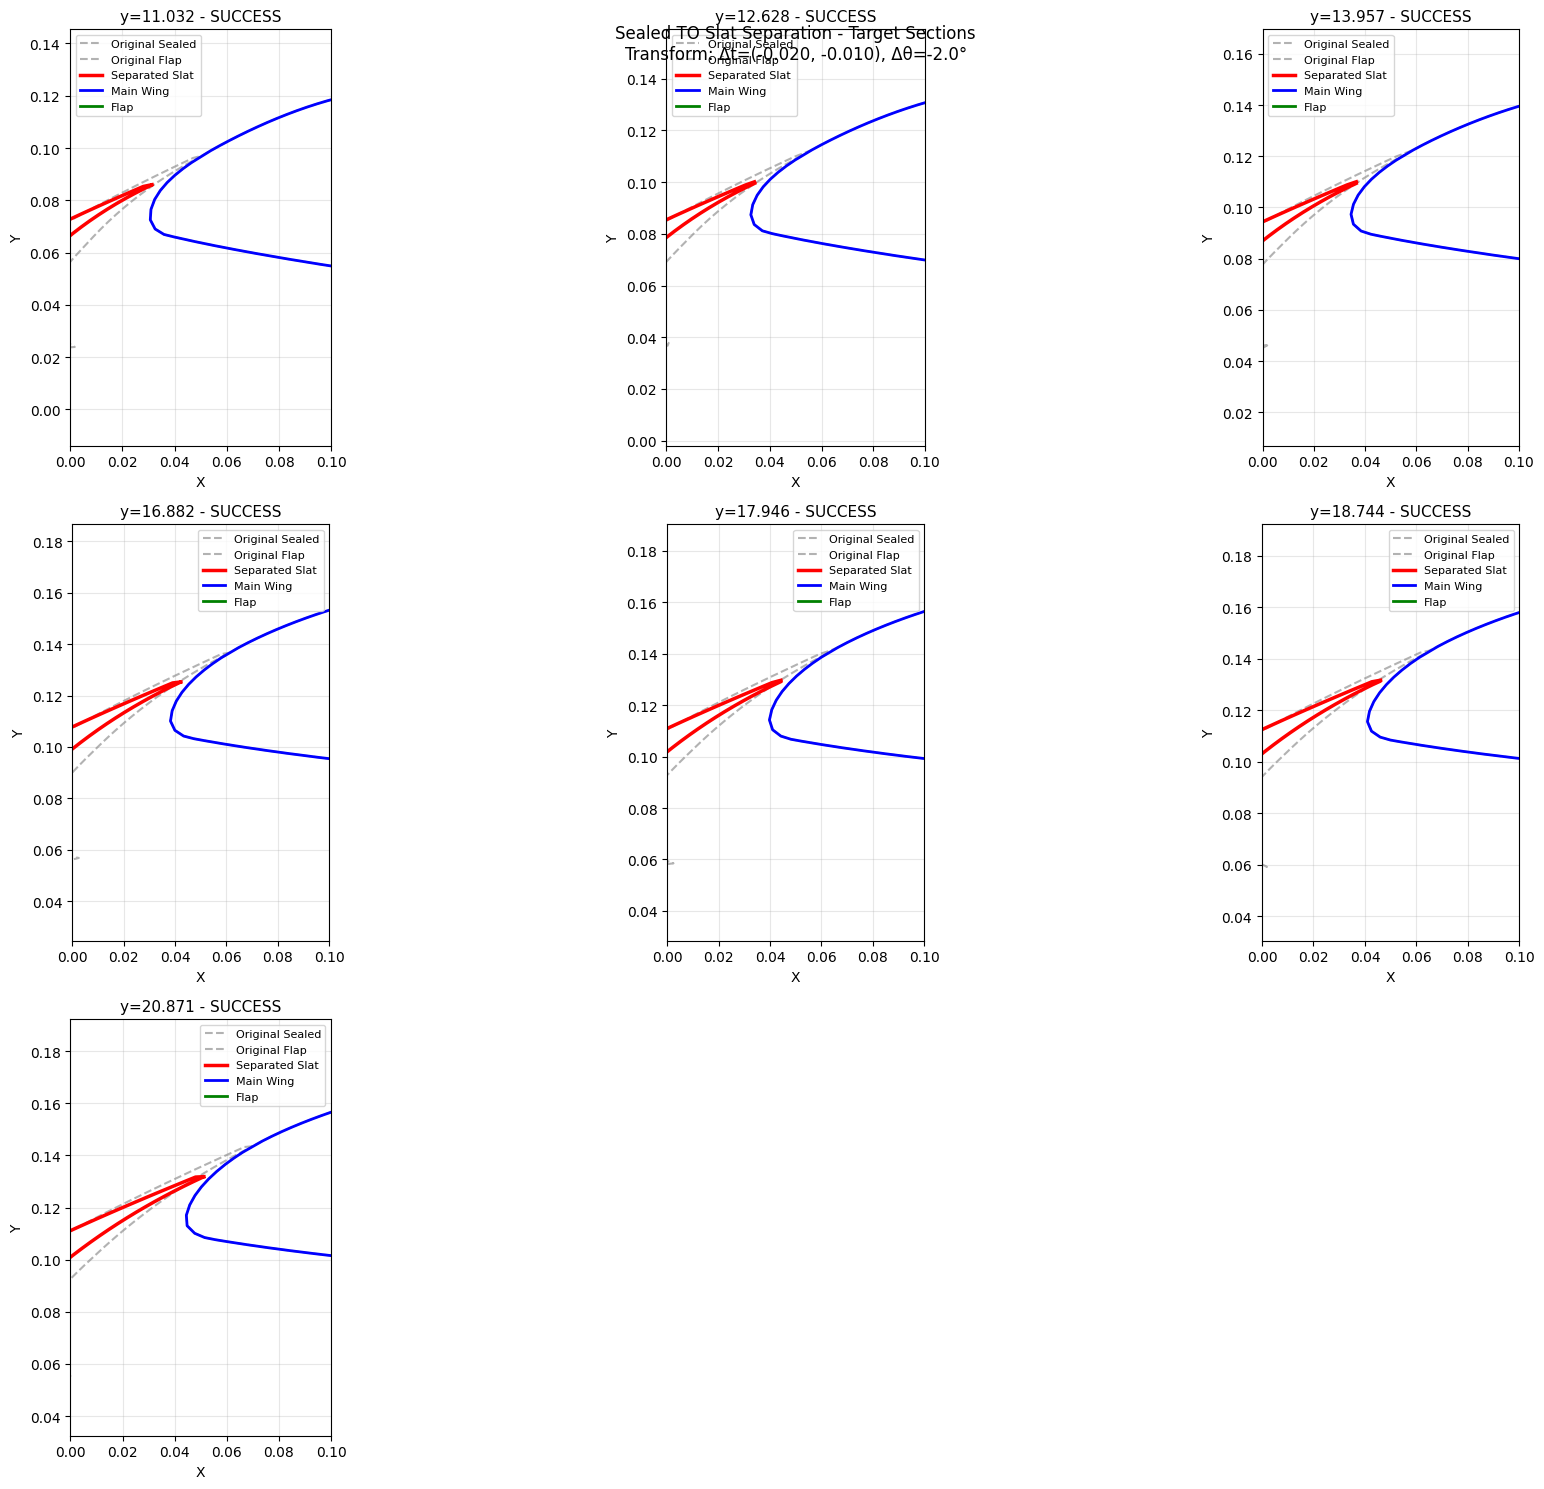


SLAT SEPARATION RESULTS
Target y_locations: [11.032, 12.628, 13.957, 16.882, 17.946, 18.744, 20.871]
Sections found: 7
Successful separations: 7
Failed separations: 0
Success rate: 100.0%

Detection parameters:
  Min separation between closure points: 10
  Distance threshold for closure: 0.0100

Transformation applied to slats:
  Translation: (-0.020, -0.010)
  Rotation: -2.0°

Processed sections:
  y=11.032: SUCCESS
  y=12.628: SUCCESS
  y=13.957: SUCCESS
  y=16.882: SUCCESS
  y=17.946: SUCCESS
  y=18.744: SUCCESS
  y=20.871: SUCCESS

Example usage:
# Default separation:
separator.process_sealed_to_configurations()

# Custom parameters for specific sections:
separator.process_sealed_to_configurations(
    slat_translation=np.array([-0.03, -0.015]),
    slat_rotation=np.radians(-3),
    target_y_locations=[11.032, 12.628, 13.957],
    min_separation=15,
    distance_threshold=0.005
)
Found 7 sealed TO configurations at target y_locations
Target y_locations: [11.032, 12.628, 13.957, 16

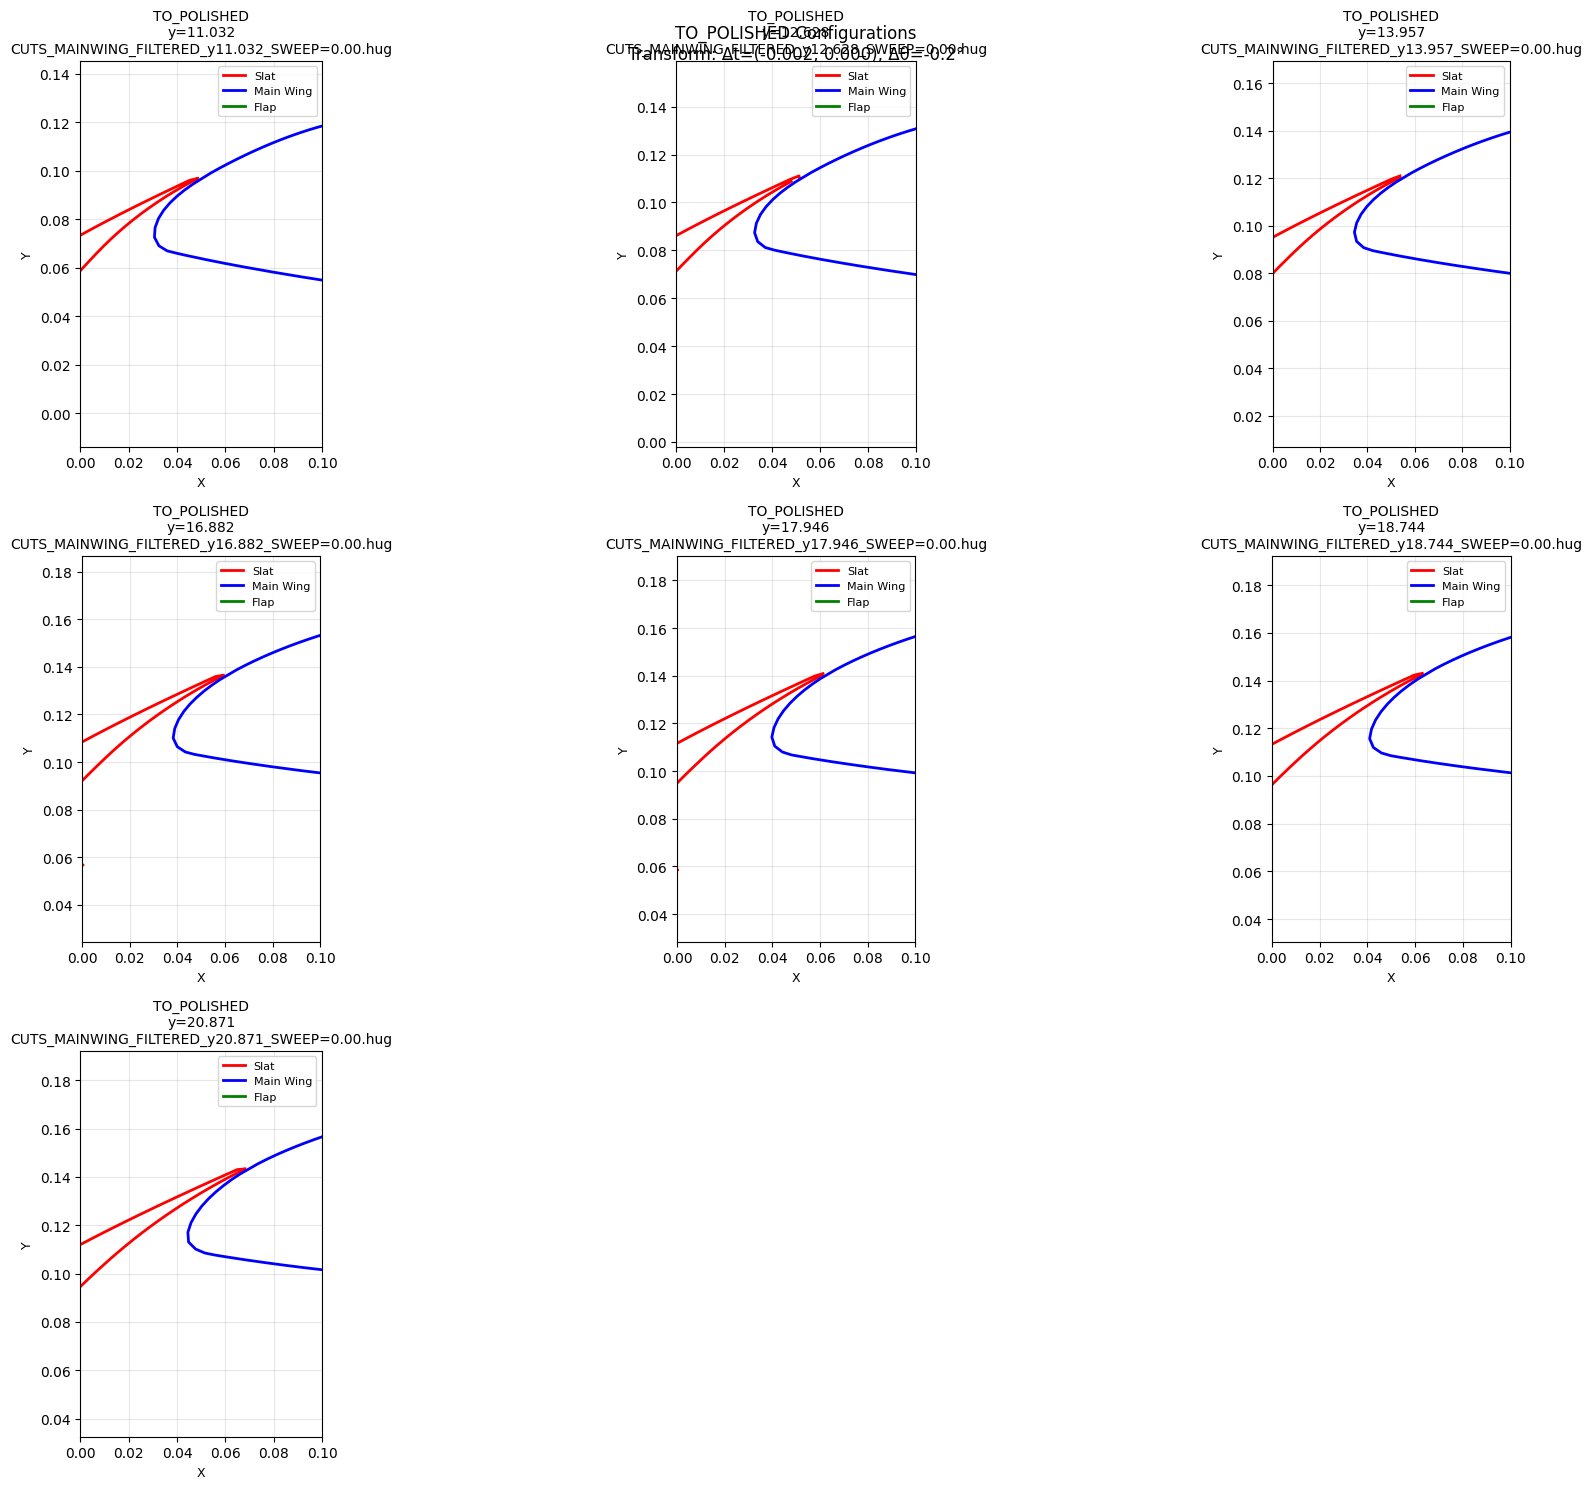


POLISHED TO GENERATION RESULTS
Target sections: 7
Sections found: 7
Successfully saved: 7
Failed: 0
Success rate: 100.0%

Output directory: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED
Files created:
  CUTS_MAINWING_FILTERED_y11.032_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y12.628_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y13.957_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y16.882_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y17.946_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y18.744_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y20.871_SWEEP=0.00.hug

Transformation applied:
  Translation: (-0.002, 0.000)
  Rotation: -0.2°


In [38]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import re
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass


@dataclass
class GeometryData:
    """Container for airfoil geometry data"""
    filename: str
    filepath: str
    y_location: float
    sweep_angle: Optional[float]
    elements: List[np.ndarray]
    config_type: str
    
    @property
    def num_elements(self) -> int:
        return len(self.elements)


class SlatSeparator:
    """Clean implementation of slat separation using CLEAN reference"""
    
    def __init__(self, data_directories: Dict[str, str]):
        self.data_directories = data_directories
        self.geometries = {}
        
    def extract_y_location(self, filename: str) -> Optional[float]:
        """Extract y location from filename"""
        match = re.search(r'y([\d.]+)', os.path.basename(filename))
        return float(match.group(1)) if match else None
    
    def extract_sweep_angle(self, filename: str) -> Optional[float]:
        """Extract sweep angle from filename"""
        match = re.search(r'SWEEP=([-]?[\d.]+)', os.path.basename(filename))
        if match:
            sweep_str = match.group(1).rstrip('.')
            try:
                return float(sweep_str)
            except ValueError:
                return None
        return None
    
    def _reorder_polygon(self, pts: np.ndarray) -> np.ndarray:
        """Reorder points to form a proper airfoil polygon"""
        if len(pts) < 3:
            return pts
            
        trailing_edge_idx = np.argmax(pts[:, 0])
        upper = pts[:trailing_edge_idx+1]
        lower = pts[trailing_edge_idx+1:][::-1]
        poly = np.vstack((upper, lower))
        
        if len(poly) > 1 and np.linalg.norm(poly[0] - poly[-1]) < 1e-6:
            poly = poly[:-1]
            
        return poly
    
    def load_hug_file(self, filepath: str) -> Tuple[List[np.ndarray], int]:
        """Load and parse .hug file"""
        try:
            with open(filepath, 'r') as f:
                lines = f.readlines()
            
            num_elements = int(lines[0].strip())
            elements = []
            line_idx = 1
            
            for elem_idx in range(num_elements):
                if line_idx >= len(lines):
                    break
                    
                num_points = int(lines[line_idx].strip())
                line_idx += 1
                
                element_coords = []
                for i in range(num_points):
                    if line_idx >= len(lines):
                        break
                        
                    line = lines[line_idx].strip()
                    if line and not line.startswith('#'):
                        coords = [float(x) for x in line.split()]
                        if len(coords) >= 2:
                            element_coords.append([coords[0], coords[1]])
                    line_idx += 1
                
                if element_coords:
                    element_coords = np.array(element_coords)
                    elements.append(self._reorder_polygon(element_coords))
            
            return elements, num_elements
            
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return [], 0
    
    def load_all_geometries(self):
        """Load all geometries from directories"""
        for config_type, data_directory in self.data_directories.items():
            print(f"Loading {config_type} geometries from {data_directory}")
            
            pattern = os.path.join(data_directory, "**/*.hug")
            geometry_files = glob.glob(pattern, recursive=True)
            
            geometries = []
            for filepath in geometry_files:
                y_location = self.extract_y_location(filepath)
                sweep_angle = self.extract_sweep_angle(filepath)
                elements, num_elements = self.load_hug_file(filepath)
                
                if elements and y_location is not None:
                    geometry_data = GeometryData(
                        filename=os.path.basename(filepath),
                        filepath=filepath,
                        y_location=y_location,
                        sweep_angle=sweep_angle,
                        elements=elements,
                        config_type=config_type
                    )
                    geometries.append(geometry_data)
            
            self.geometries[config_type] = geometries
            print(f"Loaded {len(geometries)} {config_type} geometries")
    
    def find_slat_trailing_edge_by_closure(self, sealed_element: np.ndarray,
                                          min_separation: int = 10,
                                          distance_threshold: float = 0.01) -> Tuple[int, int]:
        """
        Find slat trailing edge by detecting where two points are very close in distance
        but separated by many indices (indicating slat closure)
        
        Returns: (start_index, end_index) of slat region
        """
        print(f"    Looking for slat closure with min_separation={min_separation}, distance_threshold={distance_threshold:.4f}")
        
        n_points = len(sealed_element)
        
        # Find pairs of points that are close in distance but far in index
        closure_pairs = []
        
        for i in range(n_points):
            for j in range(i + min_separation, n_points):
                point_i = sealed_element[i]
                point_j = sealed_element[j]
                distance = np.linalg.norm(point_i - point_j)
                
                if distance < distance_threshold:
                    closure_pairs.append((i, j, distance))
                    print(f"    Found closure candidate: indices {i}-{j}, distance={distance:.4f}")
        
        if not closure_pairs:
            print(f"    No closure points found")
            return None, None
        
        # Choose the best closure pair (shortest distance)
        best_pair = min(closure_pairs, key=lambda x: x[2])
        start_idx, end_idx, distance = best_pair
        
        print(f"    Best closure: indices {start_idx} to {end_idx}, distance={distance:.4f}")
        print(f"    Start point: X={sealed_element[start_idx][0]:.4f}, Y={sealed_element[start_idx][1]:.4f}")
        print(f"    End point: X={sealed_element[end_idx][0]:.4f}, Y={sealed_element[end_idx][1]:.4f}")
        print(f"    Slat region contains {end_idx - start_idx + 1} points")
        
        return start_idx, end_idx
    
    def separate_slat_from_sealed_element(self, sealed_element: np.ndarray,
                                        min_separation: int = 10,
                                        distance_threshold: float = 0.01) -> Tuple[np.ndarray, np.ndarray]:
        """
        Separate slat from sealed element by finding closure points
        Returns: (slat_points, main_wing_points)
        """
        start_idx, end_idx = self.find_slat_trailing_edge_by_closure(
            sealed_element, min_separation, distance_threshold)
        
        if start_idx is None or end_idx is None:
            print("    Could not find slat closure points")
            return None, None
        
        # Extract slat points (from start to end, inclusive)
        slat_points = sealed_element[start_idx:end_idx+1]
        
        # Extract main wing points (everything except the slat)
        if start_idx > 0 and end_idx < len(sealed_element) - 1:
            # Slat is in the middle - connect the remaining parts
            main_wing_points = np.vstack([
                sealed_element[:start_idx],
                sealed_element[end_idx+1:]
            ])
        elif start_idx == 0:
            # Slat starts from beginning
            main_wing_points = sealed_element[end_idx+1:]
        elif end_idx == len(sealed_element) - 1:
            # Slat goes to the end
            main_wing_points = sealed_element[:start_idx]
        else:
            print("    Error in slat separation logic")
            return None, None
        
        print(f"    Separation successful:")
        print(f"      Slat: {len(slat_points)} points")
        print(f"      Main wing: {len(main_wing_points)} points")
        
        return slat_points, main_wing_points
    
    def save_hug_file(self, geometry_data: GeometryData, output_directory: str) -> str:
        """
        Save geometry data to .hug file with consistent format
        Returns the output filepath
        """
        os.makedirs(output_directory, exist_ok=True)
        
        # Create output filename - keep original name but change extension if needed
        output_filename = geometry_data.filename
        if not output_filename.endswith('.hug'):
            output_filename = output_filename.replace('.hug', '') + '.hug'
        
        output_path = os.path.join(output_directory, output_filename)
        
        try:
            with open(output_path, 'w') as f:
                # Write number of elements
                f.write(f"{len(geometry_data.elements)}\n")
                
                # Write each element
                for element in geometry_data.elements:
                    f.write(f"{len(element)}\n")
                    for point in element:
                        f.write(f"{point[0]:.8f} {point[1]:.8f}\n")
            
            print(f"    Saved: {output_path}")
            return output_path
            
        except Exception as e:
            print(f"    Error saving {output_path}: {e}")
            return None
    
    def create_polished_geometry(self, original_geom: GeometryData, 
                               separated_slat: np.ndarray, 
                               main_wing: np.ndarray) -> GeometryData:
        """
        Create new GeometryData with separated slat and main wing
        """
        polished_elements = []
        
        # Add separated slat as first element
        polished_elements.append(separated_slat)
        
        # Add main wing as second element  
        polished_elements.append(main_wing)
        
        # Add remaining elements from original (flap, etc.)
        if len(original_geom.elements) > 1:
            for i in range(1, len(original_geom.elements)):
                polished_elements.append(original_geom.elements[i])
        
        # Create new GeometryData
        polished_geom = GeometryData(
            filename=original_geom.filename,
            filepath="",  # Will be set when saved
            y_location=original_geom.y_location,
            sweep_angle=original_geom.sweep_angle,
            elements=polished_elements,
            config_type="TO_POLISHED"
        )
        
        return polished_geom
        """Apply translation and rotation to points"""
        # Get centroid for rotation center
        centroid = np.mean(points, axis=0)
        
        # Translate first
        translated = points + translation
        
        # Rotate around centroid
        centered = translated - centroid
        cos_theta = np.cos(rotation)
        sin_theta = np.sin(rotation)
        rotation_matrix = np.array([[cos_theta, -sin_theta],
                                   [sin_theta, cos_theta]])
        
    def apply_transformation(self, points: np.ndarray, translation: np.ndarray, 
                           rotation: float) -> np.ndarray:
        """Apply translation and rotation to points"""
        # Get centroid for rotation center
        centroid = np.mean(points, axis=0)
        
        # Translate first
        translated = points + translation
        
        # Rotate around centroid
        centered = translated - centroid
        cos_theta = np.cos(rotation)
        sin_theta = np.sin(rotation)
        rotation_matrix = np.array([[cos_theta, -sin_theta],
                                   [sin_theta, cos_theta]])
        
        rotated = np.dot(centered, rotation_matrix.T)
        return rotated + centroid
    
    def process_and_save_sealed_to_configurations(self, 
                                                 output_directory: str = "TO_POLISHED",
                                                 slat_translation: np.ndarray = np.array([-0.002, 0]),
                                                 slat_rotation: float = np.radians(-0.2),
                                                 min_separation: int = 10,
                                                 distance_threshold: float = 0.01,
                                                 target_y_locations: List[float] = [11.032, 12.628, 13.957, 16.882, 17.946, 18.744, 20.871],
                                                 y_tolerance: float = 0.01,
                                                 x_limits: Tuple[float, float] = (0.0, 0.1)):
        """
        Process TO configurations and save polished versions to new directory
        """
        if 'TO' not in self.geometries:
            print("No TO geometries loaded")
            return
        
        # Find TO configurations with 2 elements at target y_locations
        sealed_cases = []
        for to_geom in self.geometries['TO']:
            if to_geom.num_elements == 2:
                # Check if this y_location matches any target
                for target_y in target_y_locations:
                    if abs(to_geom.y_location - target_y) <= y_tolerance:
                        sealed_cases.append(to_geom)
                        break
        
        if not sealed_cases:
            print(f"No sealed TO configurations found at target y_locations: {target_y_locations}")
            return
        
        print(f"Found {len(sealed_cases)} sealed TO configurations at target y_locations")
        print(f"Target y_locations: {target_y_locations}")
        print(f"Output directory: {output_directory}")
        print(f"Slat transformation:")
        print(f"  Translation: ({slat_translation[0]:.3f}, {slat_translation[1]:.3f})")
        print(f"  Rotation: {np.degrees(slat_rotation):.1f}°")
        
        # Sort by y-location
        sealed_cases = sorted(sealed_cases, key=lambda g: g.y_location)
        
        # Process and save each case
        successful_saves = 0
        saved_files = []
        failed_cases = []
        
        for to_geom in sealed_cases:
            print(f"\n  Processing y={to_geom.y_location:.3f}: {to_geom.filename}")
            
            # Separate slat from sealed element
            sealed_element = to_geom.elements[0]
            slat_points, main_wing_points = self.separate_slat_from_sealed_element(
                sealed_element, min_separation, distance_threshold)
            
            if slat_points is not None and main_wing_points is not None:
                # Apply transformation to slat
                transformed_slat = self.apply_transformation(slat_points, slat_translation, slat_rotation)
                
                # Create polished geometry
                polished_geom = self.create_polished_geometry(to_geom, transformed_slat, main_wing_points)
                
                # Save to file
                output_path = self.save_hug_file(polished_geom, output_directory)
                
                if output_path is not None:
                    successful_saves += 1
                    saved_files.append(output_path)
                    print(f"    SUCCESS: Created {len(polished_geom.elements)}-element configuration")
                else:
                    failed_cases.append(to_geom.y_location)
                    print(f"    FAILED: Could not save file")
            else:
                failed_cases.append(to_geom.y_location)
                print(f"    FAILED: Could not separate slat")
        
        # Create visualization of saved configurations
        if saved_files:
            self.visualize_saved_configurations(output_directory, saved_files, slat_translation, slat_rotation, x_limits)
        
        # Summary
        print(f"\n{'='*60}")
        print("POLISHED TO GENERATION RESULTS")
        print(f"{'='*60}")
        print(f"Target sections: {len(target_y_locations)}")
        print(f"Sections found: {len(sealed_cases)}")
        print(f"Successfully saved: {successful_saves}")
        print(f"Failed: {len(failed_cases)}")
        if len(sealed_cases) > 0:
            print(f"Success rate: {100*successful_saves/len(sealed_cases):.1f}%")
        
        print(f"\nOutput directory: {output_directory}")
        print(f"Files created:")
        for filepath in saved_files:
            filename = os.path.basename(filepath)
            print(f"  {filename}")
        
        if failed_cases:
            print(f"\nFailed sections: {failed_cases}")
        
        print(f"\nTransformation applied:")
        print(f"  Translation: ({slat_translation[0]:.3f}, {slat_translation[1]:.3f})")
        print(f"  Rotation: {np.degrees(slat_rotation):.1f}°")
        
        return saved_files
    
    def visualize_saved_configurations(self, output_directory: str, saved_files: List[str],
                                     slat_translation: np.ndarray, slat_rotation: float,
                                     x_limits: Tuple[float, float] = (0.0, 0.1)):
        """
        Visualize the saved polished configurations
        """
        print(f"\nGenerating visualization of saved configurations...")
        
        # Load the saved files for visualization
        polished_geometries = []
        for filepath in saved_files:
            filename = os.path.basename(filepath)
            y_location = self.extract_y_location(filename)
            elements, num_elements = self.load_hug_file(filepath)
            
            if elements and y_location is not None:
                geom_data = GeometryData(
                    filename=filename,
                    filepath=filepath,
                    y_location=y_location,
                    sweep_angle=None,
                    elements=elements,
                    config_type="TO_POLISHED"
                )
                polished_geometries.append(geom_data)
        
        if not polished_geometries:
            print("No polished geometries to visualize")
            return
        
        # Sort by y-location
        polished_geometries = sorted(polished_geometries, key=lambda g: g.y_location)
        
        # Create visualization
        n_cases = len(polished_geometries)
        n_cols = 3
        n_rows = (n_cases + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        
        # Handle single subplot cases
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        axes_flat = axes.flatten() if n_cases > 1 else [axes]
        colors = ['red', 'blue', 'green']
        element_names = ['Slat', 'Main Wing', 'Flap']
        
        for plot_idx, geom in enumerate(polished_geometries):
            if plot_idx >= len(axes_flat):
                break
                
            ax = axes_flat[plot_idx]
            
            # Plot each element
            for elem_idx, element in enumerate(geom.elements):
                color = colors[elem_idx % len(colors)]
                name = element_names[elem_idx] if elem_idx < len(element_names) else f'Element {elem_idx+1}'
                
                ax.plot(element[:, 0], element[:, 1], 
                       color=color, linewidth=2, label=name)
            
            ax.set_title(f'TO_POLISHED\ny={geom.y_location:.3f}\n{geom.filename}', fontsize=10)
            ax.set_xlabel('X', fontsize=9)
            ax.set_ylabel('Y', fontsize=9)
            ax.legend(fontsize=8)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(x_limits)
        
        # Hide unused subplots
        for i in range(n_cases, len(axes_flat)):
            axes_flat[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle(f'TO_POLISHED Configurations\nTransform: Δt=({slat_translation[0]:.3f}, {slat_translation[1]:.3f}), Δθ={np.degrees(slat_rotation):.1f}°', 
                     fontsize=12, y=0.98)
        plt.show()
    
    def process_sealed_to_configurations(self, 
                                       slat_translation: np.ndarray = np.array([-0.02, -0.01]),
                                       slat_rotation: float = np.radians(-2),
                                       min_separation: int = 10,
                                       distance_threshold: float = 0.01,
                                       target_y_locations: List[float] = [11.032, 12.628, 13.957, 16.882, 17.946, 18.744, 20.871],
                                       y_tolerance: float = 0.01,
                                       x_limits: Tuple[float, float] = (0.0, 0.1)):
        """
        Process TO configurations where slat is sealed to main wing
        Only process specific target y_locations
        """
        if 'TO' not in self.geometries:
            print("No TO geometries loaded")
            return
        
        # Find TO configurations with 2 elements at target y_locations
        sealed_cases = []
        for to_geom in self.geometries['TO']:
            if to_geom.num_elements == 2:
                # Check if this y_location matches any target
                for target_y in target_y_locations:
                    if abs(to_geom.y_location - target_y) <= y_tolerance:
                        sealed_cases.append(to_geom)
                        break
        
        if not sealed_cases:
            print(f"No sealed TO configurations found at target y_locations: {target_y_locations}")
            return
        
        print(f"Found {len(sealed_cases)} sealed TO configurations at target y_locations")
        print(f"Target y_locations: {target_y_locations}")
        print(f"Y-tolerance: ±{y_tolerance}")
        print(f"Slat detection parameters:")
        print(f"  Min separation between closure points: {min_separation}")
        print(f"  Distance threshold for closure: {distance_threshold:.4f}")
        print(f"Slat transformation:")
        print(f"  Translation: ({slat_translation[0]:.3f}, {slat_translation[1]:.3f})")
        print(f"  Rotation: {np.degrees(slat_rotation):.1f}°")
        
        # Sort by y-location
        sealed_cases = sorted(sealed_cases, key=lambda g: g.y_location)
        
        # Print which sections were found
        print(f"\nFound sections:")
        for geom in sealed_cases:
            print(f"  y={geom.y_location:.3f}: {geom.filename}")
        
        # Calculate grid dimensions
        n_cases = len(sealed_cases)
        n_cols = 3  # 3 plots per row
        n_rows = (n_cases + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        
        # Handle single subplot cases
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten() if n_cases > 1 else [axes]
        
        # Colors
        colors = ['red', 'blue', 'green']
        
        successful_separations = 0
        failed_cases = []
        
        # Process each sealed case
        for plot_idx, to_geom in enumerate(sealed_cases):
            if plot_idx >= len(axes_flat):
                break
                
            ax = axes_flat[plot_idx]
            
            print(f"\n  Processing y={to_geom.y_location:.3f}: {to_geom.filename}")
            
            # Plot original sealed element (gray dashed)
            sealed_element = to_geom.elements[0]
            ax.plot(sealed_element[:, 0], sealed_element[:, 1], 
                   color='gray', linestyle='--', linewidth=1.5, alpha=0.6,
                   label='Original Sealed')
            
            # Plot original second element (flap)
            if len(to_geom.elements) > 1:
                flap_element = to_geom.elements[1]
                ax.plot(flap_element[:, 0], flap_element[:, 1], 
                       color='gray', linestyle='--', linewidth=1.5, alpha=0.6,
                       label='Original Flap')
            
            # Separate slat from sealed element using closure detection
            slat_points, main_wing_points = self.separate_slat_from_sealed_element(
                sealed_element, min_separation, distance_threshold)
            
            if slat_points is not None and main_wing_points is not None:
                successful_separations += 1
                
                # Apply transformation to slat
                transformed_slat = self.apply_transformation(slat_points, slat_translation, slat_rotation)
                
                # Plot separated elements
                ax.plot(transformed_slat[:, 0], transformed_slat[:, 1], 
                       color=colors[0], linewidth=2.5, label='Separated Slat')
                
                ax.plot(main_wing_points[:, 0], main_wing_points[:, 1], 
                       color=colors[1], linewidth=2, label='Main Wing')
                
                # Plot flap unchanged
                if len(to_geom.elements) > 1:
                    flap_element = to_geom.elements[1]
                    ax.plot(flap_element[:, 0], flap_element[:, 1], 
                           color=colors[2], linewidth=2, label='Flap')
                
                success_text = "SUCCESS"
                title_color = 'black'
            else:
                failed_cases.append(to_geom.y_location)
                ax.text(0.5, 0.5, 'SEPARATION\nFAILED', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=12, color='red', weight='bold')
                success_text = "FAILED"
                title_color = 'red'
            
            # Formatting
            ax.set_title(f'y={to_geom.y_location:.3f} - {success_text}', 
                        fontsize=11, color=title_color)
            ax.set_xlabel('X', fontsize=10)
            ax.set_ylabel('Y', fontsize=10)
            ax.legend(fontsize=8)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(x_limits)
        
        # Hide unused subplots
        for i in range(n_cases, len(axes_flat)):
            axes_flat[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle(f'Sealed TO Slat Separation - Target Sections\nTransform: Δt=({slat_translation[0]:.3f}, {slat_translation[1]:.3f}), Δθ={np.degrees(slat_rotation):.1f}°', 
                     fontsize=12, y=0.98)
        plt.show()
        
        # Summary
        print(f"\n{'='*60}")
        print("SLAT SEPARATION RESULTS")
        print(f"{'='*60}")
        print(f"Target y_locations: {target_y_locations}")
        print(f"Sections found: {n_cases}")
        print(f"Successful separations: {successful_separations}")
        print(f"Failed separations: {n_cases - successful_separations}")
        if n_cases > 0:
            print(f"Success rate: {100*successful_separations/n_cases:.1f}%")
        
        if failed_cases:
            print(f"\nFailed sections: {failed_cases}")
        
        print(f"\nDetection parameters:")
        print(f"  Min separation between closure points: {min_separation}")
        print(f"  Distance threshold for closure: {distance_threshold:.4f}")
        
        print(f"\nTransformation applied to slats:")
        print(f"  Translation: ({slat_translation[0]:.3f}, {slat_translation[1]:.3f})")
        print(f"  Rotation: {np.degrees(slat_rotation):.1f}°")
        
        print(f"\nProcessed sections:")
        for geom in sealed_cases:
            status = "SUCCESS" if geom.y_location not in failed_cases else "FAILED"
            print(f"  y={geom.y_location:.3f}: {status}")


def main():
    """Main function"""
    
    # Configuration
    data_directories = {
        'LDG': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG",
        'TO': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO",
        'CLEAN': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_CLEAN"
    }
    
    print("="*60)
    print("CLEAN SLAT SEPARATION SYSTEM")
    print("="*60)
    print("Strategy:")
    print("- Find slat region in sealed TO elements")
    print("- X-range: 0.04 to 0.06")
    print("- Y-range: 0.10 to 0.12") 
    print("- Separate slat and apply transformation")
    print("="*60)
    
    # Initialize separator
    separator = SlatSeparator(data_directories)
    
    # Load geometries
    print("\nLoading geometries...")
    separator.load_all_geometries()
    
    # Process sealed configurations
    print("\nProcessing sealed TO configurations...")
    separator.process_sealed_to_configurations()
    
    print(f"\nExample usage:")
    print(f"# Default separation:")
    print(f"separator.process_sealed_to_configurations()")
    print(f"")
    print(f"# Custom parameters for specific sections:")
    print(f"separator.process_sealed_to_configurations(")
    print(f"    slat_translation=np.array([-0.03, -0.015]),")
    print(f"    slat_rotation=np.radians(-3),")
    print(f"    target_y_locations=[11.032, 12.628, 13.957],")
    print(f"    min_separation=15,")
    print(f"    distance_threshold=0.005")
    print(f")")
    
    return separator


if __name__ == "__main__":
    separator = main()
    saved_files = separator.process_and_save_sealed_to_configurations(
        output_directory="/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED",
        slat_translation=np.array([-0.002, 0]),
        slat_rotation=np.radians(-0.2),
        target_y_locations=[11.032, 12.628, 13.957, 16.882, 17.946, 18.744, 20.871]
    )

SPECIFIC SECTIONS PROCESSOR
This will:
1. Remove all existing files with y > 20.871 from TO_POLISHED folder
2. Process and save only sections: 22.200, 23.530, 27.519
Loading geometries...
Loading LDG geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG
Loaded 93 LDG geometries
Loading TO geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO
Loaded 89 TO geometries
Loading CLEAN geometries from /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_CLEAN


Loaded 89 CLEAN geometries
PROCESSING SPECIFIC SECTIONS WITH CLEANUP
Target sections: [22.2, 23.53, 27.519]
Cleanup threshold: y > 20.871
Output directory: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED

CLEANING EXISTING FILES WITH y > 20.871
Searching in: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED
Found 28 files to remove with y > 20.871:
  Removing: CUTS_MAINWING_FILTERED_y26.987_SWEEP=0.00.hug (y=26.987)
  Removing: CUTS_MAINWING_FILTERED_y25.657_SWEEP=0.00.hug (y=25.657)
  Removing: CUTS_MAINWING_FILTERED_y23.530_SWEEP=0.00.hug (y=23.530)
  Removing: CUTS_MAINWING_FILTERED_y24.594_SWEEP=0.00.hug (y=24.594)
  Removing: CUTS_MAINWING_FILTERED_y24.860_SWEEP=0.00.hug (y=24.860)
  Removing: CUTS_MAINWING_FILTERED_y23.264_SWEEP=0.00.hug (y=23.264)
  Removing: CUTS_MAINWING_FILTERED_y22.998_SWEEP=0.00.hug (y=22.998)
  Removing: CUTS_MAINWING_FILTERED_y27.785_SWEEP=0.00.hug (y

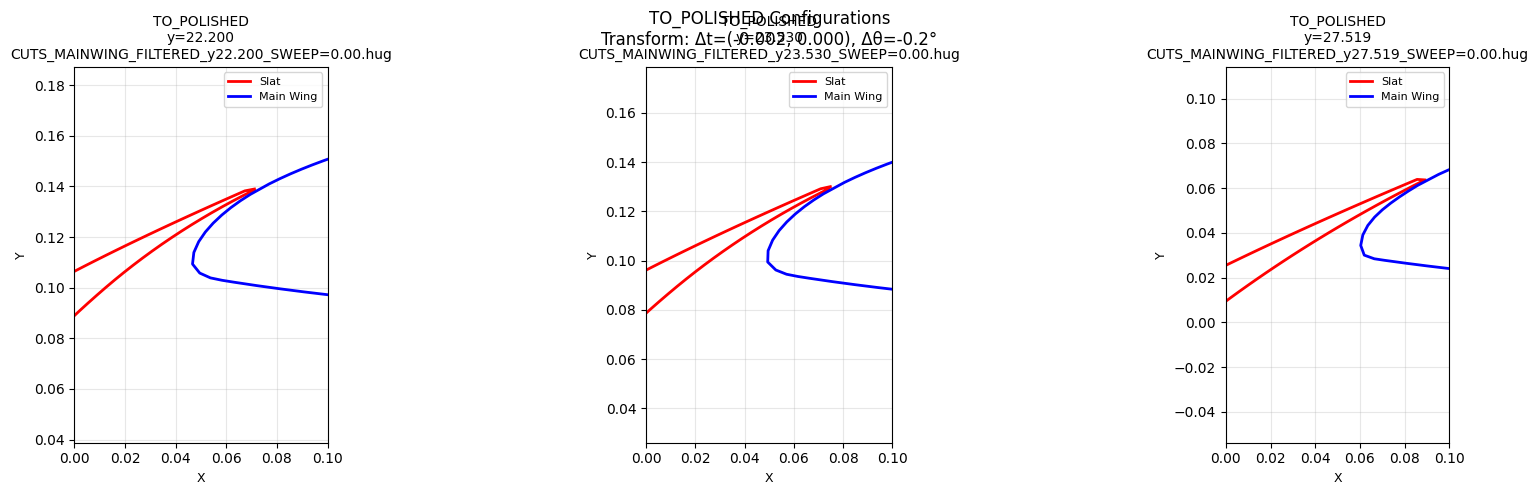


POLISHED TO GENERATION RESULTS
Target sections: 3
Sections found: 3
Successfully saved: 3
Failed: 0
Success rate: 100.0%

Output directory: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED
Files created:
  CUTS_MAINWING_FILTERED_y22.200_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y23.530_SWEEP=0.00.hug
  CUTS_MAINWING_FILTERED_y27.519_SWEEP=0.00.hug

Transformation applied:
  Translation: (-0.002, 0.000)
  Rotation: -0.2°

CLEANUP AND PROCESSING COMPLETE
Files removed (y > 20.871): 28
New files created: 3
Target sections processed: [22.2, 23.53, 27.519]

Processing complete!
Processed sections: [22.2, 23.53, 27.519]
Saved 3 new files to: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED


In [9]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import re
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass


@dataclass
class GeometryData:
    """Container for airfoil geometry data"""
    filename: str
    filepath: str
    y_location: float
    sweep_angle: Optional[float]
    elements: List[np.ndarray]
    config_type: str
    
    @property
    def num_elements(self) -> int:
        return len(self.elements)


class SlatSeparator:
    """Complete implementation of slat separation with specific section processing"""
    
    def __init__(self, data_directories: Dict[str, str]):
        self.data_directories = data_directories
        self.geometries = {}
        
    def extract_y_location(self, filename: str) -> Optional[float]:
        """Extract y location from filename"""
        match = re.search(r'y([\d.]+)', os.path.basename(filename))
        return float(match.group(1)) if match else None
    
    def extract_sweep_angle(self, filename: str) -> Optional[float]:
        """Extract sweep angle from filename"""
        match = re.search(r'SWEEP=([-]?[\d.]+)', os.path.basename(filename))
        if match:
            sweep_str = match.group(1).rstrip('.')
            try:
                return float(sweep_str)
            except ValueError:
                return None
        return None
    
    def _reorder_polygon(self, pts: np.ndarray) -> np.ndarray:
        """Reorder points to form a proper airfoil polygon"""
        if len(pts) < 3:
            return pts
            
        trailing_edge_idx = np.argmax(pts[:, 0])
        upper = pts[:trailing_edge_idx+1]
        lower = pts[trailing_edge_idx+1:][::-1]
        poly = np.vstack((upper, lower))
        
        if len(poly) > 1 and np.linalg.norm(poly[0] - poly[-1]) < 1e-6:
            poly = poly[:-1]
            
        return poly
    
    def load_hug_file(self, filepath: str) -> Tuple[List[np.ndarray], int]:
        """Load and parse .hug file"""
        try:
            with open(filepath, 'r') as f:
                lines = f.readlines()
            
            num_elements = int(lines[0].strip())
            elements = []
            line_idx = 1
            
            for elem_idx in range(num_elements):
                if line_idx >= len(lines):
                    break
                    
                num_points = int(lines[line_idx].strip())
                line_idx += 1
                
                element_coords = []
                for i in range(num_points):
                    if line_idx >= len(lines):
                        break
                        
                    line = lines[line_idx].strip()
                    if line and not line.startswith('#'):
                        coords = [float(x) for x in line.split()]
                        if len(coords) >= 2:
                            element_coords.append([coords[0], coords[1]])
                    line_idx += 1
                
                if element_coords:
                    element_coords = np.array(element_coords)
                    elements.append(self._reorder_polygon(element_coords))
            
            return elements, num_elements
            
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return [], 0
    
    def load_all_geometries(self):
        """Load all geometries from directories"""
        for config_type, data_directory in self.data_directories.items():
            print(f"Loading {config_type} geometries from {data_directory}")
            
            pattern = os.path.join(data_directory, "**/*.hug")
            geometry_files = glob.glob(pattern, recursive=True)
            
            geometries = []
            for filepath in geometry_files:
                y_location = self.extract_y_location(filepath)
                sweep_angle = self.extract_sweep_angle(filepath)
                elements, num_elements = self.load_hug_file(filepath)
                
                if elements and y_location is not None:
                    geometry_data = GeometryData(
                        filename=os.path.basename(filepath),
                        filepath=filepath,
                        y_location=y_location,
                        sweep_angle=sweep_angle,
                        elements=elements,
                        config_type=config_type
                    )
                    geometries.append(geometry_data)
            
            self.geometries[config_type] = geometries
            print(f"Loaded {len(geometries)} {config_type} geometries")
    
    def clean_existing_high_y_files(self, output_directory: str, threshold: float = 20.871):
        """
        Remove all existing files in output directory with y-locations > threshold
        """
        print(f"\n{'='*60}")
        print(f"CLEANING EXISTING FILES WITH y > {threshold}")
        print(f"{'='*60}")
        print(f"Searching in: {output_directory}")
        
        if not os.path.exists(output_directory):
            print("Output directory doesn't exist - nothing to clean")
            return
        
        # Find all .hug files in output directory
        pattern = os.path.join(output_directory, "*.hug")
        existing_files = glob.glob(pattern)
        
        files_to_remove = []
        
        # Check each file's y-location
        for filepath in existing_files:
            filename = os.path.basename(filepath)
            y_location = self.extract_y_location(filename)
            
            if y_location is not None and y_location > threshold:
                files_to_remove.append(filepath)
        
        print(f"Found {len(files_to_remove)} files to remove with y > {threshold}:")
        
        # Remove the files
        removed_count = 0
        for filepath in files_to_remove:
            try:
                filename = os.path.basename(filepath)
                y_location = self.extract_y_location(filename)
                print(f"  Removing: {filename} (y={y_location:.3f})")
                os.remove(filepath)
                removed_count += 1
            except Exception as e:
                print(f"  Error removing {filepath}: {e}")
        
        print(f"\nCleanup complete: Removed {removed_count}/{len(files_to_remove)} files")
        return removed_count
    
    def find_slat_trailing_edge_by_closure(self, sealed_element: np.ndarray,
                                          min_separation: int = 10,
                                          distance_threshold: float = 0.002) -> Tuple[int, int]:
        """
        Find slat trailing edge by detecting where two points are very close in distance
        but separated by many indices (indicating slat closure)
        
        Returns: (start_index, end_index) of slat region
        """
        print(f"    Looking for slat closure with min_separation={min_separation}, distance_threshold={distance_threshold:.4f}")
        
        n_points = len(sealed_element)
        
        # Find pairs of points that are close in distance but far in index
        closure_pairs = []
        
        for i in range(n_points):
            for j in range(i + min_separation, n_points):
                point_i = sealed_element[i]
                point_j = sealed_element[j]
                distance = np.linalg.norm(point_i - point_j)
                
                if distance < distance_threshold:
                    closure_pairs.append((i, j, distance))
                    print(f"    Found closure candidate: indices {i}-{j}, distance={distance:.4f}")
        
        if not closure_pairs:
            print(f"    No closure points found")
            return None, None
        
        # Choose the best closure pair (shortest distance)
        best_pair = min(closure_pairs, key=lambda x: x[2])
        start_idx, end_idx, distance = best_pair
        
        print(f"    Best closure: indices {start_idx} to {end_idx}, distance={distance:.4f}")
        print(f"    Start point: X={sealed_element[start_idx][0]:.4f}, Y={sealed_element[start_idx][1]:.4f}")
        print(f"    End point: X={sealed_element[end_idx][0]:.4f}, Y={sealed_element[end_idx][1]:.4f}")
        print(f"    Slat region contains {end_idx - start_idx + 1} points")
        
        return start_idx, end_idx
    
    def separate_slat_from_sealed_element(self, sealed_element: np.ndarray,
                                        min_separation: int = 10,
                                        distance_threshold: float = 0.002) -> Tuple[np.ndarray, np.ndarray]:
        """
        Separate slat from sealed element by finding closure points
        Returns: (slat_points, main_wing_points)
        """
        start_idx, end_idx = self.find_slat_trailing_edge_by_closure(
            sealed_element, min_separation, distance_threshold)
        
        if start_idx is None or end_idx is None:
            print("    Could not find slat closure points")
            return None, None
        
        # Extract slat points (from start to end, inclusive)
        slat_points = sealed_element[start_idx:end_idx+1]
        
        # Extract main wing points (everything except the slat)
        if start_idx > 0 and end_idx < len(sealed_element) - 1:
            # Slat is in the middle - connect the remaining parts
            main_wing_points = np.vstack([
                sealed_element[:start_idx],
                sealed_element[end_idx+1:]
            ])
        elif start_idx == 0:
            # Slat starts from beginning
            main_wing_points = sealed_element[end_idx+1:]
        elif end_idx == len(sealed_element) - 1:
            # Slat goes to the end
            main_wing_points = sealed_element[:start_idx]
        else:
            print("    Error in slat separation logic")
            return None, None
        
        print(f"    Separation successful:")
        print(f"      Slat: {len(slat_points)} points")
        print(f"      Main wing: {len(main_wing_points)} points")
        
        return slat_points, main_wing_points
    
    def apply_transformation(self, points: np.ndarray, translation: np.ndarray, 
                           rotation: float) -> np.ndarray:
        """Apply translation and rotation to points"""
        # Get centroid for rotation center
        centroid = np.mean(points, axis=0)
        
        # Translate first
        translated = points + translation
        
        # Rotate around centroid
        centered = translated - centroid
        cos_theta = np.cos(rotation)
        sin_theta = np.sin(rotation)
        rotation_matrix = np.array([[cos_theta, -sin_theta],
                                   [sin_theta, cos_theta]])
        
        rotated = np.dot(centered, rotation_matrix.T)
        return rotated + centroid
    
    def save_hug_file(self, geometry_data: GeometryData, output_directory: str) -> str:
        """
        Save geometry data to .hug file with consistent format
        Returns the output filepath
        """
        os.makedirs(output_directory, exist_ok=True)
        
        # Create output filename - keep original name but change extension if needed
        output_filename = geometry_data.filename
        if not output_filename.endswith('.hug'):
            output_filename = output_filename.replace('.hug', '') + '.hug'
        
        output_path = os.path.join(output_directory, output_filename)
        
        try:
            with open(output_path, 'w') as f:
                # Write number of elements
                f.write(f"{len(geometry_data.elements)}\n")
                
                # Write each element
                for element in geometry_data.elements:
                    f.write(f"{len(element)}\n")
                    for point in element:
                        f.write(f"{point[0]:.8f} {point[1]:.8f}\n")
            
            print(f"    Saved: {output_path}")
            return output_path
            
        except Exception as e:
            print(f"    Error saving {output_path}: {e}")
            return None
    
    def create_polished_geometry(self, original_geom: GeometryData, 
                               separated_slat: np.ndarray, 
                               main_wing: np.ndarray) -> GeometryData:
        """
        Create new GeometryData with separated slat and main wing
        """
        polished_elements = []
        
        # Add separated slat as first element
        polished_elements.append(separated_slat)
        
        # Add main wing as second element  
        polished_elements.append(main_wing)
        
        # Add remaining elements from original (flap, etc.)
        if len(original_geom.elements) > 1:
            for i in range(1, len(original_geom.elements)):
                polished_elements.append(original_geom.elements[i])
        
        # Create new GeometryData
        polished_geom = GeometryData(
            filename=original_geom.filename,
            filepath="",  # Will be set when saved
            y_location=original_geom.y_location,
            sweep_angle=original_geom.sweep_angle,
            elements=polished_elements,
            config_type="TO_POLISHED"
        )
        
        return polished_geom
    
    def visualize_saved_configurations(self, output_directory: str, saved_files: List[str],
                                     slat_translation: np.ndarray, slat_rotation: float,
                                     x_limits: Tuple[float, float] = (0.0, 0.1)):
        """
        Visualize the saved polished configurations
        """
        print(f"\nGenerating visualization of saved configurations...")
        
        # Load the saved files for visualization
        polished_geometries = []
        for filepath in saved_files:
            filename = os.path.basename(filepath)
            y_location = self.extract_y_location(filename)
            elements, num_elements = self.load_hug_file(filepath)
            
            if elements and y_location is not None:
                geom_data = GeometryData(
                    filename=filename,
                    filepath=filepath,
                    y_location=y_location,
                    sweep_angle=None,
                    elements=elements,
                    config_type="TO_POLISHED"
                )
                polished_geometries.append(geom_data)
        
        if not polished_geometries:
            print("No polished geometries to visualize")
            return
        
        # Sort by y-location
        polished_geometries = sorted(polished_geometries, key=lambda g: g.y_location)
        
        # Create visualization
        n_cases = len(polished_geometries)
        n_cols = 3
        n_rows = (n_cases + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        
        # Handle single subplot cases
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        axes_flat = axes.flatten() if n_cases > 1 else [axes]
        colors = ['red', 'blue', 'green']
        element_names = ['Slat', 'Main Wing', 'Flap']
        
        for plot_idx, geom in enumerate(polished_geometries):
            if plot_idx >= len(axes_flat):
                break
                
            ax = axes_flat[plot_idx]
            
            # Plot each element
            for elem_idx, element in enumerate(geom.elements):
                color = colors[elem_idx % len(colors)]
                name = element_names[elem_idx] if elem_idx < len(element_names) else f'Element {elem_idx+1}'
                
                ax.plot(element[:, 0], element[:, 1], 
                       color=color, linewidth=2, label=name)
            
            ax.set_title(f'TO_POLISHED\ny={geom.y_location:.3f}\n{geom.filename}', fontsize=10)
            ax.set_xlabel('X', fontsize=9)
            ax.set_ylabel('Y', fontsize=9)
            ax.legend(fontsize=8)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(x_limits)
        
        # Hide unused subplots
        for i in range(n_cases, len(axes_flat)):
            axes_flat[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle(f'TO_POLISHED Configurations\nTransform: Δt=({slat_translation[0]:.3f}, {slat_translation[1]:.3f}), Δθ={np.degrees(slat_rotation):.1f}°', 
                     fontsize=12, y=0.98)
        plt.show()
    
    def process_and_save_sealed_to_configurations(self, 
                                                 output_directory: str = "TO_POLISHED",
                                                 slat_translation: np.ndarray = np.array([-0.002, 0]),
                                                 slat_rotation: float = np.radians(-0.2),
                                                 min_separation: int = 50,
                                                 distance_threshold: float = 0.002,
                                                 target_y_locations: List[float] = None,
                                                 y_tolerance: float = 0.002,
                                                 x_limits: Tuple[float, float] = (0.0, 0.1)):
        """
        Process TO configurations and save polished versions to new directory
        """
        if target_y_locations is None:
            target_y_locations = [22.200, 23.530, 27.519]
            
        if 'TO' not in self.geometries:
            print("No TO geometries loaded")
            return []
        
        # Find TO configurations with 1 element at target y_locations
        sealed_cases = []
        for to_geom in self.geometries['TO']:
            if to_geom.num_elements == 1:
                # Check if this y_location matches any target
                for target_y in target_y_locations:
                    if abs(to_geom.y_location - target_y) <= y_tolerance:
                        sealed_cases.append(to_geom)
                        break
        
        if not sealed_cases:
            print(f"No sealed TO configurations found at target y_locations: {target_y_locations}")
            return []
        
        print(f"Found {len(sealed_cases)} sealed TO configurations at target y_locations")
        print(f"Target y_locations: {target_y_locations}")
        print(f"Output directory: {output_directory}")
        print(f"Slat transformation:")
        print(f"  Translation: ({slat_translation[0]:.3f}, {slat_translation[1]:.3f})")
        print(f"  Rotation: {np.degrees(slat_rotation):.1f}°")
        
        # Sort by y-location
        sealed_cases = sorted(sealed_cases, key=lambda g: g.y_location)
        
        # Process and save each case
        successful_saves = 0
        saved_files = []
        failed_cases = []
        
        for to_geom in sealed_cases:
            print(f"\n  Processing y={to_geom.y_location:.3f}: {to_geom.filename}")
            
            # Separate slat from sealed element
            sealed_element = to_geom.elements[0]
            slat_points, main_wing_points = self.separate_slat_from_sealed_element(
                sealed_element, min_separation, distance_threshold)
            
            if slat_points is not None and main_wing_points is not None:
                # Apply transformation to slat
                transformed_slat = self.apply_transformation(slat_points, slat_translation, slat_rotation)
                
                # Create polished geometry
                polished_geom = self.create_polished_geometry(to_geom, transformed_slat, main_wing_points)
                
                # Save to file
                output_path = self.save_hug_file(polished_geom, output_directory)
                
                if output_path is not None:
                    successful_saves += 1
                    saved_files.append(output_path)
                    print(f"    SUCCESS: Created {len(polished_geom.elements)}-element configuration")
                else:
                    failed_cases.append(to_geom.y_location)
                    print(f"    FAILED: Could not save file")
            else:
                failed_cases.append(to_geom.y_location)
                print(f"    FAILED: Could not separate slat")
        
        # Create visualization of saved configurations
        if saved_files:
            self.visualize_saved_configurations(output_directory, saved_files, slat_translation, slat_rotation, x_limits)
        
        # Summary
        print(f"\n{'='*60}")
        print("POLISHED TO GENERATION RESULTS")
        print(f"{'='*60}")
        print(f"Target sections: {len(target_y_locations)}")
        print(f"Sections found: {len(sealed_cases)}")
        print(f"Successfully saved: {successful_saves}")
        print(f"Failed: {len(failed_cases)}")
        if len(sealed_cases) > 0:
            print(f"Success rate: {100*successful_saves/len(sealed_cases):.1f}%")
        
        print(f"\nOutput directory: {output_directory}")
        print(f"Files created:")
        for filepath in saved_files:
            filename = os.path.basename(filepath)
            print(f"  {filename}")
        
        if failed_cases:
            print(f"\nFailed sections: {failed_cases}")
        
        print(f"\nTransformation applied:")
        print(f"  Translation: ({slat_translation[0]:.3f}, {slat_translation[1]:.3f})")
        print(f"  Rotation: {np.degrees(slat_rotation):.1f}°")
        
        return saved_files
    
    def process_specific_sections_with_cleanup(self, 
                                             target_sections: List[float] = [22.200, 23.530, 27.519],
                                             cleanup_threshold: float = 20.871,
                                             output_directory: str = None,
                                             slat_translation: np.ndarray = np.array([-0.002, 0]),
                                             slat_rotation: float = np.radians(-0.2),
                                             min_separation: int = 50,
                                             distance_threshold: float = 0.002,
                                             y_tolerance: float = 0.002,
                                             x_limits: Tuple[float, float] = (0.0, 0.1)):
        """
        Clean existing high y-location files and process specific target sections
        """
        if output_directory is None:
            output_directory = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED"
        
        print(f"="*60)
        print(f"PROCESSING SPECIFIC SECTIONS WITH CLEANUP")
        print(f"="*60)
        print(f"Target sections: {target_sections}")
        print(f"Cleanup threshold: y > {cleanup_threshold}")
        print(f"Output directory: {output_directory}")
        
        # Step 1: Clean existing files with y > cleanup_threshold
        removed_count = self.clean_existing_high_y_files(output_directory, cleanup_threshold)
        
        # Step 2: Process and save specific target sections
        print(f"\n{'='*60}")
        print(f"PROCESSING TARGET SECTIONS")
        print(f"{'='*60}")
        
        saved_files = self.process_and_save_sealed_to_configurations(
            output_directory=output_directory,
            slat_translation=slat_translation,
            slat_rotation=slat_rotation,
            min_separation=min_separation,
            distance_threshold=distance_threshold,
            target_y_locations=target_sections,
            y_tolerance=y_tolerance,
            x_limits=x_limits
        )
        
        # Final summary
        print(f"\n{'='*60}")
        print(f"CLEANUP AND PROCESSING COMPLETE")
        print(f"{'='*60}")
        print(f"Files removed (y > {cleanup_threshold}): {removed_count}")
        print(f"New files created: {len(saved_files)}")
        print(f"Target sections processed: {target_sections}")
        
        return saved_files


def process_specific_sections_standalone():
    """
    Standalone function to clean and process specific sections: 22.200, 23.530, 27.519
    """
    # Configuration
    data_directories = {
        'LDG': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_LDG",
        'TO': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO",
        'CLEAN': "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_CLEAN"
    }
    
    output_directory = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED"
    
    # Specific sections to process
    target_sections = [22.200, 23.530, 27.519]
    
    # Initialize separator
    separator = SlatSeparator(data_directories)
    
    # Load geometries
    print("Loading geometries...")
    separator.load_all_geometries()
    
    # Process specific sections with cleanup
    saved_files = separator.process_specific_sections_with_cleanup(
        target_sections=target_sections,
        cleanup_threshold=20.871,
        output_directory=output_directory,
        slat_translation=np.array([-0.002, 0]),
        slat_rotation=np.radians(-0.2),
        min_separation=50,
        distance_threshold=0.002,
        y_tolerance=0.002
    )
    
    print(f"\nProcessing complete!")
    print(f"Processed sections: {target_sections}")
    print(f"Saved {len(saved_files)} new files to: {output_directory}")
    
    return saved_files


def main():
    """Main function for specific section processing"""
    
    print("="*60)
    print("SPECIFIC SECTIONS PROCESSOR")
    print("="*60)
    print("This will:")
    print("1. Remove all existing files with y > 20.871 from TO_POLISHED folder")
    print("2. Process and save only sections: 22.200, 23.530, 27.519")
    print("="*60)
    
    # Execute the specific sections processing
    saved_files = process_specific_sections_standalone()
    
    return saved_files


if __name__ == "__main__":
    # Run this to clean and process specific sections only
    saved_files = main()

ENHANCED PLOTTING FOR TO_POLISHED GEOMETRIES
Available options:
1. Individual detailed plots with element zoom
2. Comparison grid plot

1. Creating individual detailed plots with element zoom...
   Each geometry gets its own plot with zoomed element views
Loading geometries from: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED
Found 31 files
Will plot 31 geometries individually
Y-locations to be plotted:
  y=3.321: CUTS_MAINWING_FILTERED_y3.321_SWEEP=0.00.hug
  y=3.587: CUTS_MAINWING_FILTERED_y3.587_SWEEP=0.00.hug
  y=3.853: CUTS_MAINWING_FILTERED_y3.853_SWEEP=0.00.hug
  y=4.119: CUTS_MAINWING_FILTERED_y4.119_SWEEP=0.00.hug
  y=4.385: CUTS_MAINWING_FILTERED_y4.385_SWEEP=0.00.hug
  y=4.650: CUTS_MAINWING_FILTERED_y4.650_SWEEP=0.00.hug
  y=4.916: CUTS_MAINWING_FILTERED_y4.916_SWEEP=0.00.hug
  y=5.182: CUTS_MAINWING_FILTERED_y5.182_SWEEP=0.00.hug
  y=5.448: CUTS_MAINWING_FILTERED_y5.448_SWEEP=0.00.hug
  y=5.714: CUTS_MAINWING_FILTERED_

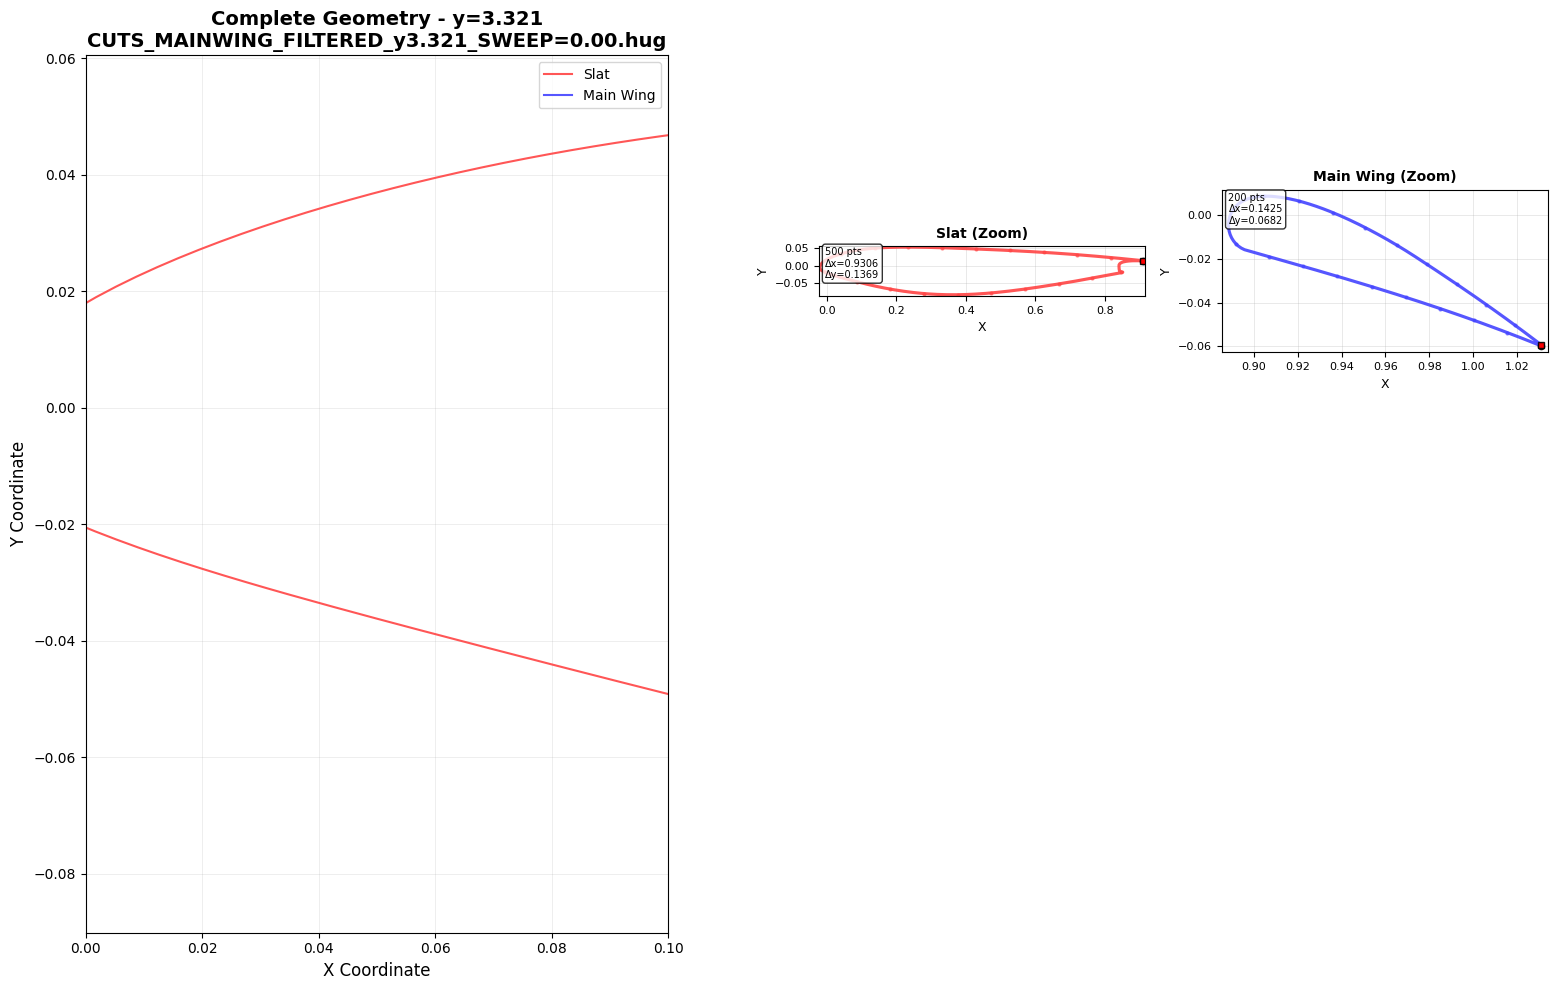


Geometry Details - y=3.321:
  File: CUTS_MAINWING_FILTERED_y3.321_SWEEP=0.00.hug
  Total elements: 2
  Slat: 500 points, X-range=0.9306, Y-range=0.1369
  Main Wing: 200 points, X-range=0.1425, Y-range=0.0682

PLOTTING 2/31: y=3.587


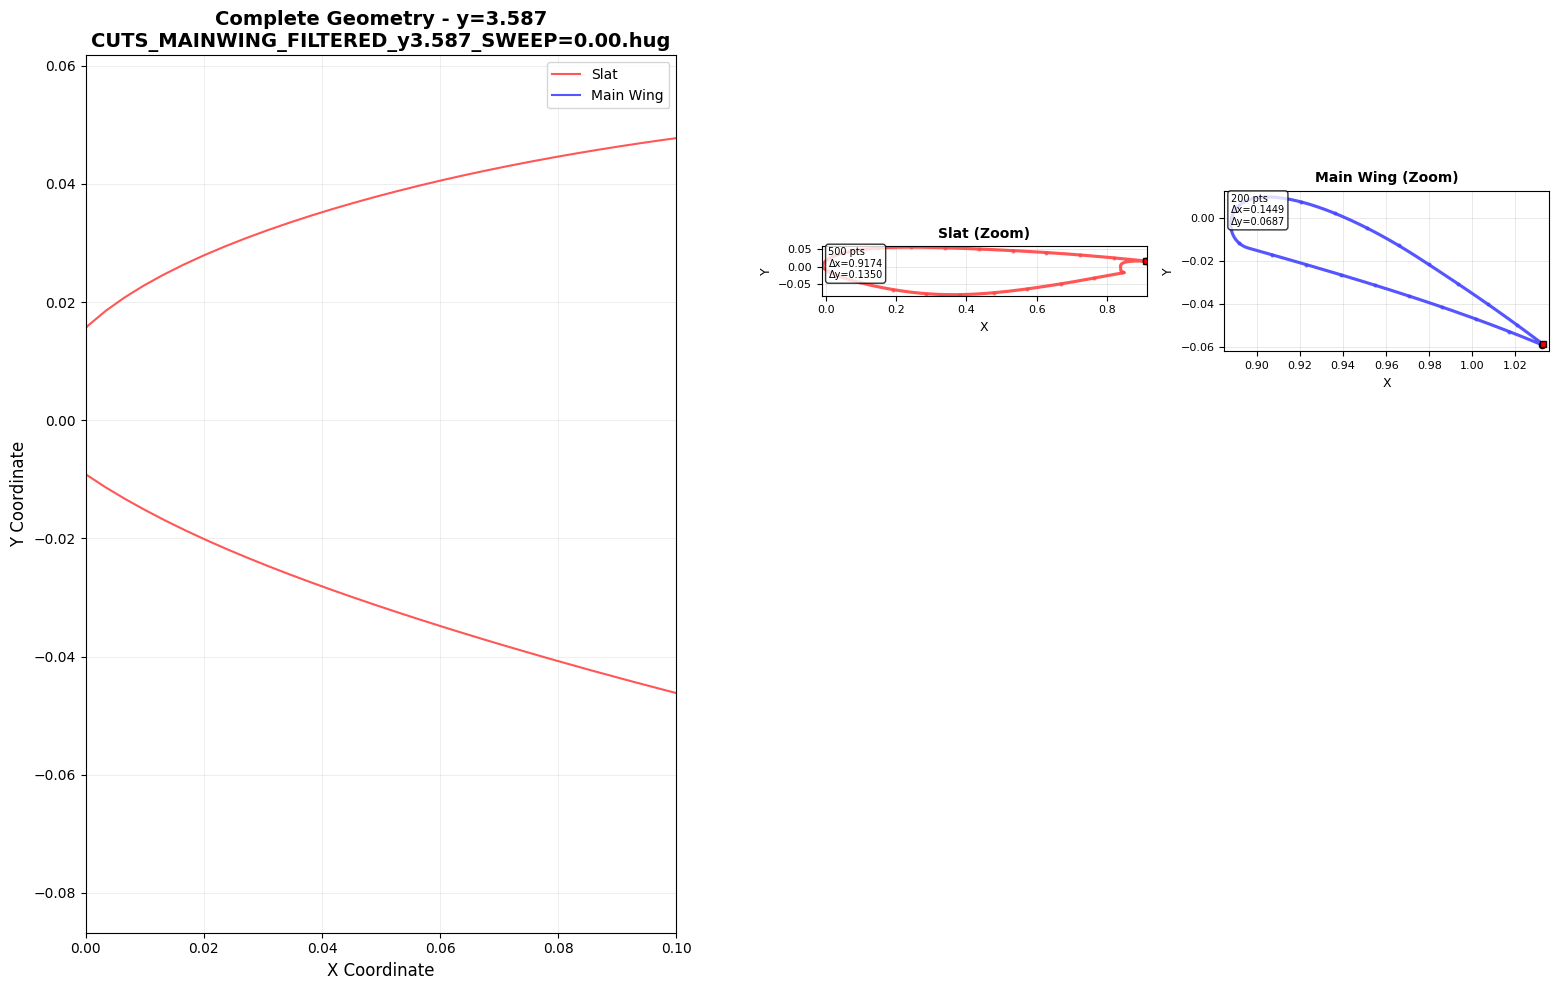


Geometry Details - y=3.587:
  File: CUTS_MAINWING_FILTERED_y3.587_SWEEP=0.00.hug
  Total elements: 2
  Slat: 500 points, X-range=0.9174, Y-range=0.1350
  Main Wing: 200 points, X-range=0.1449, Y-range=0.0687

PLOTTING 3/31: y=3.853


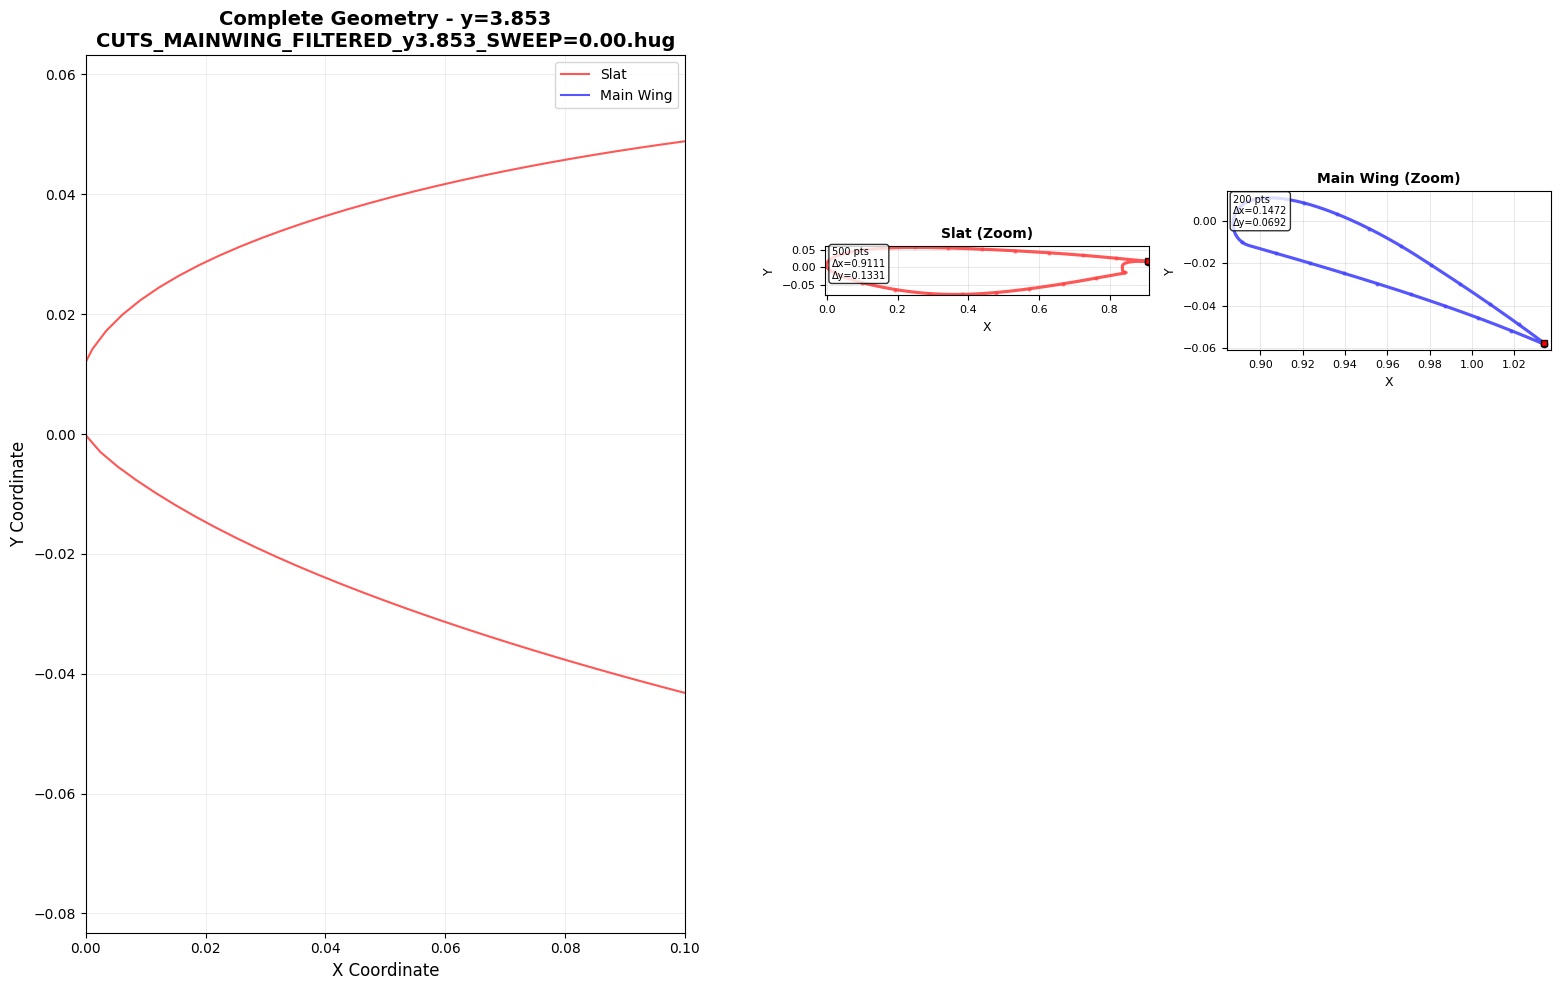


Geometry Details - y=3.853:
  File: CUTS_MAINWING_FILTERED_y3.853_SWEEP=0.00.hug
  Total elements: 2
  Slat: 500 points, X-range=0.9111, Y-range=0.1331
  Main Wing: 200 points, X-range=0.1472, Y-range=0.0692

PLOTTING 4/31: y=4.119


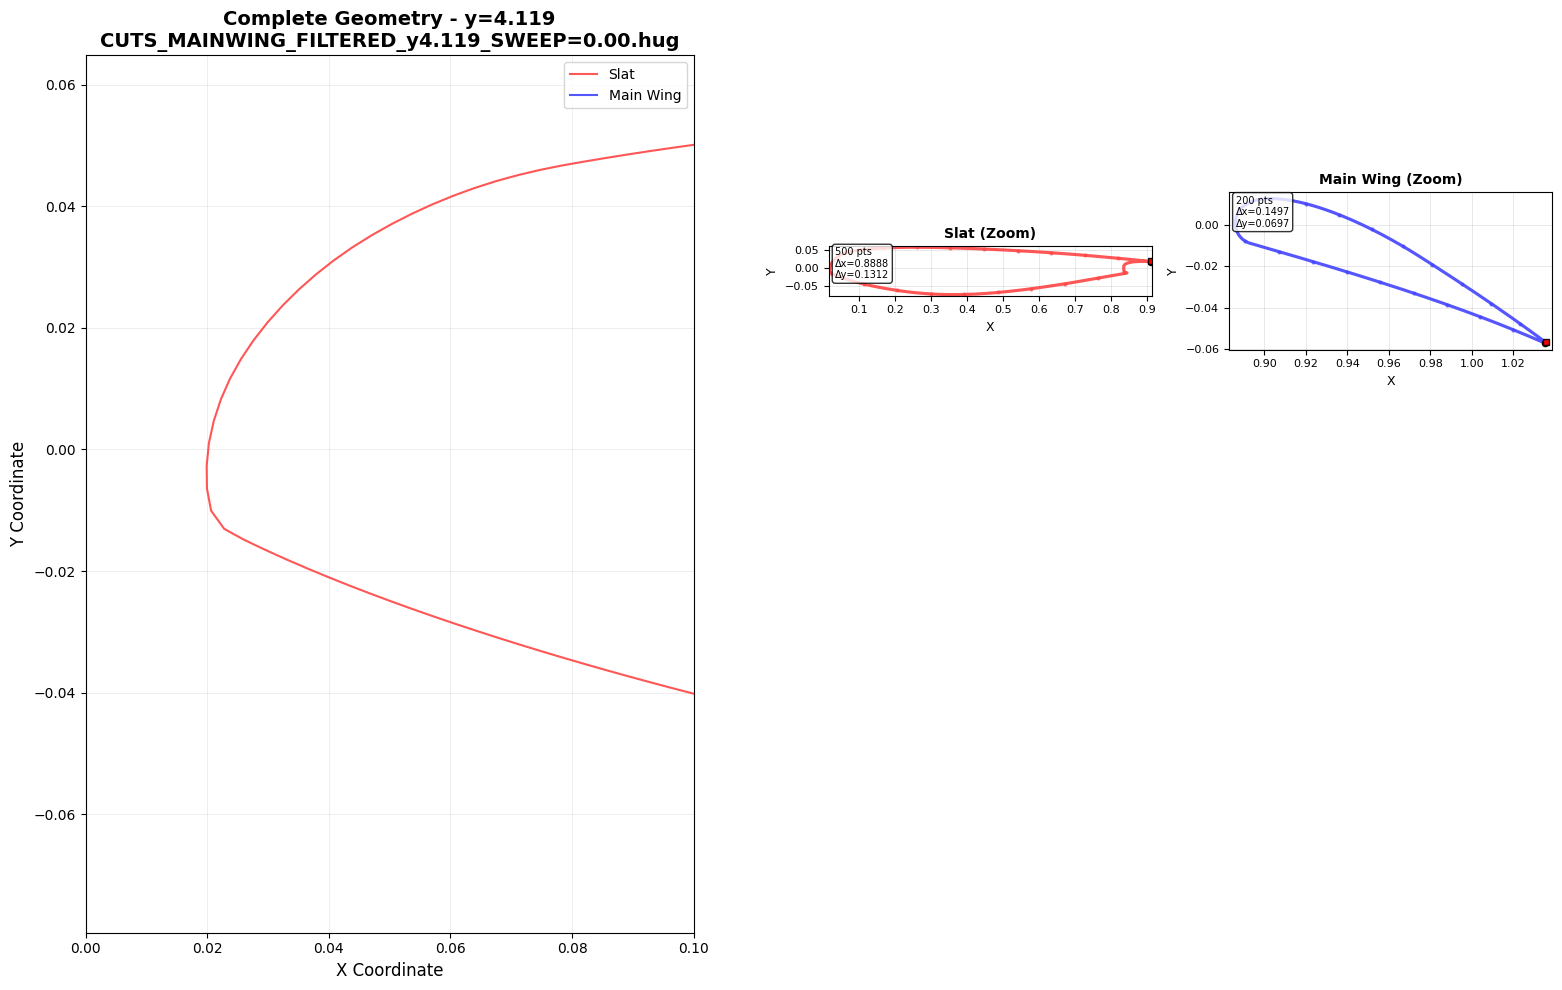


Geometry Details - y=4.119:
  File: CUTS_MAINWING_FILTERED_y4.119_SWEEP=0.00.hug
  Total elements: 2
  Slat: 500 points, X-range=0.8888, Y-range=0.1312
  Main Wing: 200 points, X-range=0.1497, Y-range=0.0697

PLOTTING 5/31: y=4.385


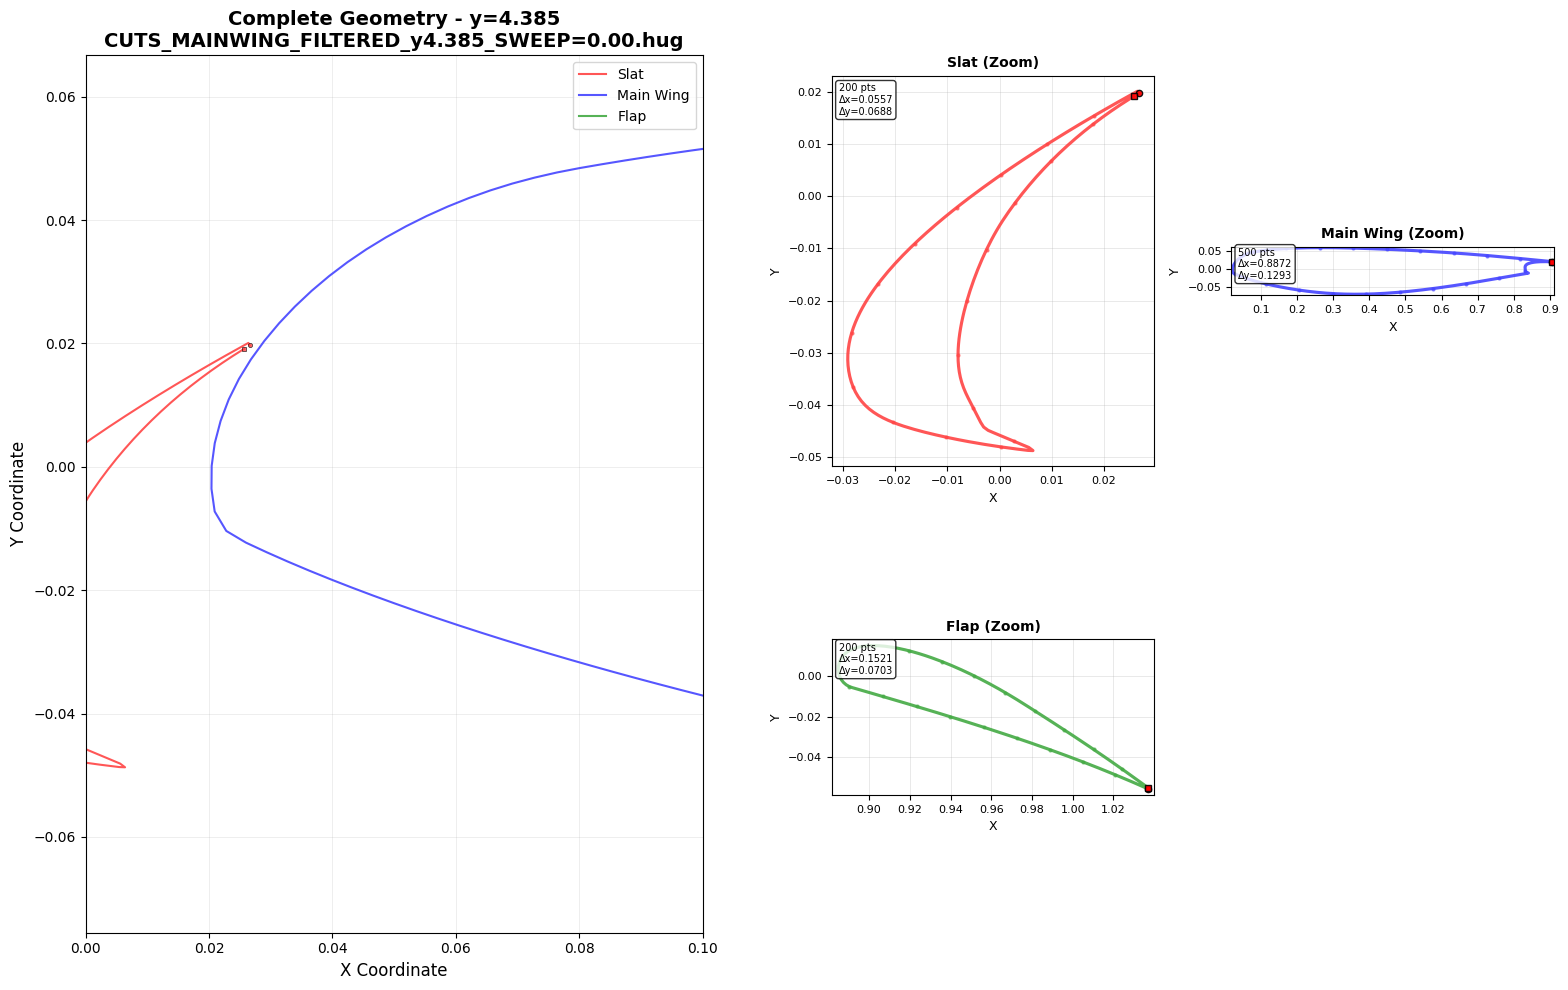


Geometry Details - y=4.385:
  File: CUTS_MAINWING_FILTERED_y4.385_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0557, Y-range=0.0688
  Main Wing: 500 points, X-range=0.8872, Y-range=0.1293
  Flap: 200 points, X-range=0.1521, Y-range=0.0703

PLOTTING 6/31: y=4.650


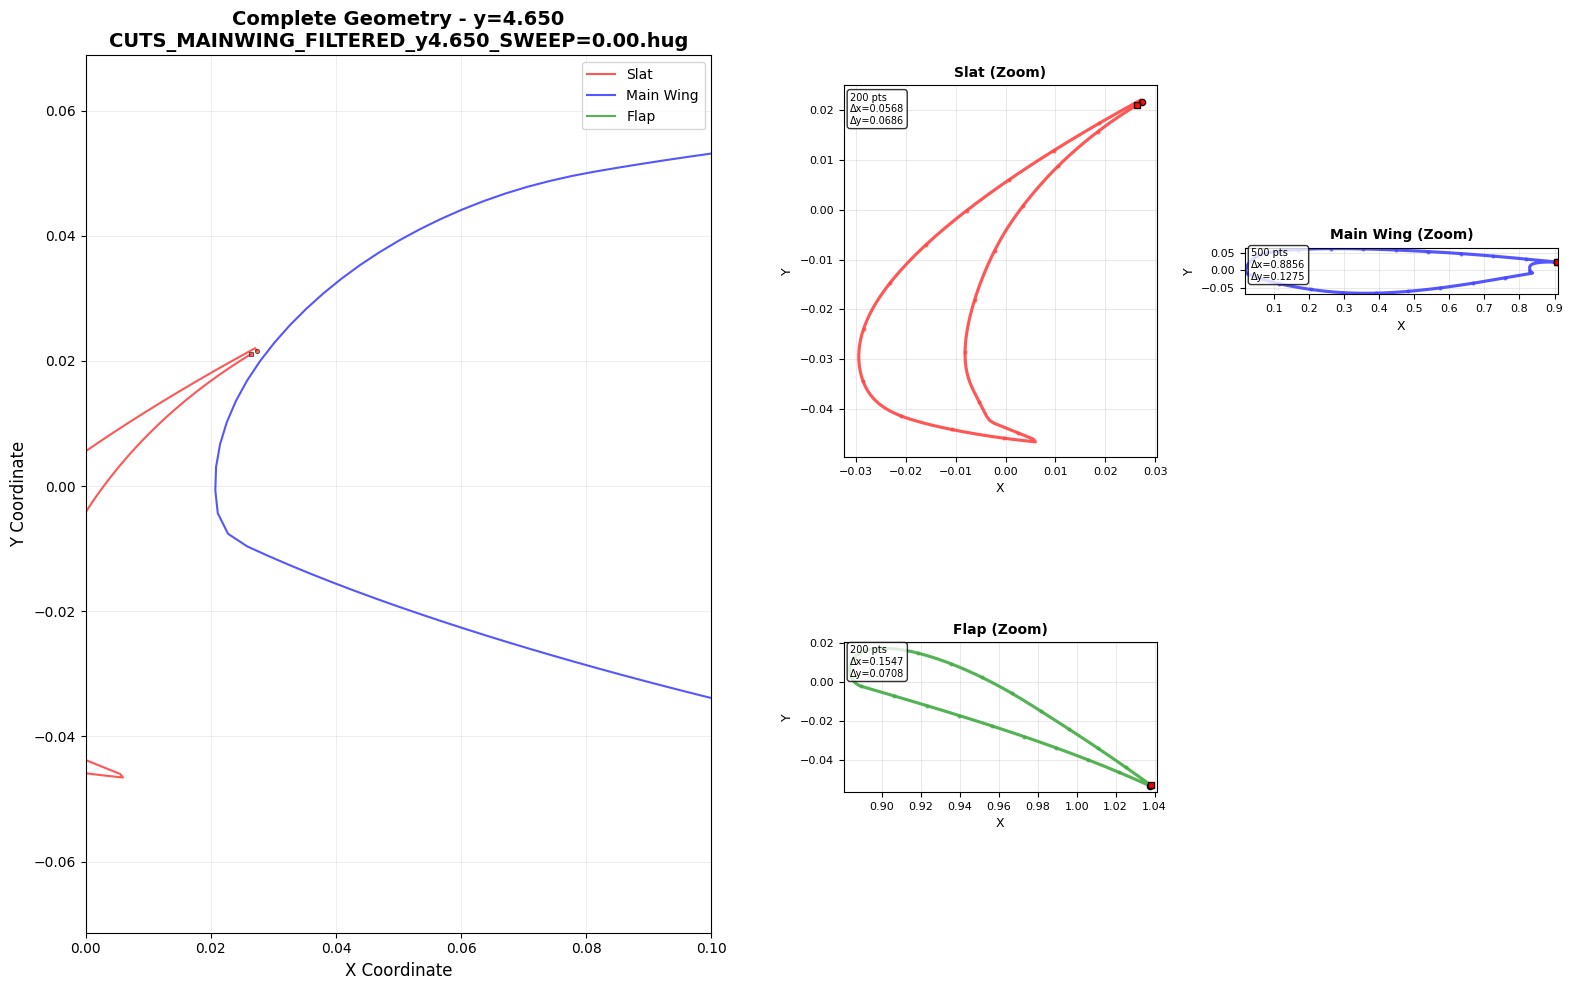


Geometry Details - y=4.650:
  File: CUTS_MAINWING_FILTERED_y4.650_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0568, Y-range=0.0686
  Main Wing: 500 points, X-range=0.8856, Y-range=0.1275
  Flap: 200 points, X-range=0.1547, Y-range=0.0708

PLOTTING 7/31: y=4.916


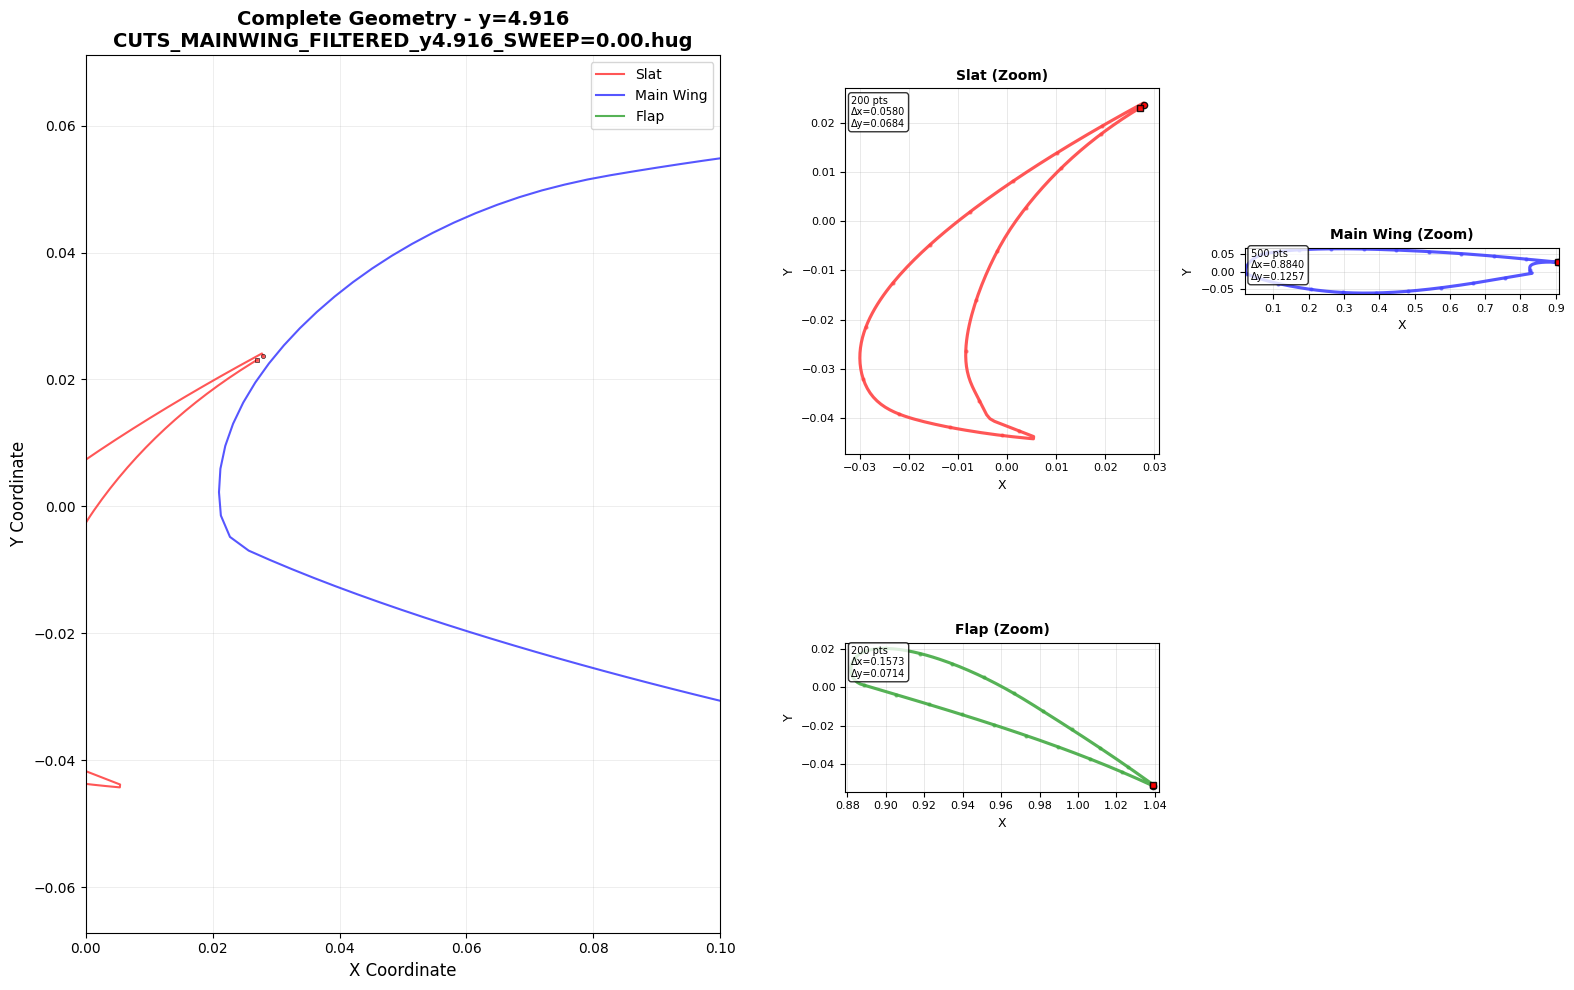


Geometry Details - y=4.916:
  File: CUTS_MAINWING_FILTERED_y4.916_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0580, Y-range=0.0684
  Main Wing: 500 points, X-range=0.8840, Y-range=0.1257
  Flap: 200 points, X-range=0.1573, Y-range=0.0714

PLOTTING 8/31: y=5.182


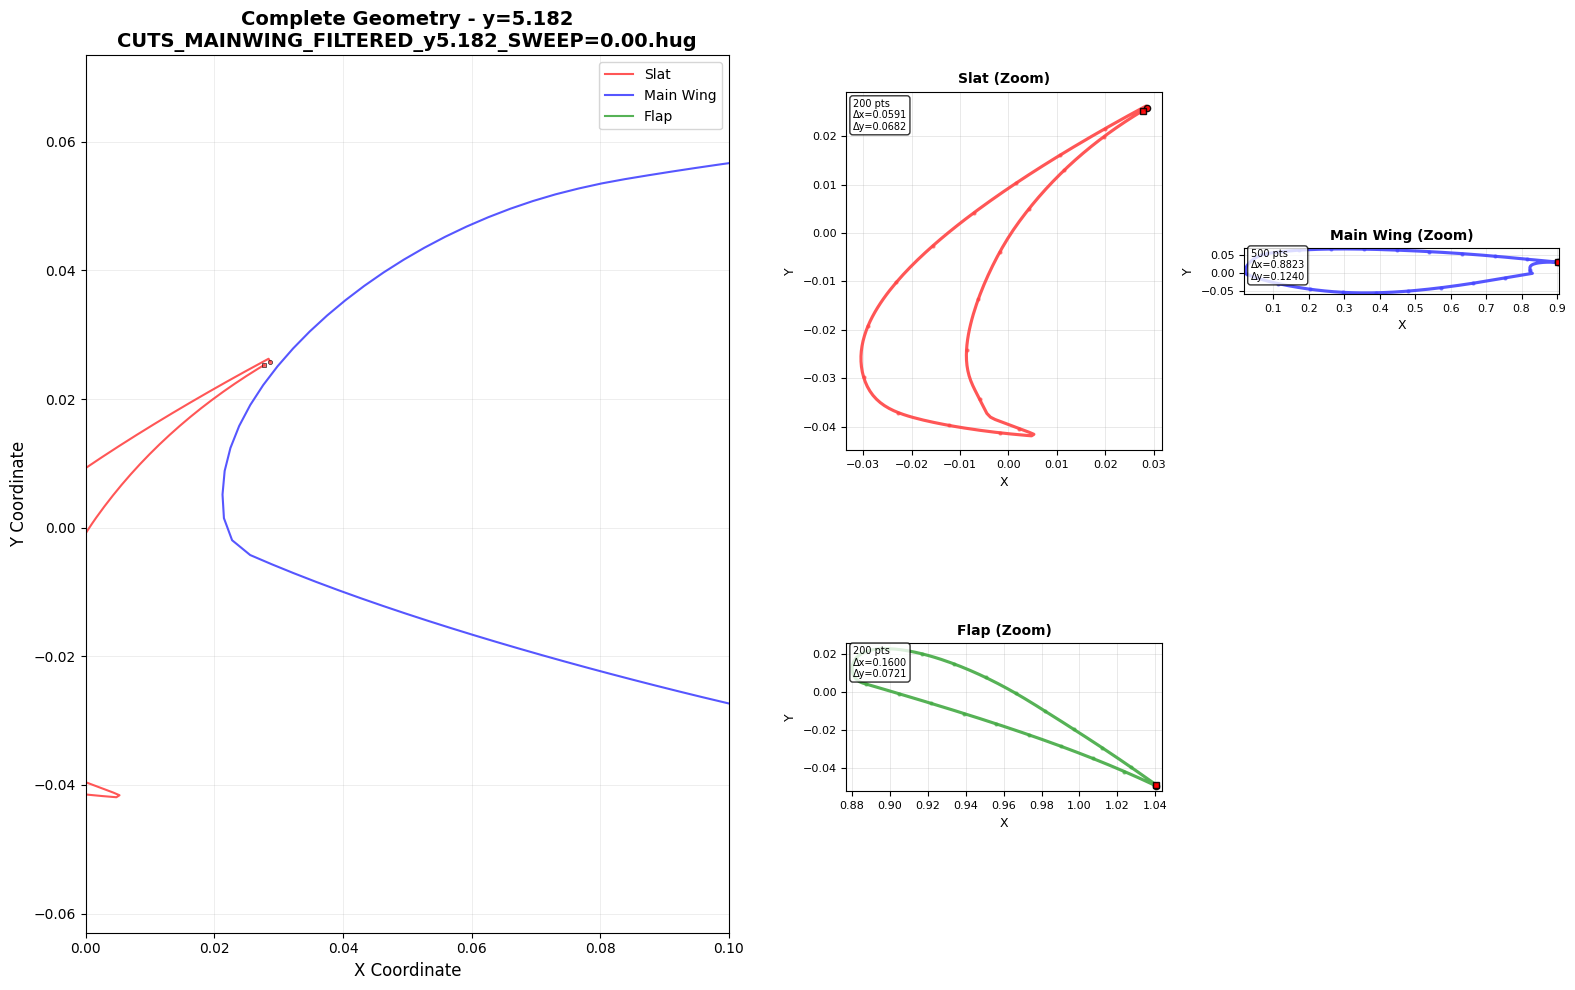


Geometry Details - y=5.182:
  File: CUTS_MAINWING_FILTERED_y5.182_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0591, Y-range=0.0682
  Main Wing: 500 points, X-range=0.8823, Y-range=0.1240
  Flap: 200 points, X-range=0.1600, Y-range=0.0721

PLOTTING 9/31: y=5.448


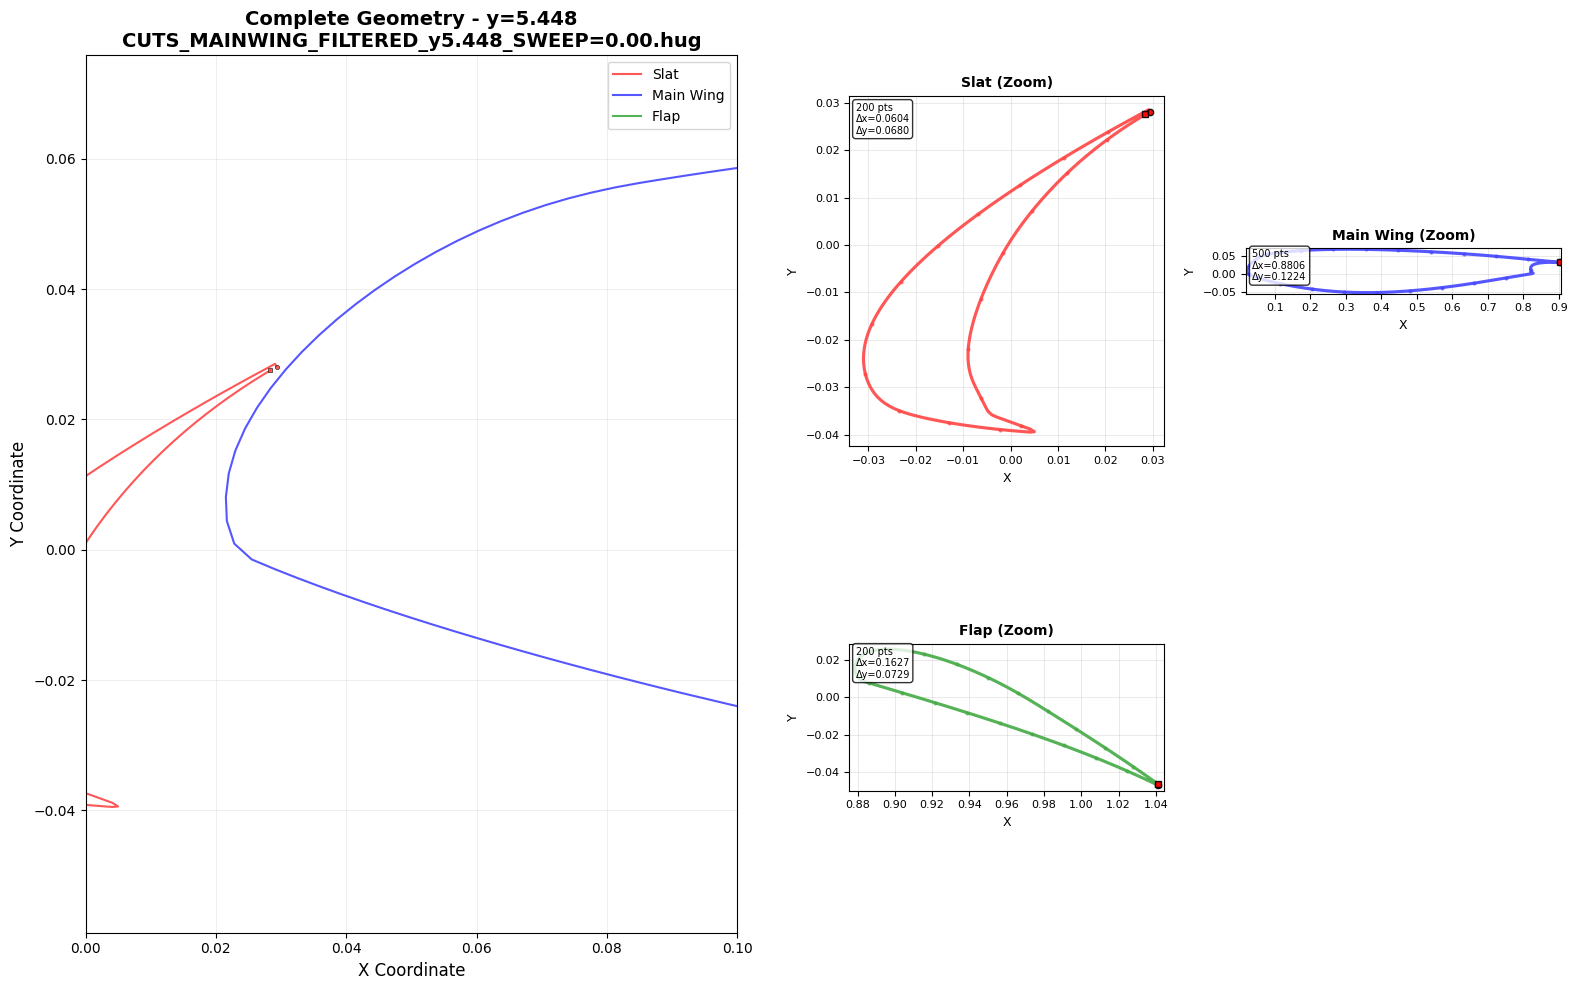


Geometry Details - y=5.448:
  File: CUTS_MAINWING_FILTERED_y5.448_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0604, Y-range=0.0680
  Main Wing: 500 points, X-range=0.8806, Y-range=0.1224
  Flap: 200 points, X-range=0.1627, Y-range=0.0729

PLOTTING 10/31: y=5.714


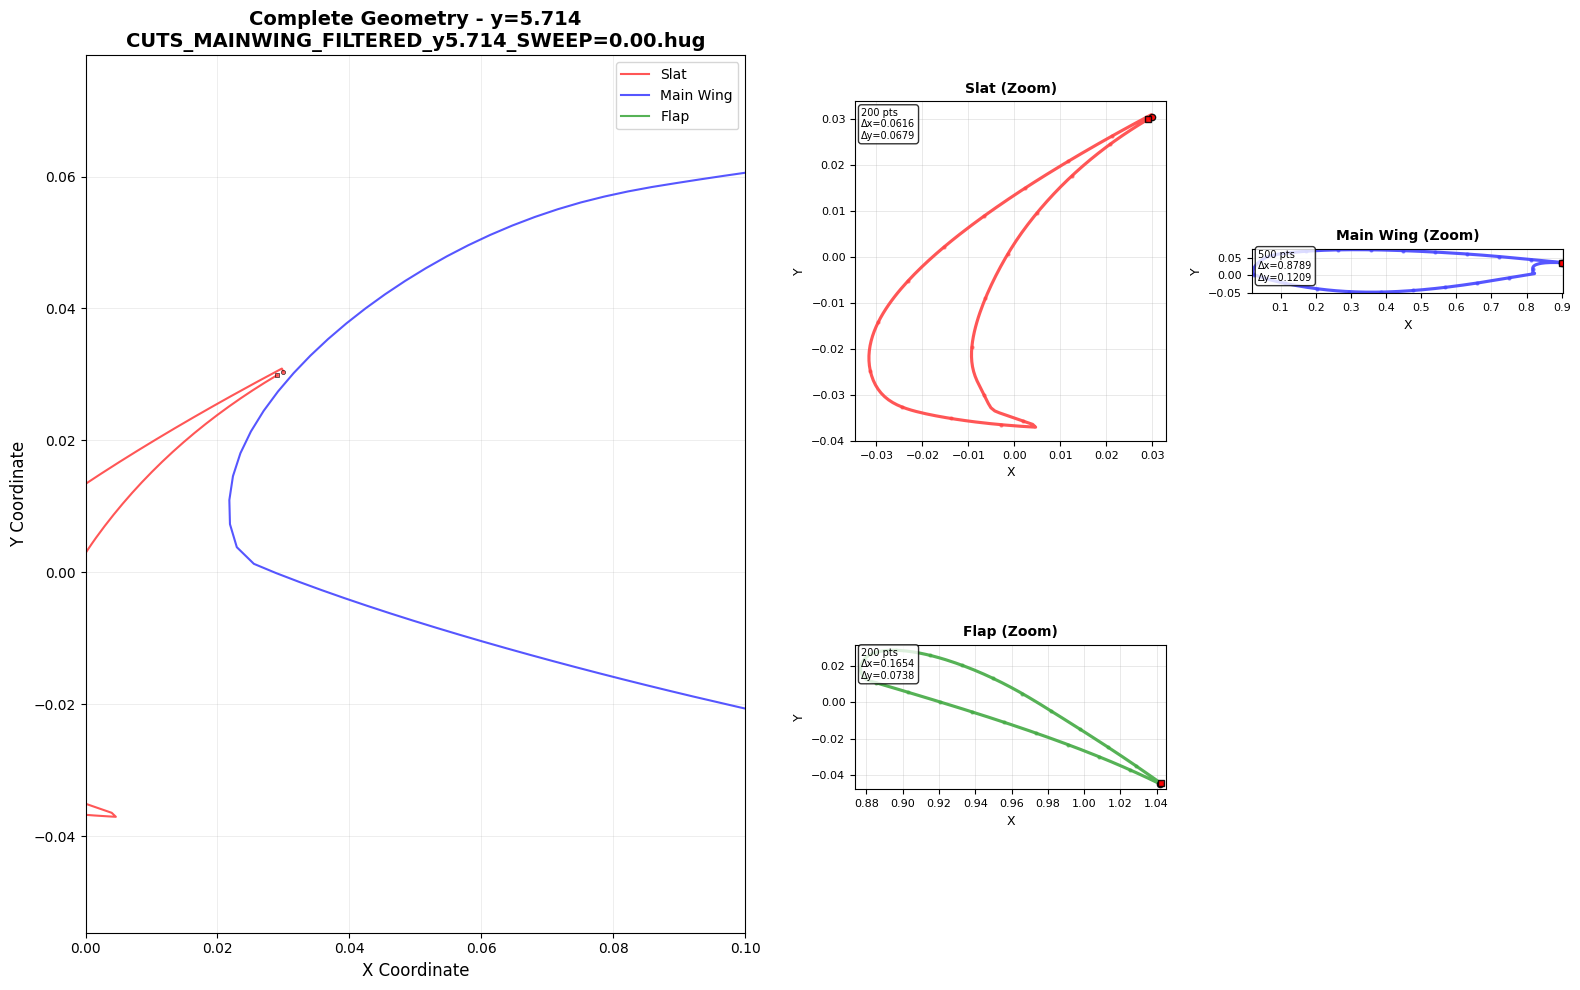


Geometry Details - y=5.714:
  File: CUTS_MAINWING_FILTERED_y5.714_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0616, Y-range=0.0679
  Main Wing: 500 points, X-range=0.8789, Y-range=0.1209
  Flap: 200 points, X-range=0.1654, Y-range=0.0738

PLOTTING 11/31: y=5.980


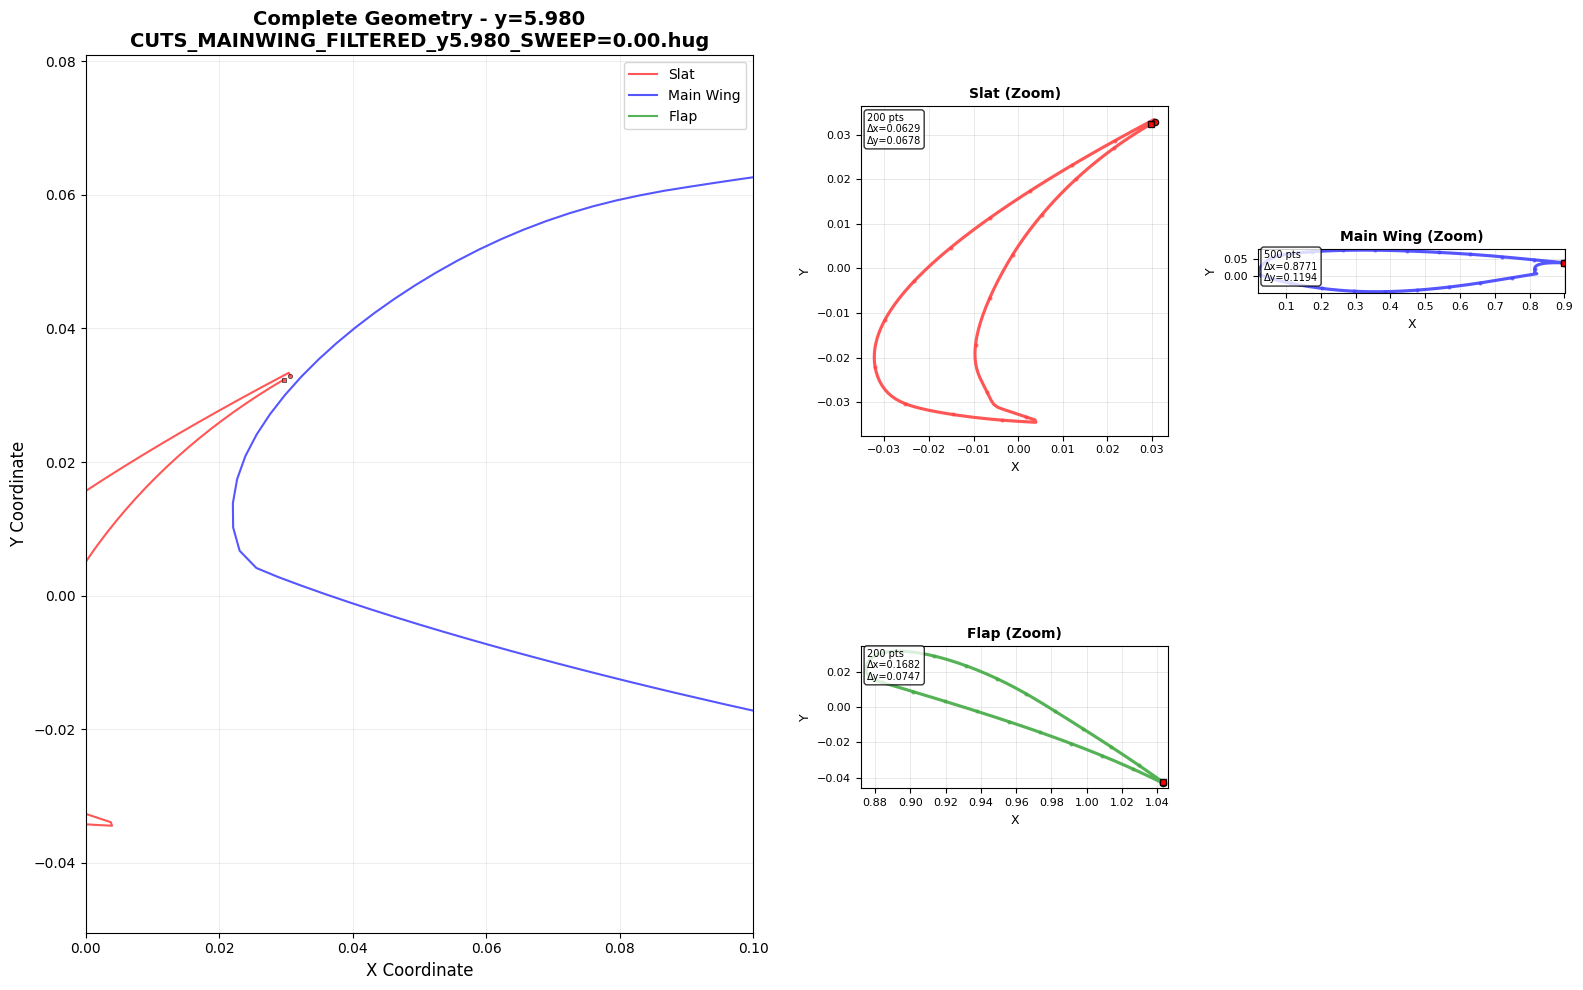


Geometry Details - y=5.980:
  File: CUTS_MAINWING_FILTERED_y5.980_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0629, Y-range=0.0678
  Main Wing: 500 points, X-range=0.8771, Y-range=0.1194
  Flap: 200 points, X-range=0.1682, Y-range=0.0747

PLOTTING 12/31: y=6.246


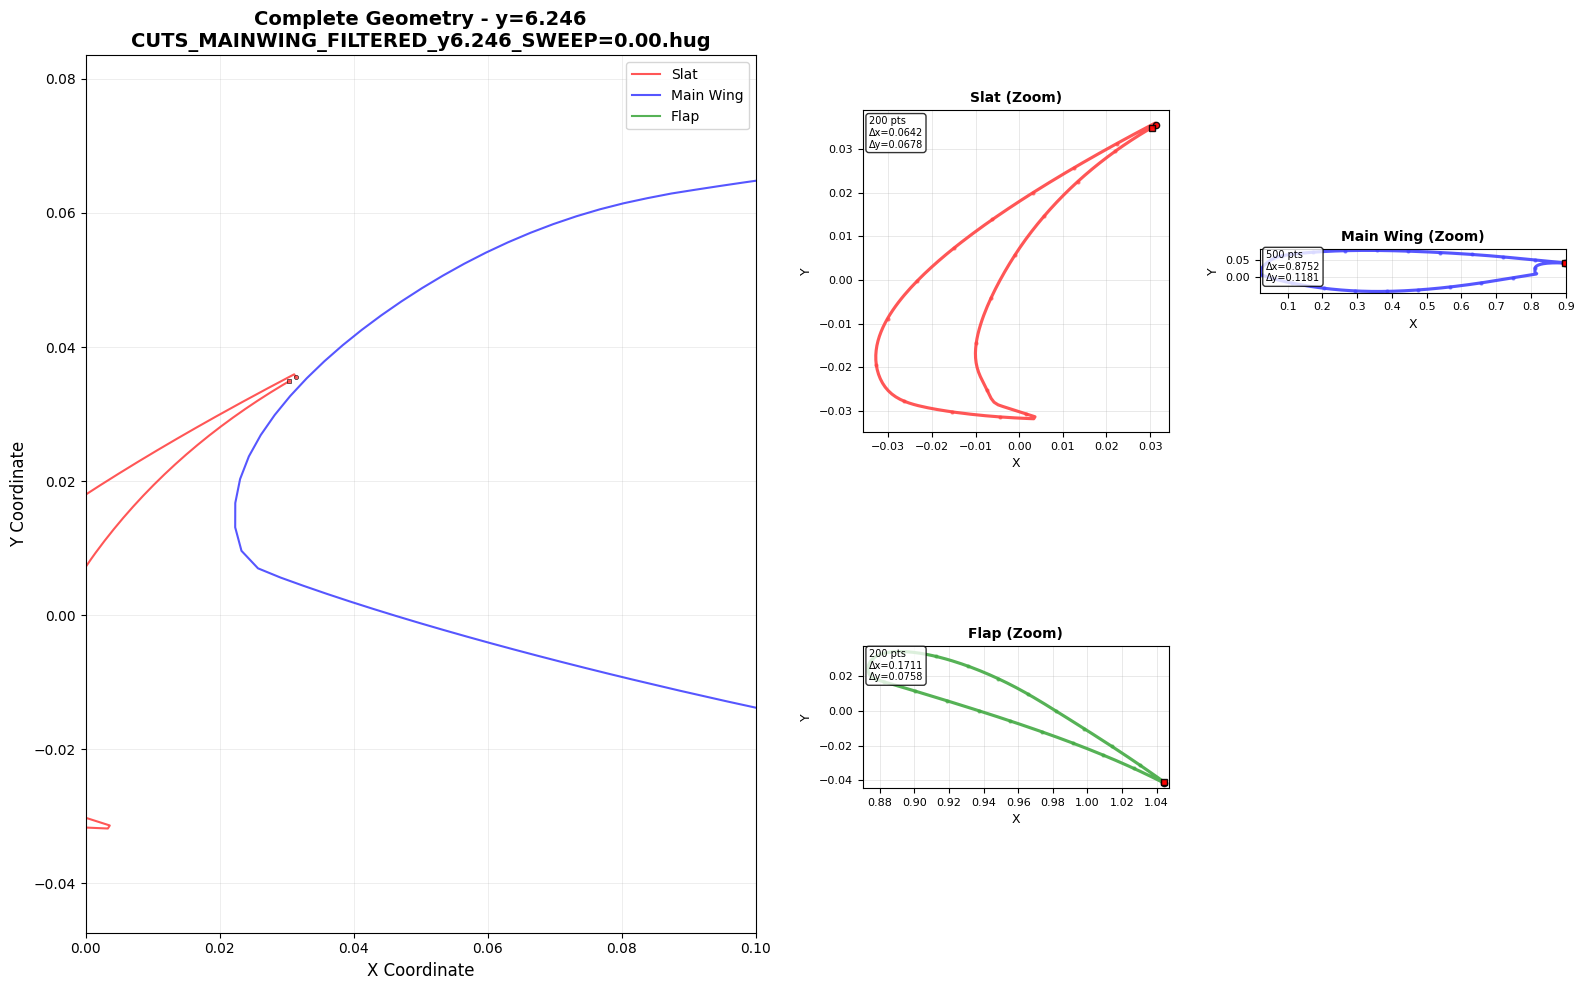


Geometry Details - y=6.246:
  File: CUTS_MAINWING_FILTERED_y6.246_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0642, Y-range=0.0678
  Main Wing: 500 points, X-range=0.8752, Y-range=0.1181
  Flap: 200 points, X-range=0.1711, Y-range=0.0758

PLOTTING 13/31: y=6.512


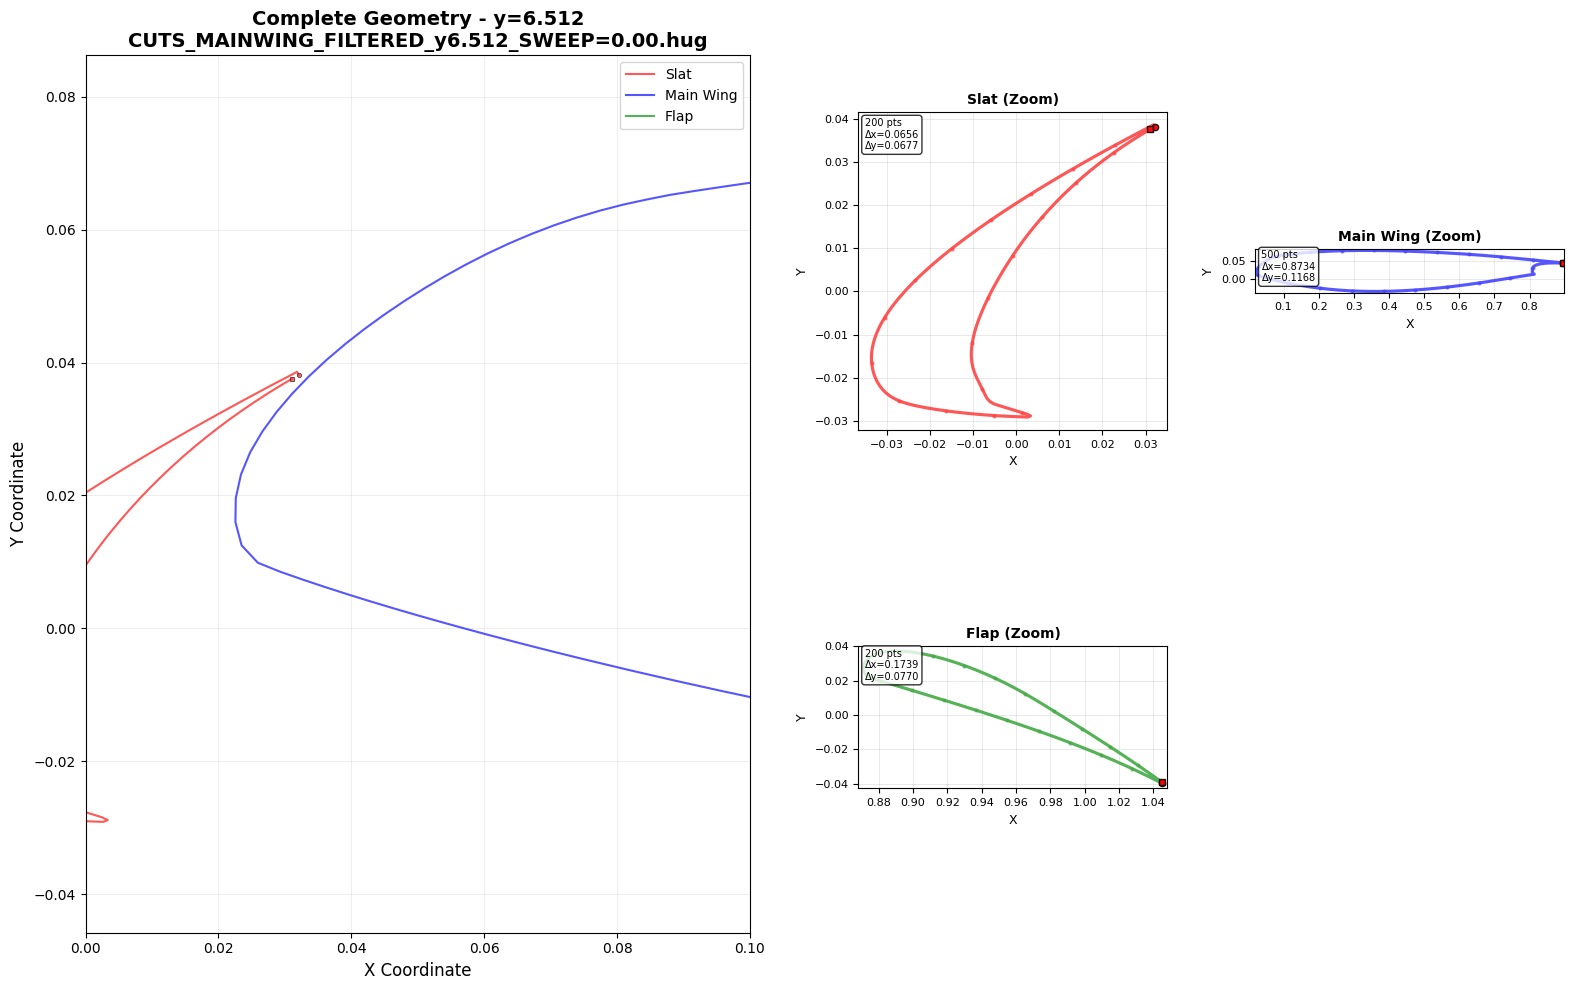


Geometry Details - y=6.512:
  File: CUTS_MAINWING_FILTERED_y6.512_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0656, Y-range=0.0677
  Main Wing: 500 points, X-range=0.8734, Y-range=0.1168
  Flap: 200 points, X-range=0.1739, Y-range=0.0770

PLOTTING 14/31: y=6.778


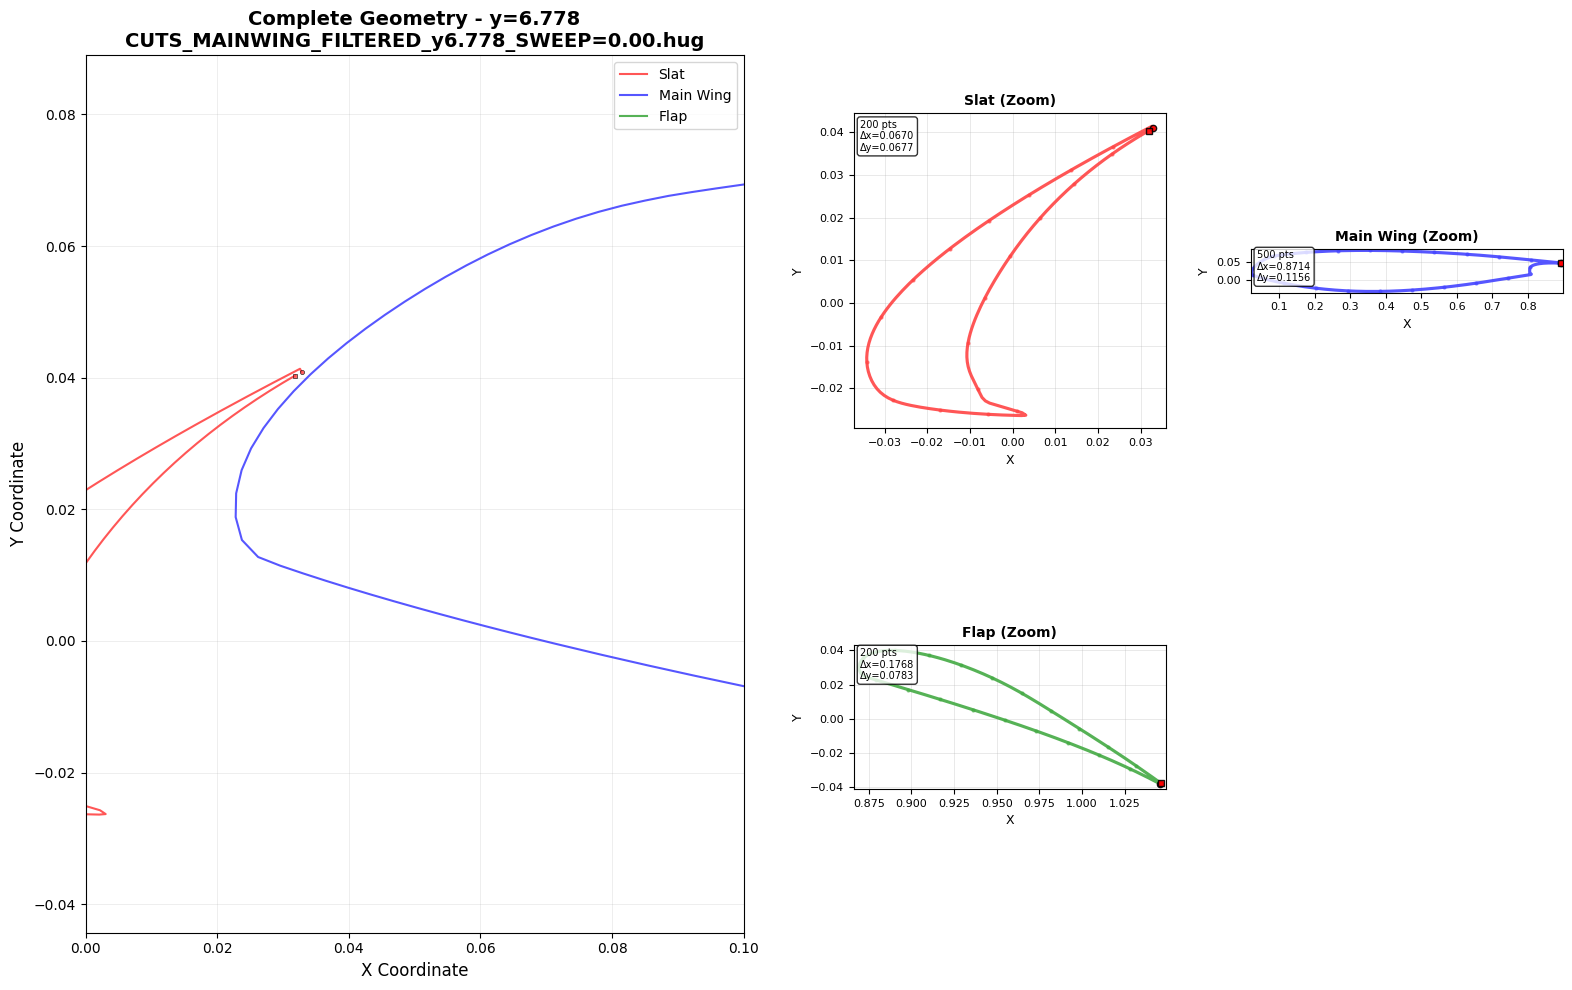


Geometry Details - y=6.778:
  File: CUTS_MAINWING_FILTERED_y6.778_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0670, Y-range=0.0677
  Main Wing: 500 points, X-range=0.8714, Y-range=0.1156
  Flap: 200 points, X-range=0.1768, Y-range=0.0783

PLOTTING 15/31: y=7.044


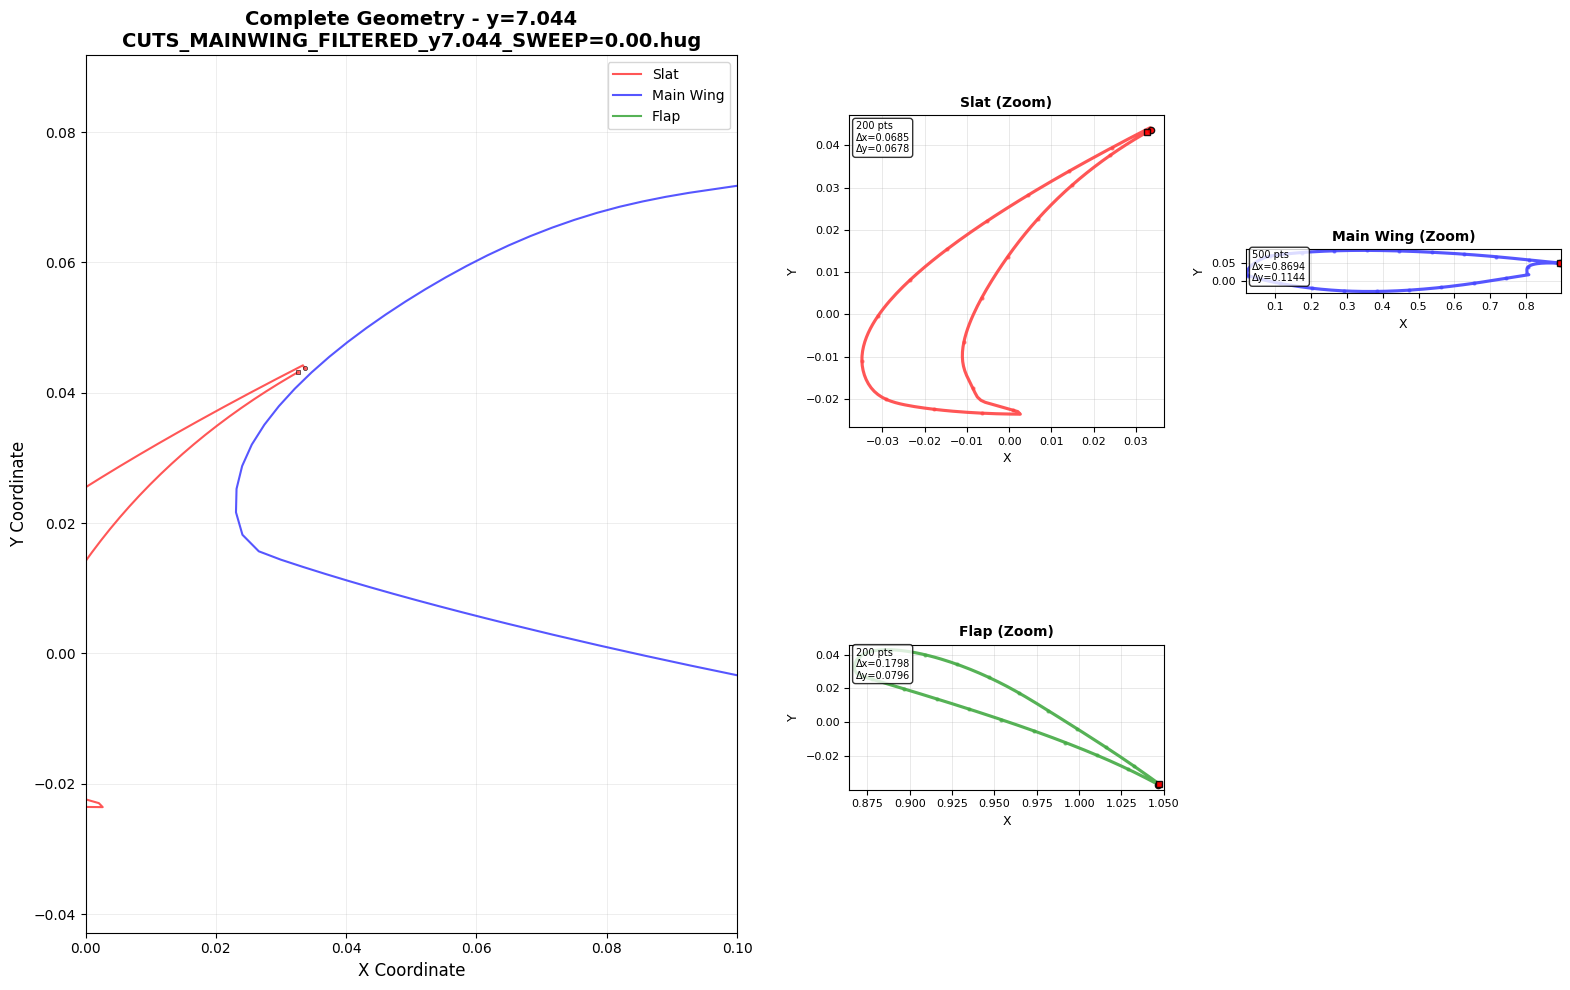


Geometry Details - y=7.044:
  File: CUTS_MAINWING_FILTERED_y7.044_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0685, Y-range=0.0678
  Main Wing: 500 points, X-range=0.8694, Y-range=0.1144
  Flap: 200 points, X-range=0.1798, Y-range=0.0796

PLOTTING 16/31: y=7.310


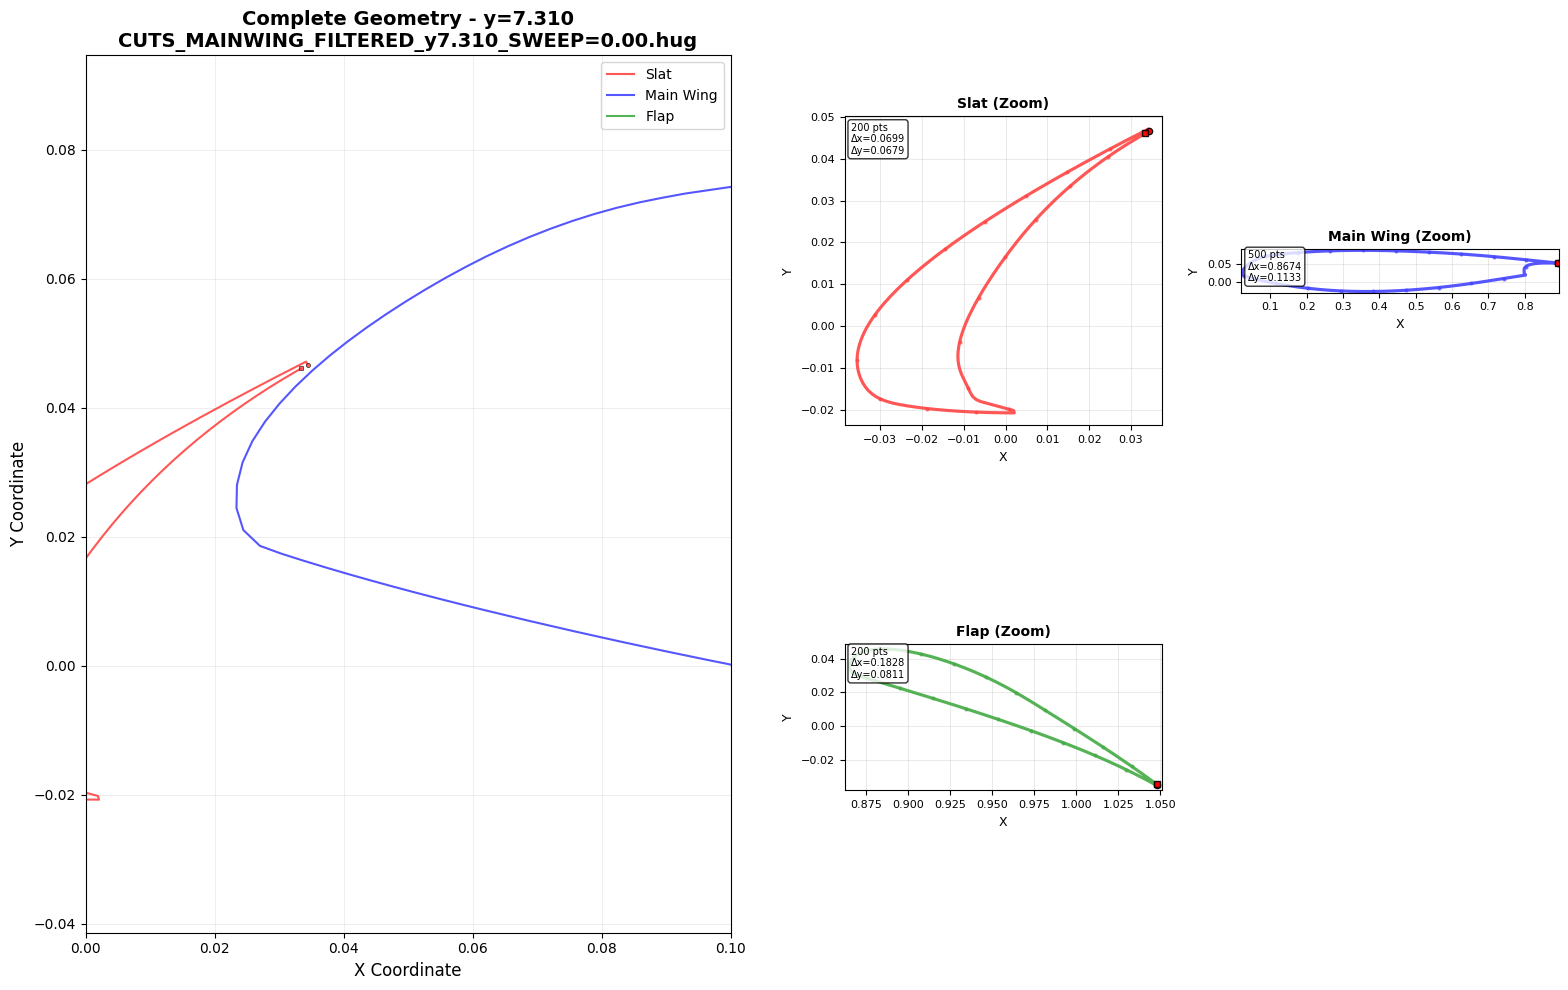


Geometry Details - y=7.310:
  File: CUTS_MAINWING_FILTERED_y7.310_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0699, Y-range=0.0679
  Main Wing: 500 points, X-range=0.8674, Y-range=0.1133
  Flap: 200 points, X-range=0.1828, Y-range=0.0811

PLOTTING 17/31: y=7.575


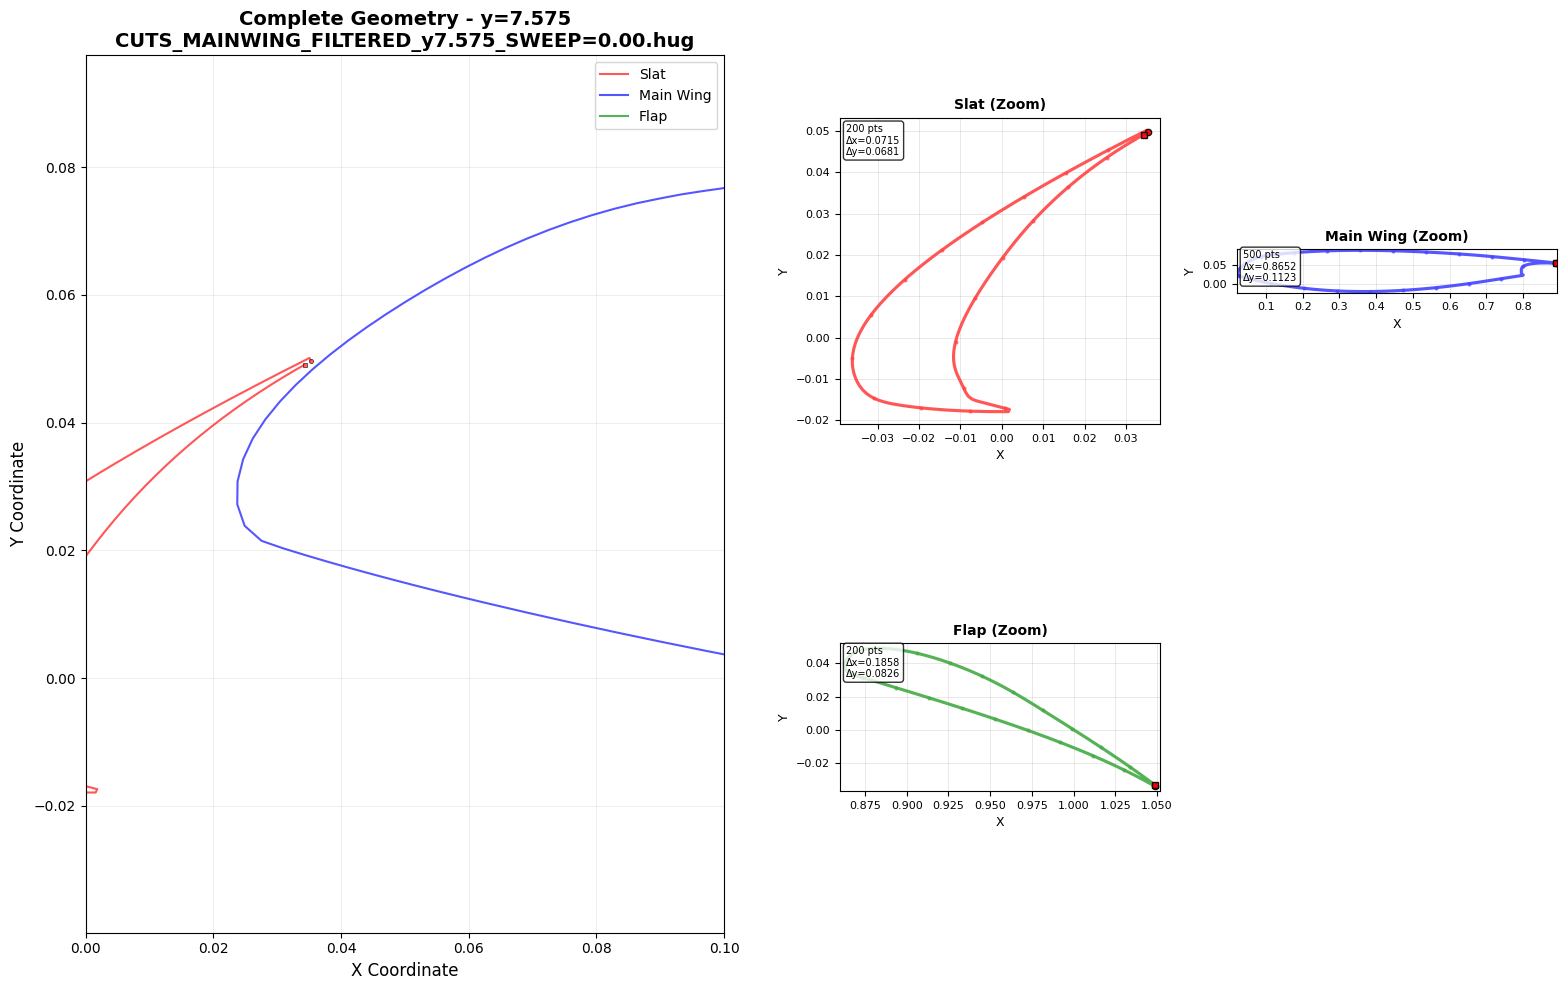


Geometry Details - y=7.575:
  File: CUTS_MAINWING_FILTERED_y7.575_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0715, Y-range=0.0681
  Main Wing: 500 points, X-range=0.8652, Y-range=0.1123
  Flap: 200 points, X-range=0.1858, Y-range=0.0826

PLOTTING 18/31: y=7.841


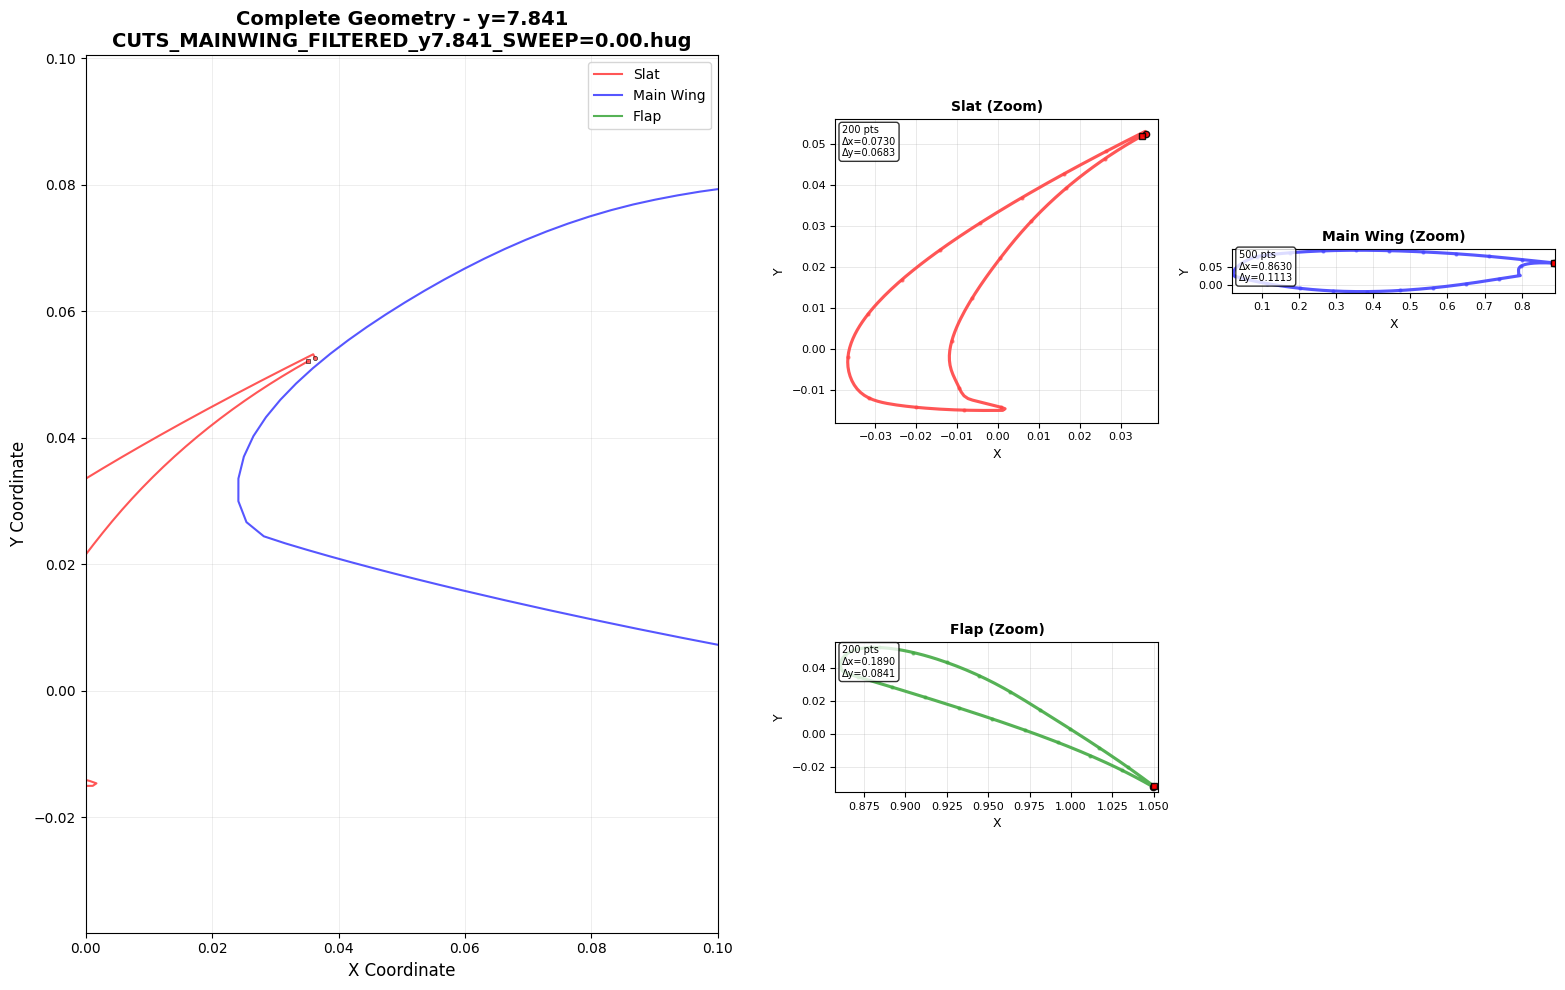


Geometry Details - y=7.841:
  File: CUTS_MAINWING_FILTERED_y7.841_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0730, Y-range=0.0683
  Main Wing: 500 points, X-range=0.8630, Y-range=0.1113
  Flap: 200 points, X-range=0.1890, Y-range=0.0841

PLOTTING 19/31: y=8.107


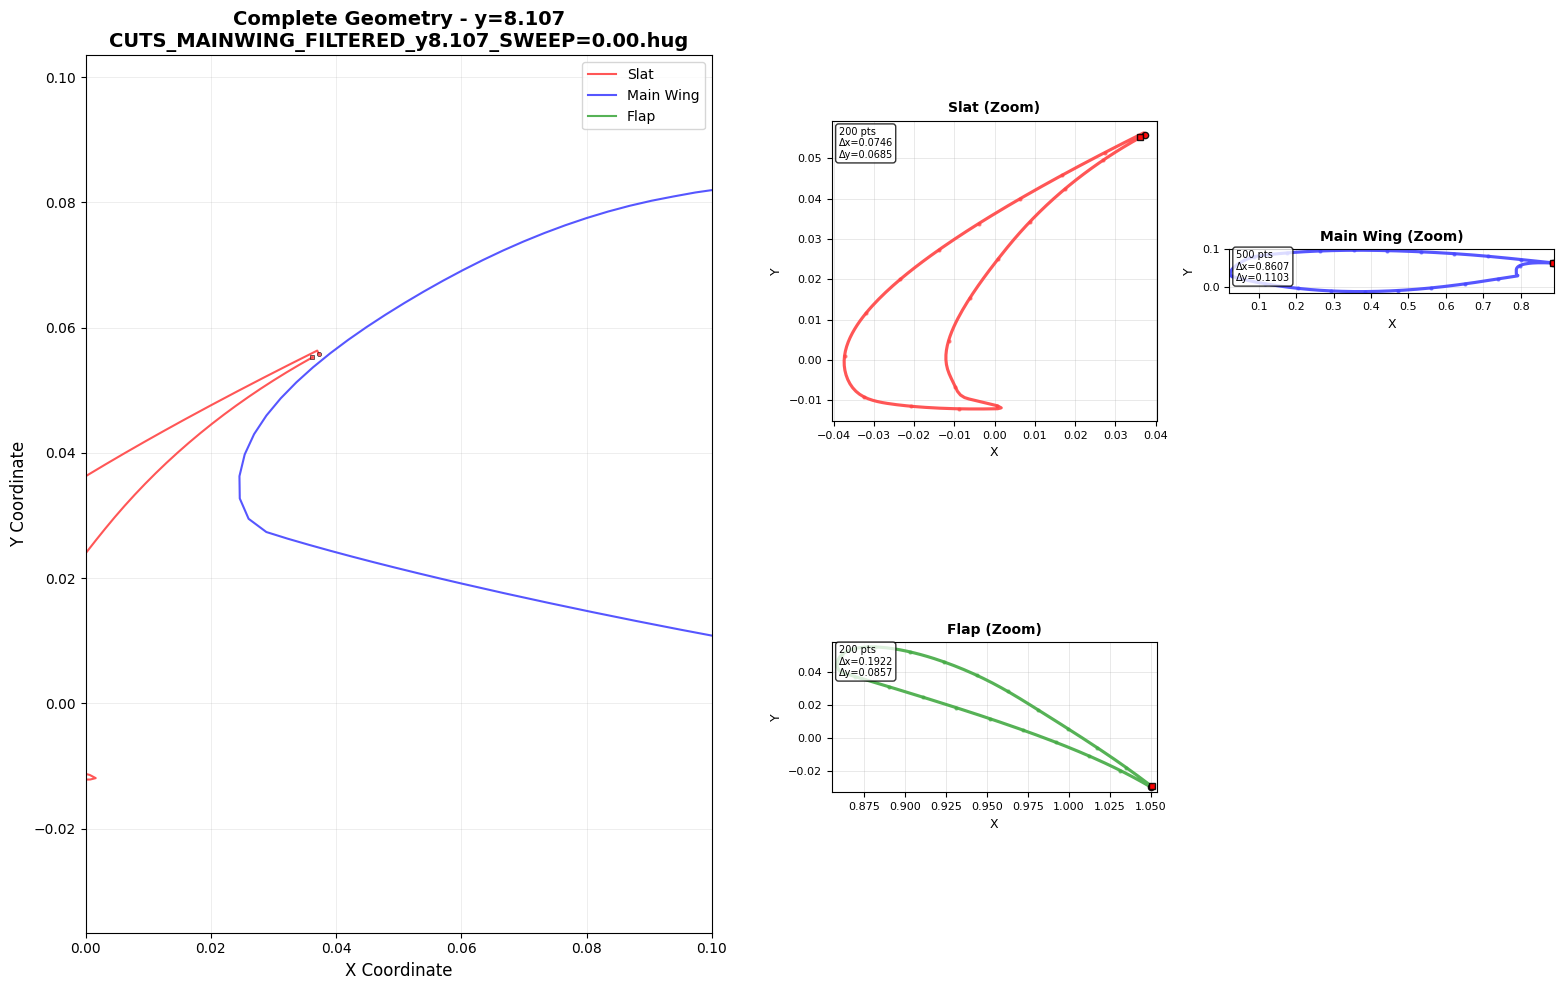


Geometry Details - y=8.107:
  File: CUTS_MAINWING_FILTERED_y8.107_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0746, Y-range=0.0685
  Main Wing: 500 points, X-range=0.8607, Y-range=0.1103
  Flap: 200 points, X-range=0.1922, Y-range=0.0857

PLOTTING 20/31: y=8.373


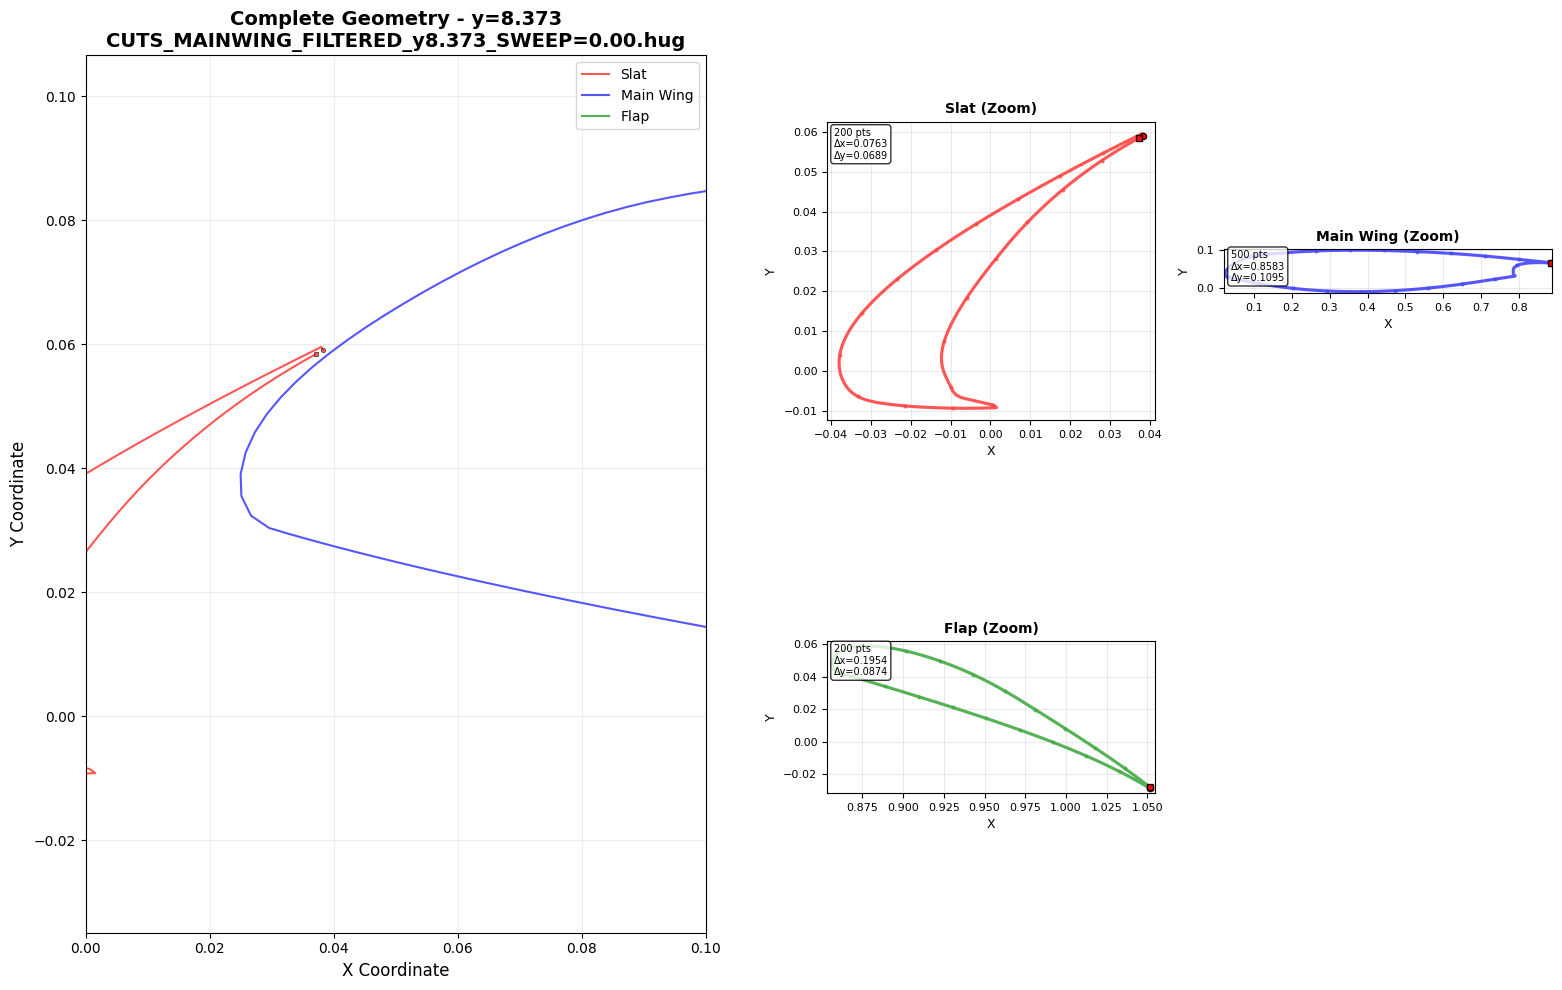


Geometry Details - y=8.373:
  File: CUTS_MAINWING_FILTERED_y8.373_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0763, Y-range=0.0689
  Main Wing: 500 points, X-range=0.8583, Y-range=0.1095
  Flap: 200 points, X-range=0.1954, Y-range=0.0874

PLOTTING 21/31: y=8.639


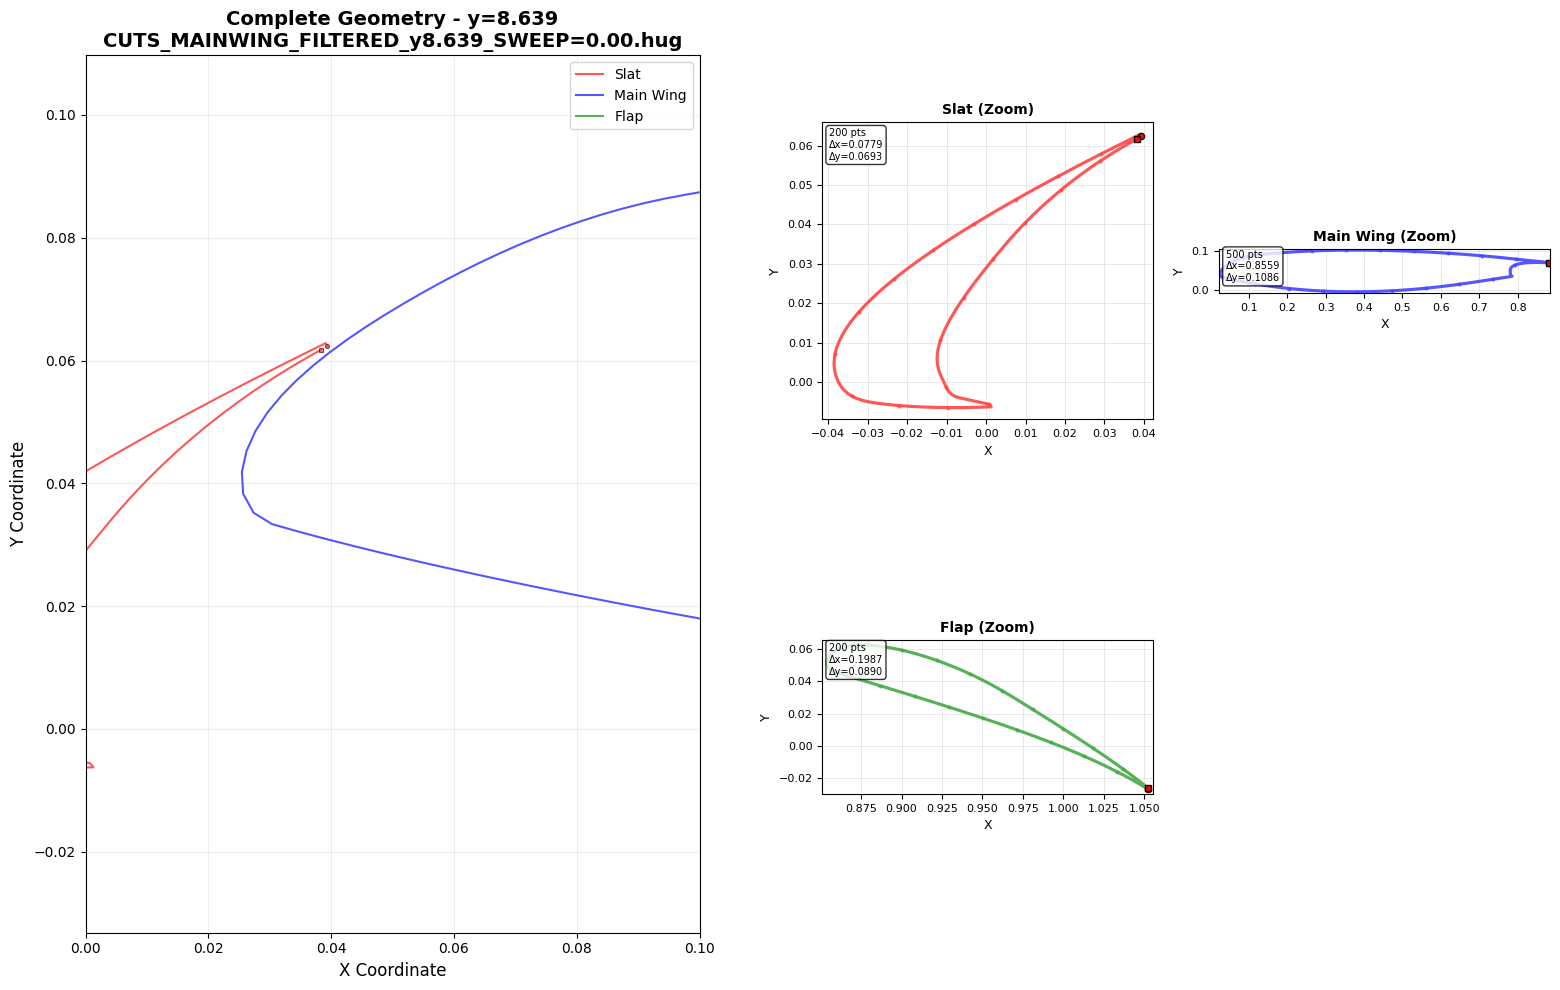


Geometry Details - y=8.639:
  File: CUTS_MAINWING_FILTERED_y8.639_SWEEP=0.00.hug
  Total elements: 3
  Slat: 200 points, X-range=0.0779, Y-range=0.0693
  Main Wing: 500 points, X-range=0.8559, Y-range=0.1086
  Flap: 200 points, X-range=0.1987, Y-range=0.0890

PLOTTING 22/31: y=11.032


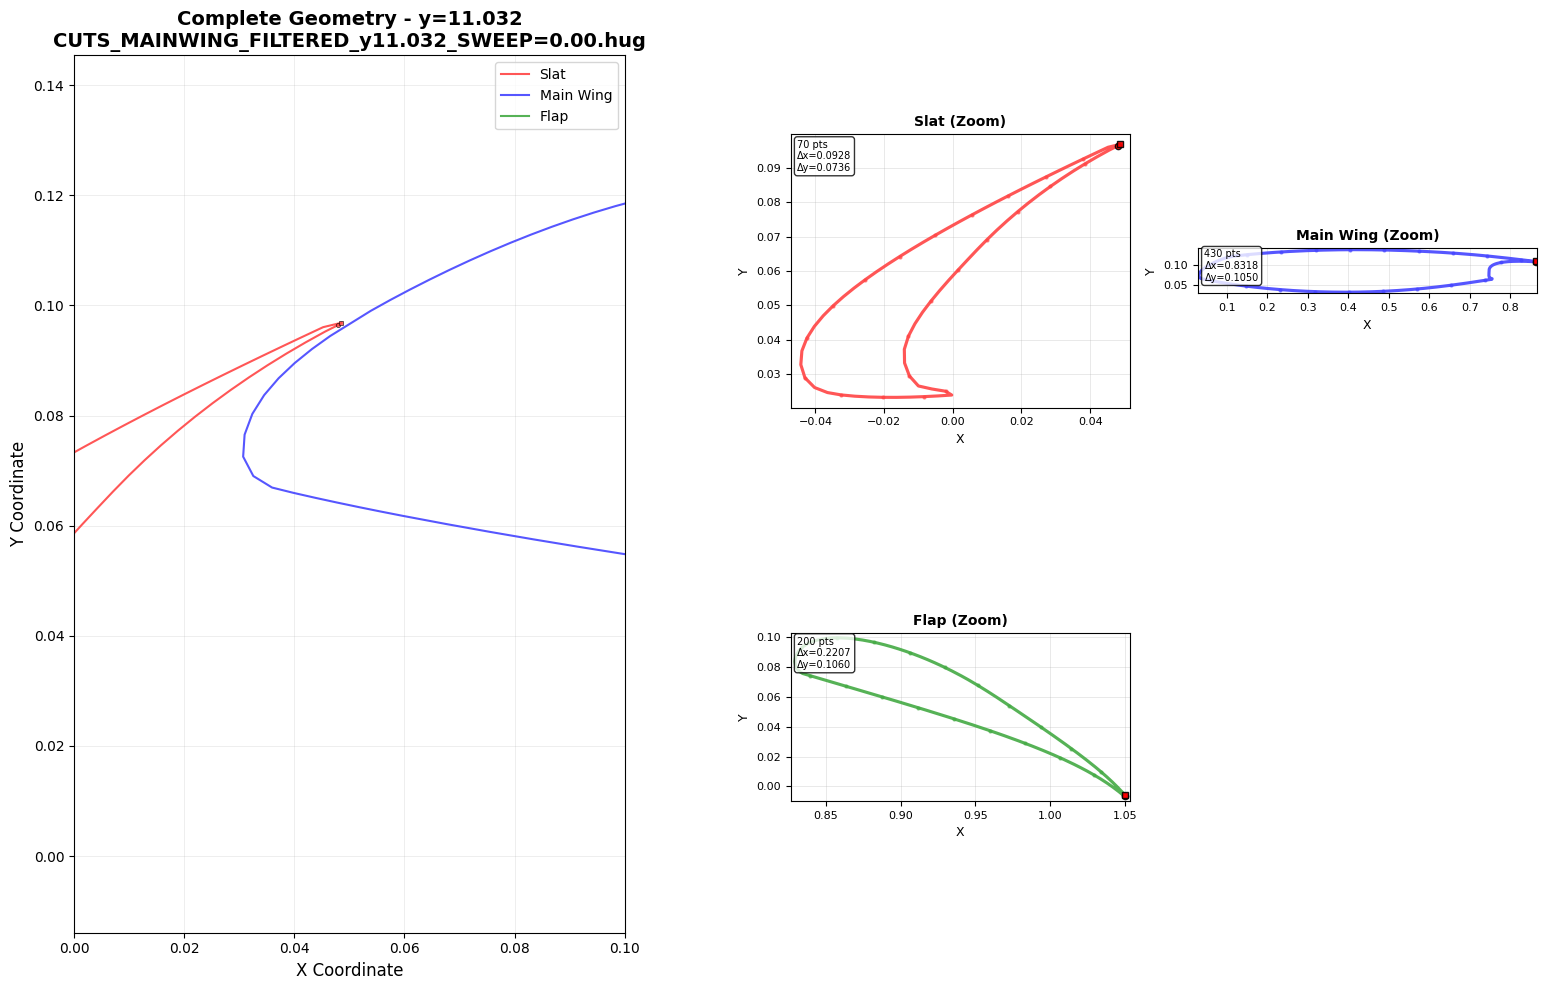


Geometry Details - y=11.032:
  File: CUTS_MAINWING_FILTERED_y11.032_SWEEP=0.00.hug
  Total elements: 3
  Slat: 70 points, X-range=0.0928, Y-range=0.0736
  Main Wing: 430 points, X-range=0.8318, Y-range=0.1050
  Flap: 200 points, X-range=0.2207, Y-range=0.1060

PLOTTING 23/31: y=12.628


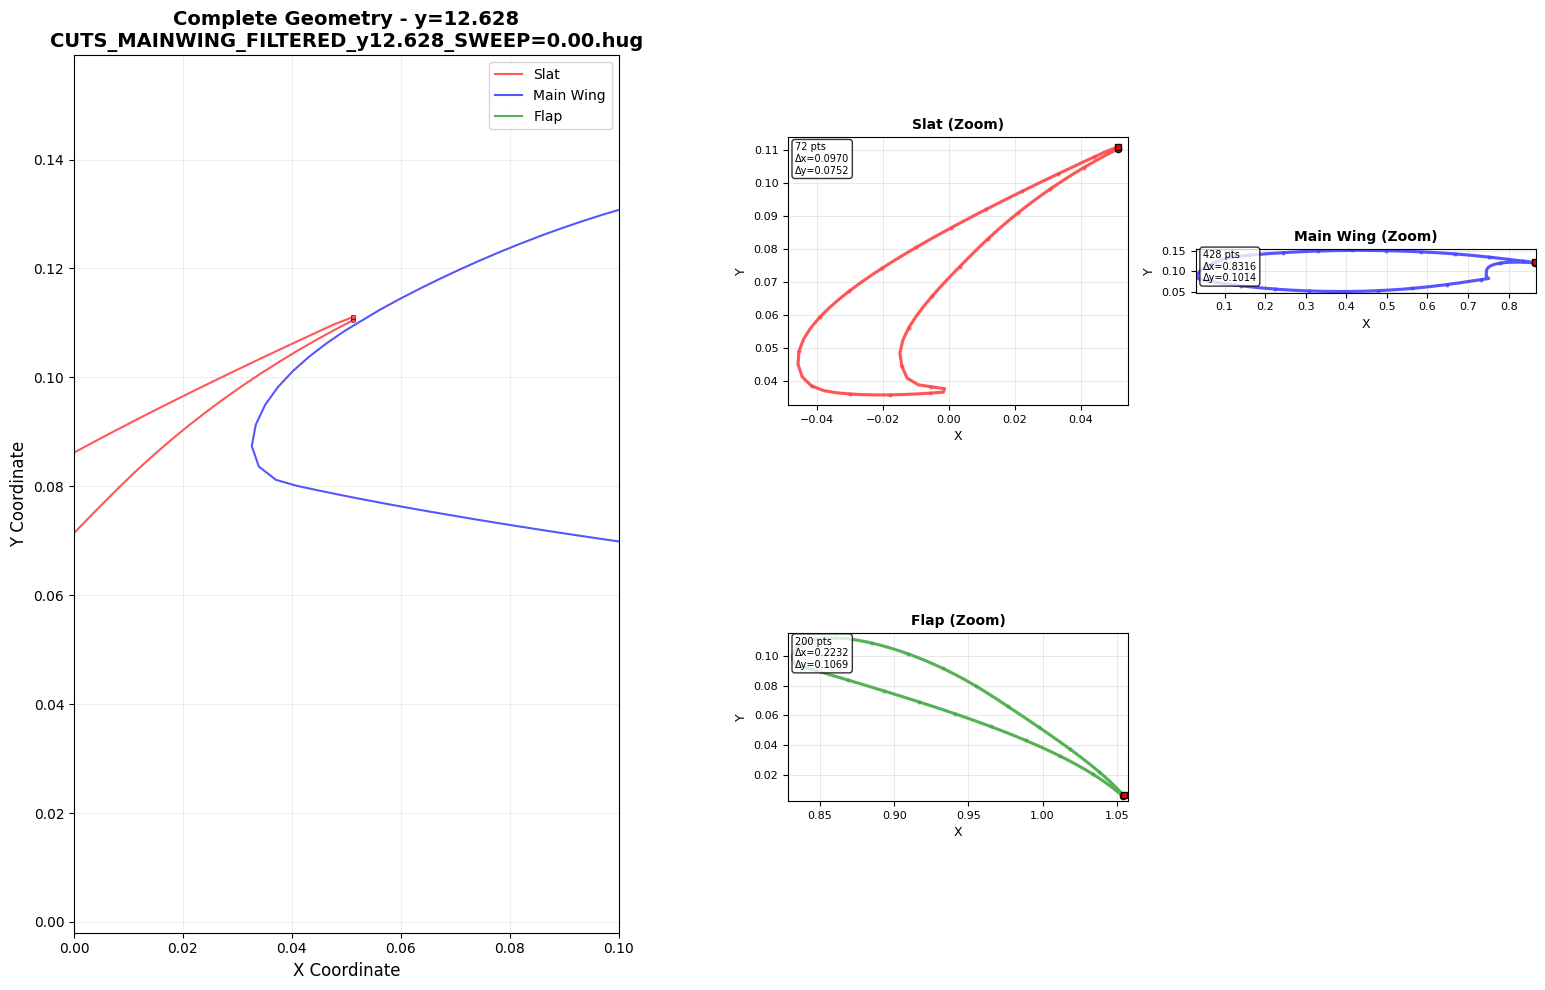


Geometry Details - y=12.628:
  File: CUTS_MAINWING_FILTERED_y12.628_SWEEP=0.00.hug
  Total elements: 3
  Slat: 72 points, X-range=0.0970, Y-range=0.0752
  Main Wing: 428 points, X-range=0.8316, Y-range=0.1014
  Flap: 200 points, X-range=0.2232, Y-range=0.1069

PLOTTING 24/31: y=13.957


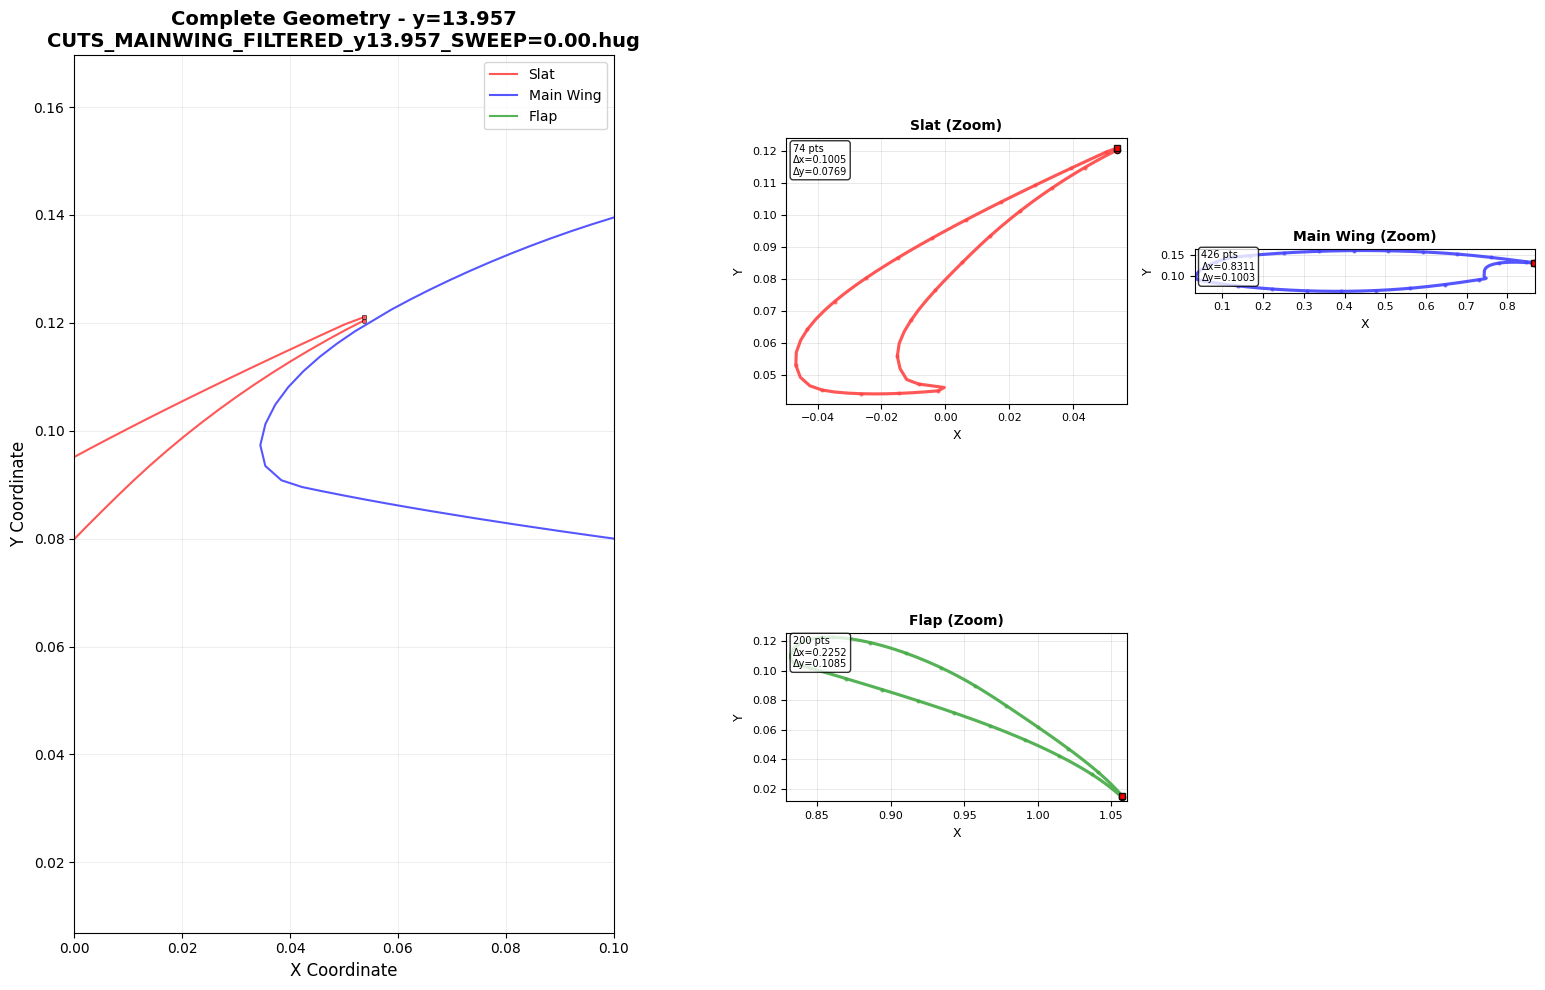


Geometry Details - y=13.957:
  File: CUTS_MAINWING_FILTERED_y13.957_SWEEP=0.00.hug
  Total elements: 3
  Slat: 74 points, X-range=0.1005, Y-range=0.0769
  Main Wing: 426 points, X-range=0.8311, Y-range=0.1003
  Flap: 200 points, X-range=0.2252, Y-range=0.1085

PLOTTING 25/31: y=16.882


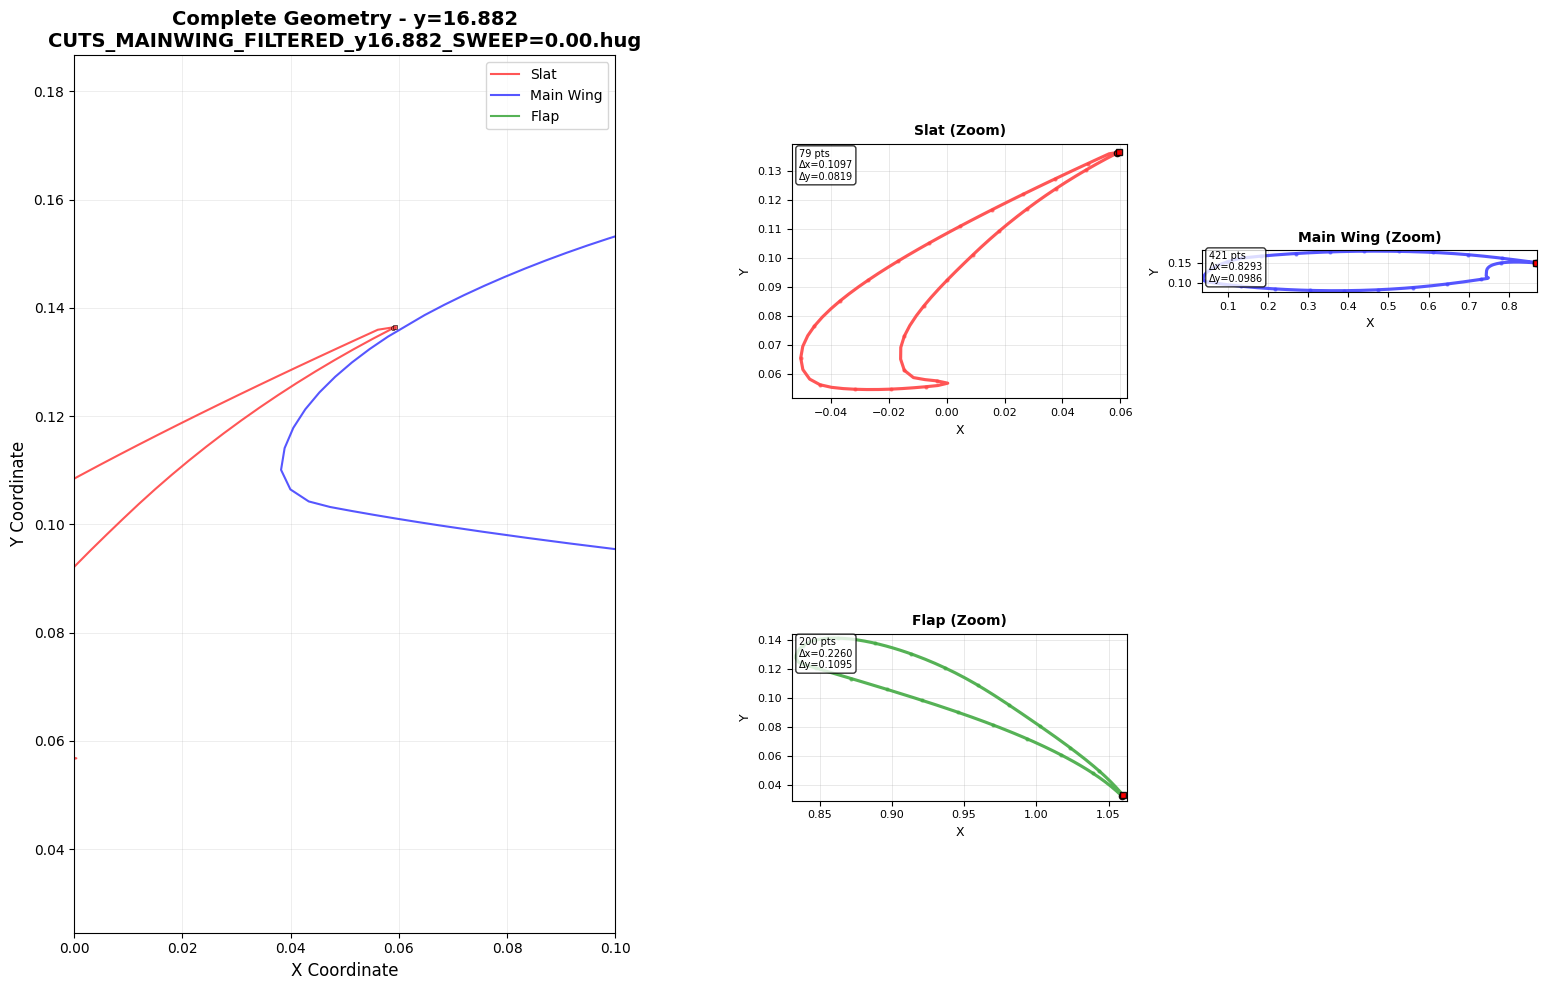


Geometry Details - y=16.882:
  File: CUTS_MAINWING_FILTERED_y16.882_SWEEP=0.00.hug
  Total elements: 3
  Slat: 79 points, X-range=0.1097, Y-range=0.0819
  Main Wing: 421 points, X-range=0.8293, Y-range=0.0986
  Flap: 200 points, X-range=0.2260, Y-range=0.1095

PLOTTING 26/31: y=17.946


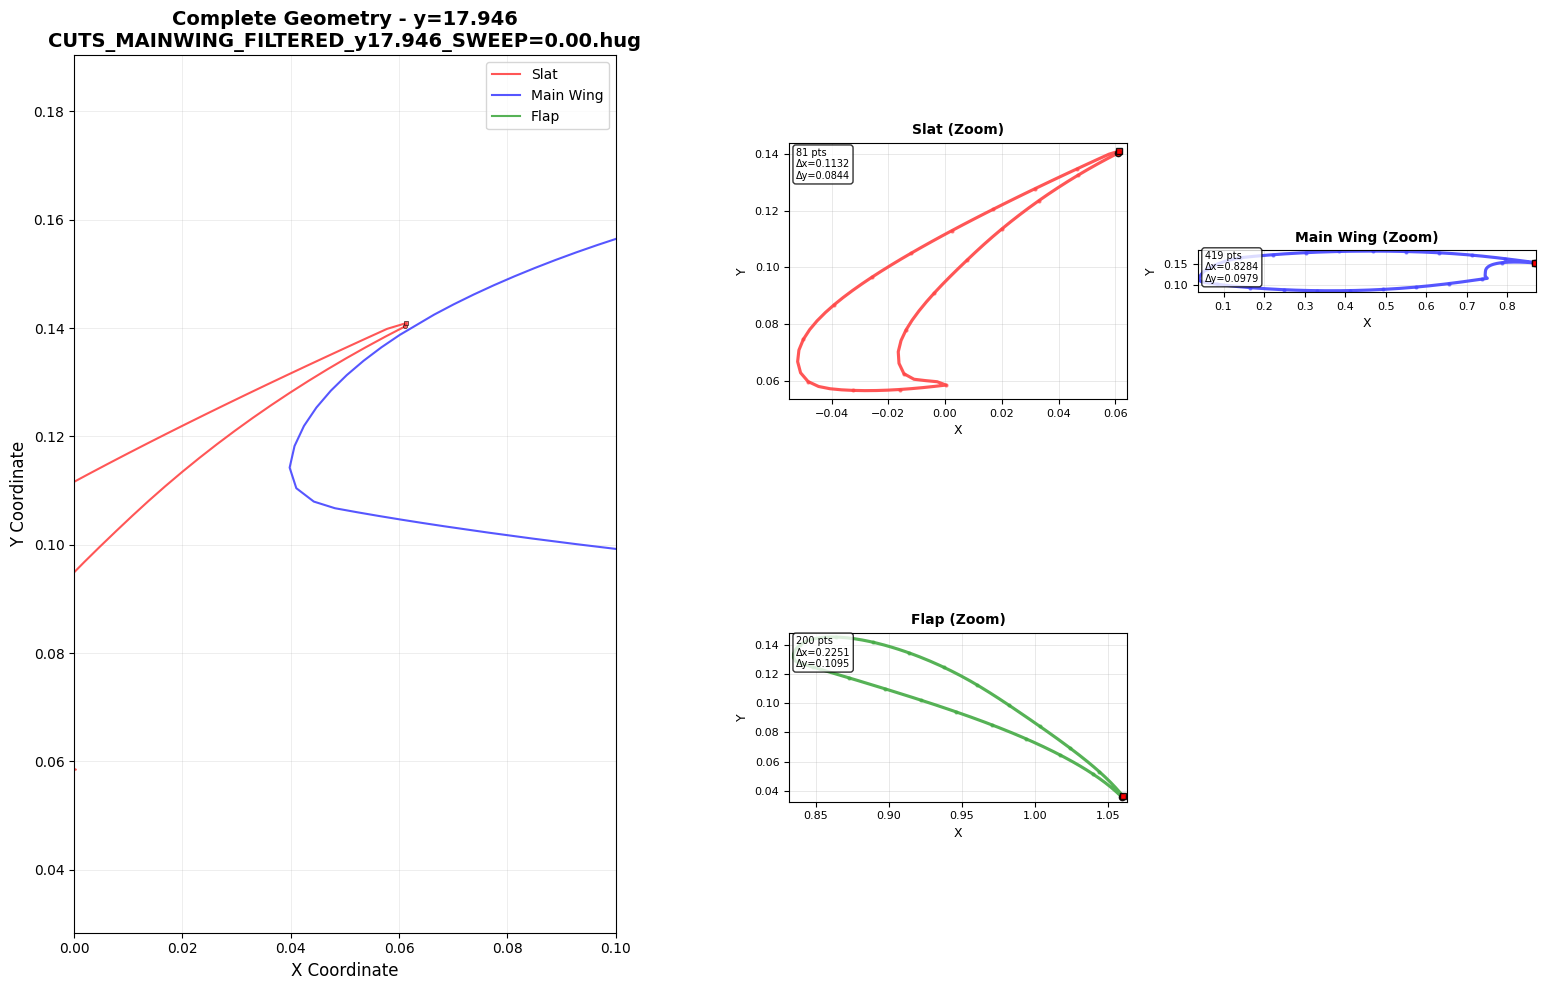


Geometry Details - y=17.946:
  File: CUTS_MAINWING_FILTERED_y17.946_SWEEP=0.00.hug
  Total elements: 3
  Slat: 81 points, X-range=0.1132, Y-range=0.0844
  Main Wing: 419 points, X-range=0.8284, Y-range=0.0979
  Flap: 200 points, X-range=0.2251, Y-range=0.1095

PLOTTING 27/31: y=18.744


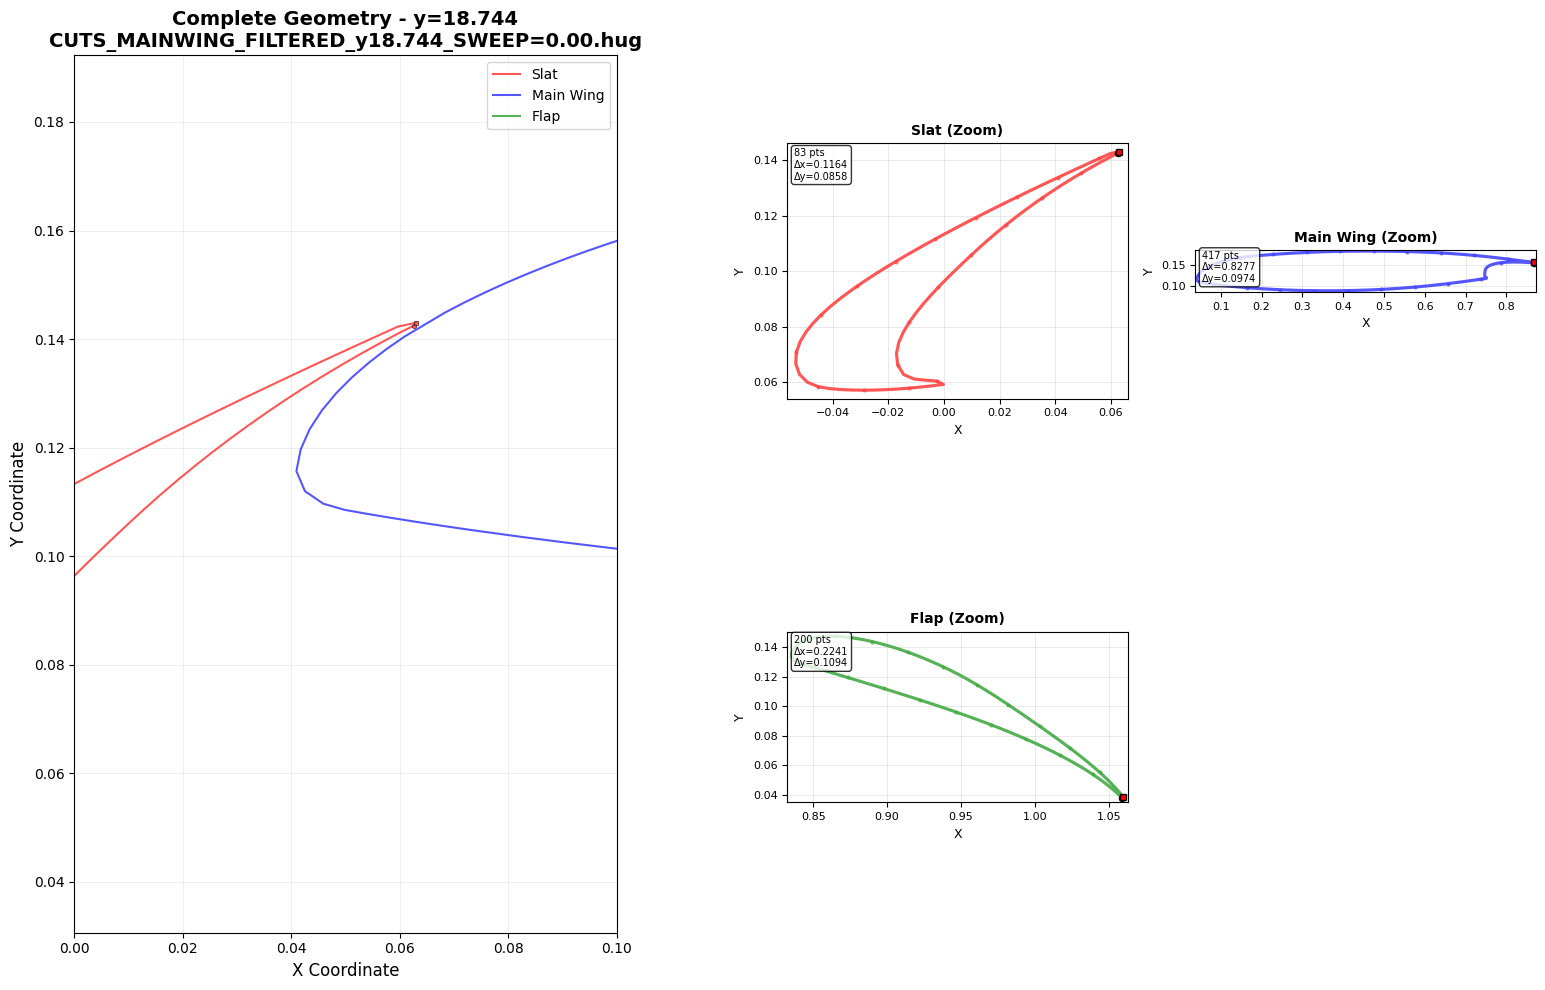


Geometry Details - y=18.744:
  File: CUTS_MAINWING_FILTERED_y18.744_SWEEP=0.00.hug
  Total elements: 3
  Slat: 83 points, X-range=0.1164, Y-range=0.0858
  Main Wing: 417 points, X-range=0.8277, Y-range=0.0974
  Flap: 200 points, X-range=0.2241, Y-range=0.1094

PLOTTING 28/31: y=20.871


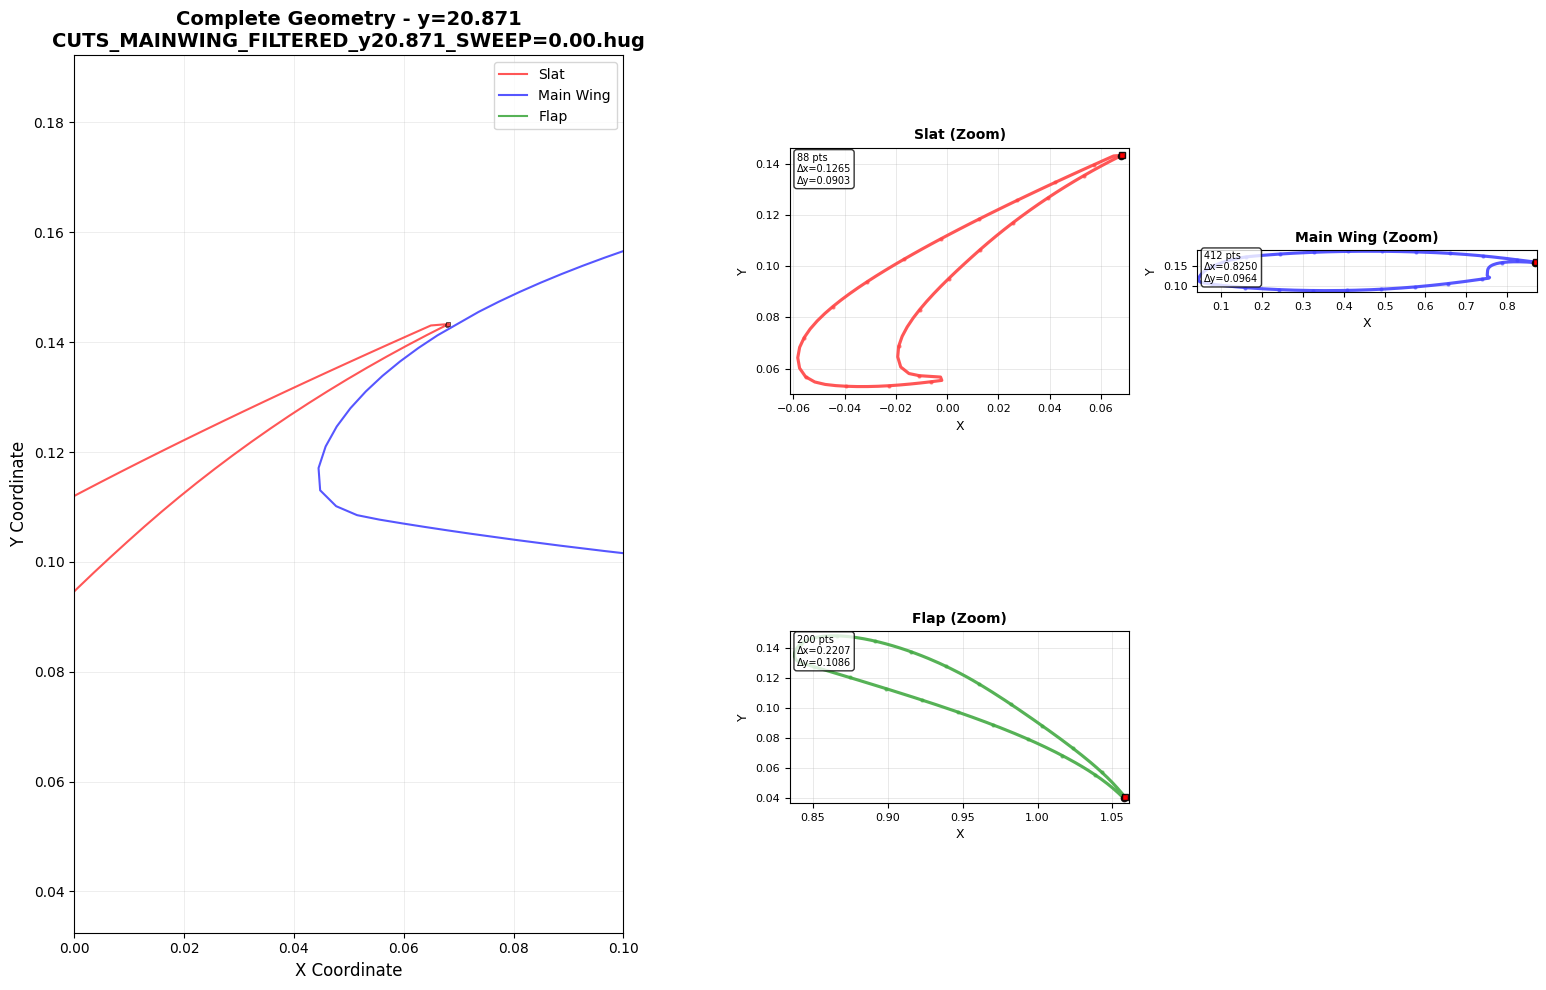


Geometry Details - y=20.871:
  File: CUTS_MAINWING_FILTERED_y20.871_SWEEP=0.00.hug
  Total elements: 3
  Slat: 88 points, X-range=0.1265, Y-range=0.0903
  Main Wing: 412 points, X-range=0.8250, Y-range=0.0964
  Flap: 200 points, X-range=0.2207, Y-range=0.1086

PLOTTING 29/31: y=22.200


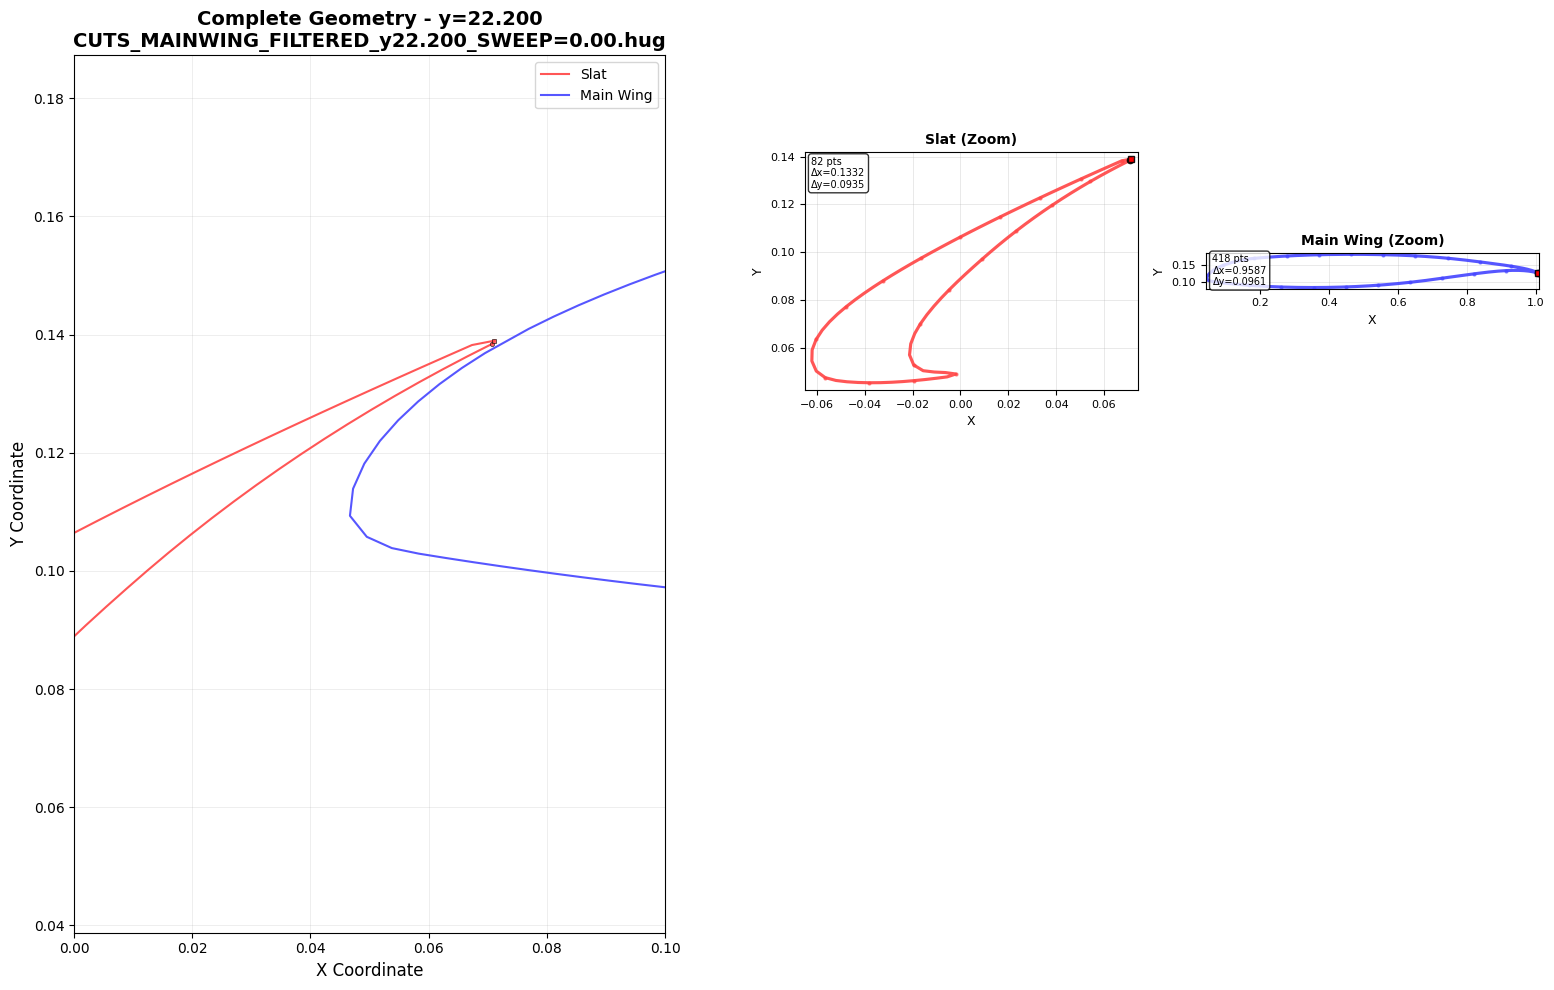


Geometry Details - y=22.200:
  File: CUTS_MAINWING_FILTERED_y22.200_SWEEP=0.00.hug
  Total elements: 2
  Slat: 82 points, X-range=0.1332, Y-range=0.0935
  Main Wing: 418 points, X-range=0.9587, Y-range=0.0961

PLOTTING 30/31: y=23.530


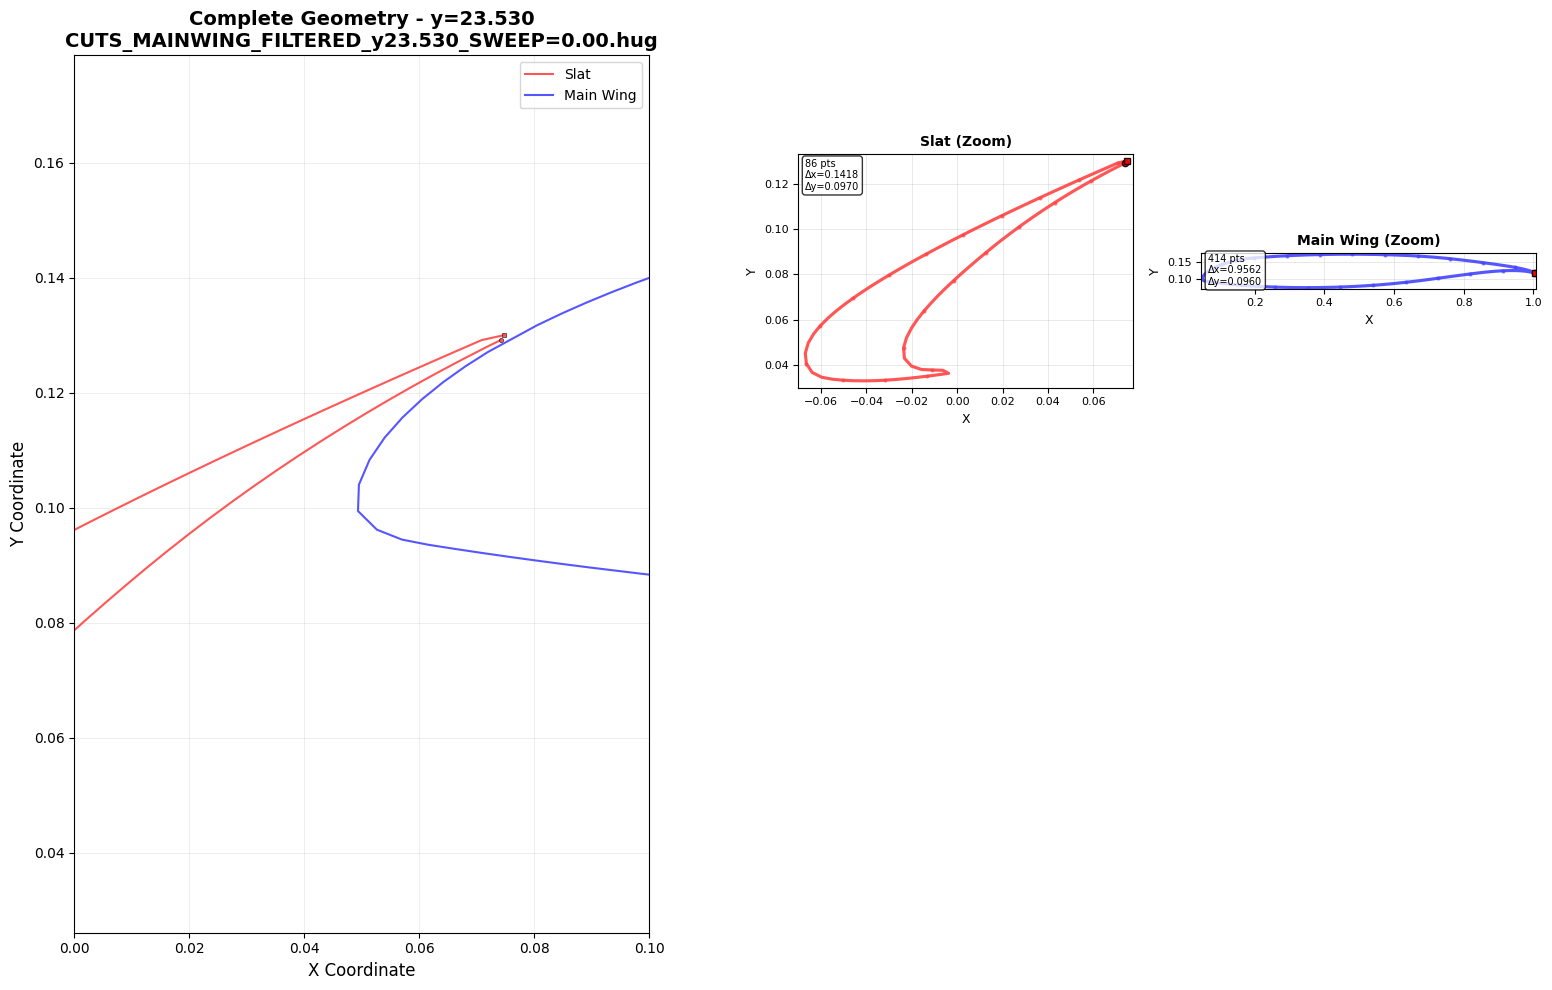


Geometry Details - y=23.530:
  File: CUTS_MAINWING_FILTERED_y23.530_SWEEP=0.00.hug
  Total elements: 2
  Slat: 86 points, X-range=0.1418, Y-range=0.0970
  Main Wing: 414 points, X-range=0.9562, Y-range=0.0960

PLOTTING 31/31: y=27.519


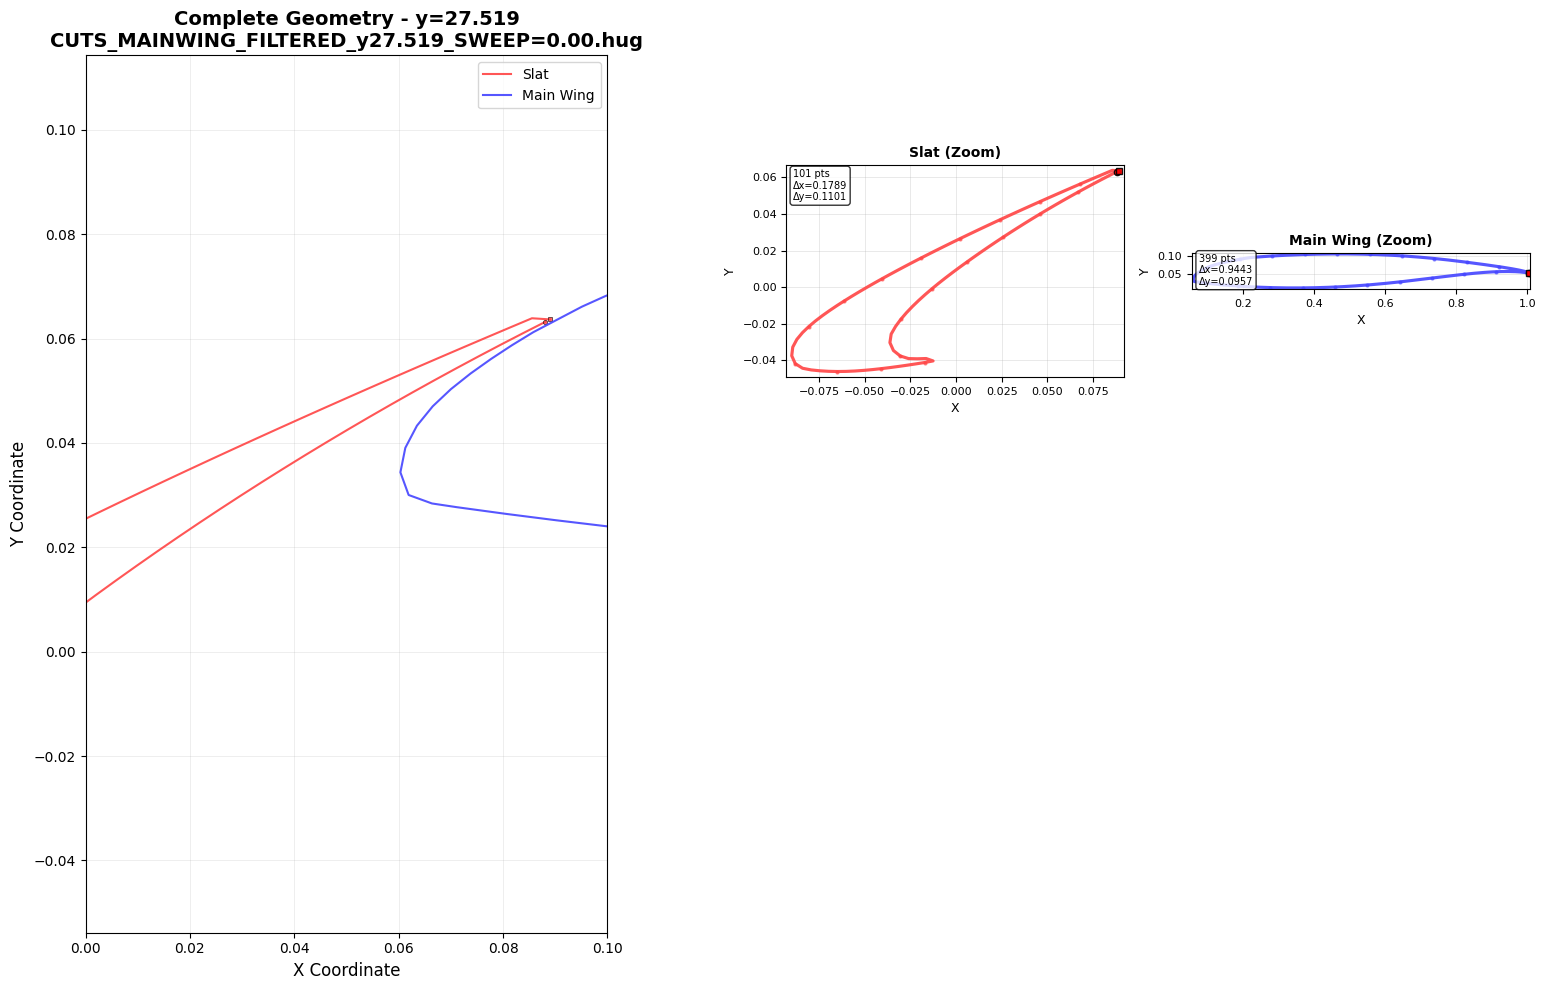


Geometry Details - y=27.519:
  File: CUTS_MAINWING_FILTERED_y27.519_SWEEP=0.00.hug
  Total elements: 2
  Slat: 101 points, X-range=0.1789, Y-range=0.1101
  Main Wing: 399 points, X-range=0.9443, Y-range=0.0957

COMPLETED PLOTTING ALL 31 GEOMETRIES

ALSO CREATING COMPARISON GRID...
Creating comparison grid from: /home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED


/tmp/ipykernel_118289/2912073837.py:329: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


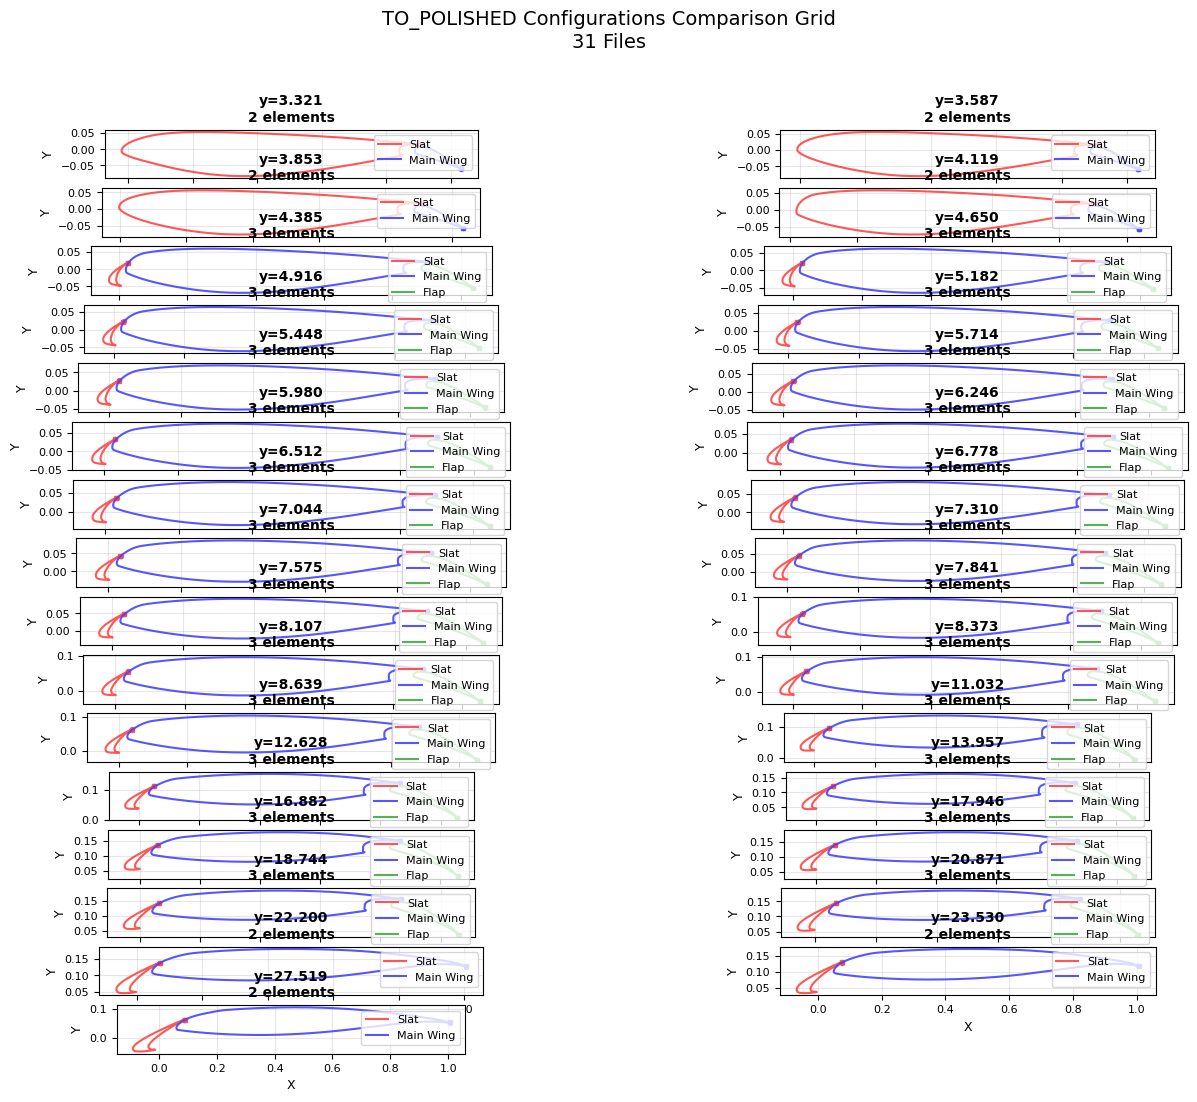

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import re
from typing import List, Tuple, Optional


def extract_y_location(filename: str) -> float:
    """Extract y location from filename"""
    match = re.search(r'y([\d.]+)', os.path.basename(filename))
    return float(match.group(1)) if match else None


def load_hug_file(filepath: str) -> List[np.ndarray]:
    """Load and parse .hug file, return list of elements"""
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        num_elements = int(lines[0].strip())
        elements = []
        line_idx = 1
        
        for elem_idx in range(num_elements):
            if line_idx >= len(lines):
                break
                
            num_points = int(lines[line_idx].strip())
            line_idx += 1
            
            element_coords = []
            for i in range(num_points):
                if line_idx >= len(lines):
                    break
                    
                line = lines[line_idx].strip()
                if line and not line.startswith('#'):
                    coords = [float(x) for x in line.split()]
                    if len(coords) >= 2:
                        element_coords.append([coords[0], coords[1]])
                line_idx += 1
            
            if element_coords:
                elements.append(np.array(element_coords))
        
        return elements
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return []


def get_element_bounds(element: np.ndarray, padding: float = 0.005) -> Tuple[float, float, float, float]:
    """Get bounding box for an element with padding"""
    x_min, x_max = np.min(element[:, 0]), np.max(element[:, 0])
    y_min, y_max = np.min(element[:, 1]), np.max(element[:, 1])
    
    # Add padding
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    x_min -= padding
    x_max += padding
    y_min -= padding  
    y_max += padding
    
    return x_min, x_max, y_min, y_max


def plot_single_geometry_detailed(geom_data: dict, 
                                 figure_size: Tuple[float, float] = (16, 10),
                                 line_width: float = 1.5,
                                 marker_size: float = 3):
    """
    Plot a single geometry with main plot + zoomed element details
    """
    elements = geom_data['elements']
    y_location = geom_data['y_location']
    filename = geom_data['filename']
    
    # Colors and names for elements
    colors = ['#FF4444', '#4444FF', '#44AA44', '#FF8800', '#AA44AA', '#8B4513']
    element_names = ['Slat', 'Main Wing', 'Flap', 'Element 4', 'Element 5', 'Element 6']
    
    # Create figure with subplots
    n_elements = len(elements)
    fig = plt.figure(figsize=figure_size)
    
    # Main plot (takes left half)
    ax_main = plt.subplot2grid((2, 4), (0, 0), rowspan=2, colspan=2)
    
    # Element zoom plots (right side)
    element_axes = []
    for i in range(min(n_elements, 4)):  # Max 4 zoom plots
        if i < 2:
            ax = plt.subplot2grid((2, 4), (0, 2+i))
        else:
            ax = plt.subplot2grid((2, 4), (1, 2+(i-2)))
        element_axes.append(ax)
    
    # Plot main overview
    ax_main.set_title(f'Complete Geometry - y={y_location:.3f}\n{filename}', 
                     fontsize=14, fontweight='bold')
    
    for elem_idx, element in enumerate(elements):
        color = colors[elem_idx % len(colors)]
        name = element_names[elem_idx] if elem_idx < len(element_names) else f'Element {elem_idx+1}'
        
        # Main plot
        ax_main.plot(element[:, 0], element[:, 1], 
                    color=color, linewidth=line_width, label=name, alpha=0.9)
        
        # Add endpoint markers
        ax_main.plot(element[0, 0], element[0, 1], 'o', color=color, 
                    markersize=marker_size, alpha=0.8, markeredgecolor='black', markeredgewidth=0.5)
        ax_main.plot(element[-1, 0], element[-1, 1], 's', color=color, 
                    markersize=marker_size, alpha=0.8, markeredgecolor='black', markeredgewidth=0.5)
    
    # Format main plot
    ax_main.set_xlabel('X Coordinate', fontsize=12)
    ax_main.set_ylabel('Y Coordinate', fontsize=12)
    ax_main.legend(fontsize=10, loc='upper right')
    ax_main.set_aspect('equal')
    ax_main.grid(True, alpha=0.3, linewidth=0.5)
    ax_main.set_xlim(0.0, 0.1)
    
    # Plot zoomed element details
    for elem_idx, element in enumerate(elements[:len(element_axes)]):
        ax = element_axes[elem_idx]
        color = colors[elem_idx % len(colors)]
        name = element_names[elem_idx] if elem_idx < len(element_names) else f'Element {elem_idx+1}'
        
        # Plot element with thicker line for zoom
        ax.plot(element[:, 0], element[:, 1], 
               color=color, linewidth=line_width*1.5, alpha=0.9)
        
        # Add point markers along the curve
        step = max(1, len(element) // 20)  # Show ~20 points max
        ax.plot(element[::step, 0], element[::step, 1], 'o', 
               color=color, markersize=2, alpha=0.6)
        
        # Highlight endpoints
        ax.plot(element[0, 0], element[0, 1], 'o', color='red', 
               markersize=marker_size*1.5, alpha=0.9, markeredgecolor='black', markeredgewidth=1)
        ax.plot(element[-1, 0], element[-1, 1], 's', color='red', 
               markersize=marker_size*1.5, alpha=0.9, markeredgecolor='black', markeredgewidth=1)
        
        # Set zoom bounds
        x_min, x_max, y_min, y_max = get_element_bounds(element, padding=0.003)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        # Format zoom plot
        ax.set_title(f'{name} (Zoom)', fontsize=10, fontweight='bold')
        ax.set_xlabel('X', fontsize=9)
        ax.set_ylabel('Y', fontsize=9)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.4, linewidth=0.5)
        ax.tick_params(labelsize=8)
        
        # Add element statistics
        n_points = len(element)
        x_range = np.max(element[:, 0]) - np.min(element[:, 0])
        y_range = np.max(element[:, 1]) - np.min(element[:, 1])
        ax.text(0.02, 0.98, f'{n_points} pts\nΔx={x_range:.4f}\nΔy={y_range:.4f}', 
               transform=ax.transAxes, fontsize=7, verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print element details
    print(f"\nGeometry Details - y={y_location:.3f}:")
    print(f"  File: {filename}")
    print(f"  Total elements: {len(elements)}")
    for i, element in enumerate(elements):
        name = element_names[i] if i < len(element_names) else f'Element {i+1}'
        x_range = np.max(element[:, 0]) - np.min(element[:, 0])
        y_range = np.max(element[:, 1]) - np.min(element[:, 1])
        print(f"  {name}: {len(element)} points, X-range={x_range:.4f}, Y-range={y_range:.4f}")


def plot_all_geometries_individually(folder_path: str,
                                   max_files: Optional[int] = None,
                                   sort_by_y: bool = True):
    """
    Plot each geometry file individually with detailed zoom views
    """
    print(f"Loading geometries from: {folder_path}")
    
    # Find all .hug files
    pattern = os.path.join(folder_path, "*.hug")
    hug_files = glob.glob(pattern)
    
    if not hug_files:
        print("No .hug files found in the specified folder!")
        return
    
    print(f"Found {len(hug_files)} files")
    
    # Load all geometries with their y-locations
    geometries_data = []
    for filepath in hug_files:
        filename = os.path.basename(filepath)
        y_location = extract_y_location(filename)
        elements = load_hug_file(filepath)
        
        if elements and y_location is not None:
            geometries_data.append({
                'filename': filename,
                'filepath': filepath,
                'y_location': y_location,
                'elements': elements
            })
    
    if not geometries_data:
        print("No valid geometries loaded!")
        return
    
    # Sort by y-location if requested
    if sort_by_y:
        geometries_data = sorted(geometries_data, key=lambda x: x['y_location'])
    
    # Limit number of files if specified
    if max_files:
        geometries_data = geometries_data[:max_files]
        print(f"Limiting to first {max_files} files")
    
    print(f"Will plot {len(geometries_data)} geometries individually")
    print("Y-locations to be plotted:")
    for geom in geometries_data:
        print(f"  y={geom['y_location']:.3f}: {geom['filename']}")
    
    # Plot each geometry individually
    for i, geom_data in enumerate(geometries_data):
        print(f"\n{'='*60}")
        print(f"PLOTTING {i+1}/{len(geometries_data)}: y={geom_data['y_location']:.3f}")
        print(f"{'='*60}")
        
        plot_single_geometry_detailed(geom_data)
        

    
    print(f"\n{'='*60}")
    print(f"COMPLETED PLOTTING ALL {len(geometries_data)} GEOMETRIES")
    print(f"{'='*60}")
    
    return geometries_data


def plot_comparison_grid(folder_path: str, 
                        grid_cols: int = 2,
                        figure_size: Tuple[float, float] = (16, 12)):
    """
    Plot all geometries in a comparison grid with moderate detail
    """
    print(f"Creating comparison grid from: {folder_path}")
    
    # Find and load all geometries
    pattern = os.path.join(folder_path, "*.hug")
    hug_files = glob.glob(pattern)
    
    geometries_data = []
    for filepath in hug_files:
        filename = os.path.basename(filepath)
        y_location = extract_y_location(filename)
        elements = load_hug_file(filepath)
        
        if elements and y_location is not None:
            geometries_data.append({
                'filename': filename,
                'y_location': y_location,
                'elements': elements
            })
    
    # Sort by y-location
    geometries_data = sorted(geometries_data, key=lambda x: x['y_location'])
    
    n_geoms = len(geometries_data)
    n_rows = (n_geoms + grid_cols - 1) // grid_cols
    
    fig, axes = plt.subplots(n_rows, grid_cols, figsize=figure_size)
    
    # Handle subplot array structure
    if n_rows == 1 and grid_cols == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif grid_cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes_flat = axes.flatten() if n_geoms > 1 else [axes]
    
    colors = ['#FF4444', '#4444FF', '#44AA44', '#FF8800', '#AA44AA', '#8B4513']
    element_names = ['Slat', 'Main Wing', 'Flap', 'Element 4', 'Element 5', 'Element 6']
    
    for i, geom_data in enumerate(geometries_data):
        if i >= len(axes_flat):
            break
            
        ax = axes_flat[i]
        
        for elem_idx, element in enumerate(geom_data['elements']):
            color = colors[elem_idx % len(colors)]
            name = element_names[elem_idx] if elem_idx < len(element_names) else f'Element {elem_idx+1}'
            
            ax.plot(element[:, 0], element[:, 1], 
                   color=color, linewidth=1.5, label=name, alpha=0.9)
            
            # Add endpoint markers
            ax.plot(element[0, 0], element[0, 1], 'o', color=color, markersize=3, alpha=0.8)
            ax.plot(element[-1, 0], element[-1, 1], 's', color=color, markersize=3, alpha=0.8)
        
        ax.set_title(f'y={geom_data["y_location"]:.3f}\n{len(geom_data["elements"])} elements', 
                    fontsize=10, fontweight='bold')
        ax.set_xlabel('X', fontsize=9)
        ax.set_ylabel('Y', fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        #ax.set_xlim(0.0, 0.1)
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for i in range(n_geoms, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle(f'TO_POLISHED Configurations Comparison Grid\n{n_geoms} Files', 
                 fontsize=14, y=0.98)
    plt.show()
    
    return geometries_data


def main():
    """Main function with plotting options"""
    
    # Set your folder path
    folder_path = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/multi_airfoil/data/Geom2.5D_HUGS_TO_POLISHED"
    
    print("="*60)
    print("ENHANCED PLOTTING FOR TO_POLISHED GEOMETRIES")
    print("="*60)
    print("Available options:")
    print("1. Individual detailed plots with element zoom")
    print("2. Comparison grid plot")
    print("="*60)
    
    # Option 1: Individual plots with detailed zoom (RECOMMENDED)
    print("\n1. Creating individual detailed plots with element zoom...")
    print("   Each geometry gets its own plot with zoomed element views")
    geometries_data = plot_all_geometries_individually(
        folder_path=folder_path,
        max_files=None,  # Set to a number like 5 to limit plots
        sort_by_y=True
    )
    
    print("\n" + "="*40)
    print("ALSO CREATING COMPARISON GRID...")
    print("="*40)
    
    # Option 2: Comparison grid
    plot_comparison_grid(
        folder_path=folder_path,
        grid_cols=2,
        figure_size=(16, 12)
    )
    
    return geometries_data


if __name__ == "__main__":
    # Execute enhanced plotting
    geometries_data = main()
    